# "Detecting Bundling Opportunities Using Cointegration and Revenue Impact Simulation"
--

Project Objectives
--
#### 1.  Identify Cointegrated Product Category Pairs:
Use Engle-Granger cointegration tests to find product categories that move together in the long run, forming potential bundle candidates.

#### 2. Estimate Long-Run Relationships (OLS):
Fit regression models for each cointegrated pair to compute bundle ratios (slope coefficients) for bundling the pairs when the sales of one category is moving slowly.

#### 3. Detect Bundling Opportunities Based on Z-Score Spreads:
Monitor deviations from long-run trends using z-scores of residual spreads to suggest bundling weeks (signals where one category underperforms).

#### 4. Simulate Revenue Uplift from Bundling Strategy:
Apply a hypothetical uplift (e.g., 5%) to simulate increased revenue and use a paired t-test to check “Is the increase in weekly sales real and due to bundling, or just random?”.





# Imports

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss, coint
from itertools import combinations
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ttest_rel

Loading CSV files to Dataframes
-------------------------------




In [15]:
df_order = pd.read_csv("2_orders.csv")
df_order_prior = pd.read_csv("2_order_products__prior.csv")
df_order_train = pd.read_csv("2_order_products__train.csv")
df_product = pd.read_csv("2_products.csv")
df_department = pd.read_csv("2_departments.csv")
df_aisles = pd.read_csv("2_aisles.csv")

Structural details of Dataframes
-----------------------------------------------

In [16]:
print("Shape of df_order:", df_order.shape)
print("number of unique orders/transactions/baskets:", df_order['order_id'].nunique())
print("number of unique users:", df_order['user_id'].nunique())
print("columns in df_order:", df_order.columns, "\n\n")

print("Shape of df_order_prior:", df_order_prior.shape)
print("total numbers of items analysed:", df_order_prior.shape[0])
print("columns in df_order_prior:", df_order_prior.columns, "\n\n")

print("Shape of df_order_train:", df_order_train.shape)
print("columns in df_order_train:", df_order_train.columns, "\n\n")

print("Shape of df_product:", df_product.shape)
print("total unique products:", df_product['product_id'].nunique())
print("columns in df_product:", df_product.columns, "\n\n")

print("Shape of df_department:", df_department.shape)
print("total unique categories:", df_department['department_id'].nunique())
print("columns in df_department:", df_department.columns, "\n\n")

print("Shape of df_aisles:", df_aisles.shape)
print("columns in df_aisles:", df_aisles.columns, "\n\n")

Shape of df_order: (3421083, 7)
number of unique orders/transactions/baskets: 3421083
number of unique users: 206209
columns in df_order: Index(['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order'],
      dtype='object') 


Shape of df_order_prior: (32434489, 4)
total numbers of items analysed: 32434489
columns in df_order_prior: Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object') 


Shape of df_order_train: (1384617, 4)
columns in df_order_train: Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object') 


Shape of df_product: (49688, 4)
total unique products: 49688
columns in df_product: Index(['product_id', 'product_name', 'aisle_id', 'department_id'], dtype='object') 


Shape of df_department: (21, 2)
total unique categories: 21
columns in df_department: Index(['department_id', 'department'], dtype='object') 


Shape of df_aisles: (134, 2)
columns in df_aisles:

Consolidating the Dataframes
-------------------------------------------

First‑order rows have NaN in days_since_prior_order.\
Replaces missing values (NaN) in days_since_prior_order with 0, treating a user’s first order as the start point.
 

In [17]:
df_order["days_since_prior_order"].fillna(0, inplace = True)

Calculates the running total of days since a user’s first order.
Converts cumulative days into week numbers, starting from Week 1.

In [18]:
# Running total of days for each user
df_order['cum_days'] = (
    df_order
    .groupby('user_id')['days_since_prior_order']
    .cumsum()
)

# Convert cumulative days to “week number” 
df_order['week_no'] = (df_order['cum_days'] // 7 + 1).astype(int)


Adds department names to product info for labeling.        
Merges prior order lines with product-department data.    
Appends order-level metadata (e.g., week number) to each product line.

In [19]:
#Merge product info to get department/category labels
df_product_merge = df_product.merge(df_department, on='department_id', how='left')

#Merge line items with product info
df_order_prior_merge = df_order_prior.merge(df_product_merge[['product_id', 'department']], on='product_id', how='left')

#Merge with order headers to get order timing
df_order_prior_merge = df_order_prior_merge.merge(df_order[['order_id', 'order_number', 'user_id','week_no']], on='order_id', how='left')

Uses week_no as a time index across users (assumes all users shop on a common timeline).    
Calculates total units sold per department for each week.   
Applies log(1 + x) transformation to stabilize variance and handle zeros — prepares data for time series tests (ADF, cointegration).

In [20]:
#Create a global week index
df_order_prior_merge['global_week'] = df_order_prior_merge['week_no']  

#Aggregate: Weekly total units sold per department
weekly_sales = (
    df_order_prior_merge.groupby(['global_week', 'department'])
         .size()
         .reset_index(name='units_sold')
         .pivot(index='global_week', columns='department', values='units_sold')
         .fillna(0)
)

# log-transform
weekly_sales_log = np.log1p(weekly_sales)  # log(1 + x) to avoid log(0)

Dropping two product categories which are not relevant for analysis.

In [21]:
weekly_sales_log = weekly_sales_log.drop(columns=['missing', 'other'])

Final Dataframe is prepared.     
Each cell = quantity sold for a category in that week

In [22]:
print(weekly_sales_log.shape)
weekly_sales_log.head()

(53, 19)


department,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,frozen,household,international,meat seafood,pantry,personal care,pets,produce,snacks
global_week,,,,,,,,,,,,,,,,,,,
1,9.744550,10.282540,11.459978,12.269446,10.974934,7.742836,11.424804,12.939807,11.373778,11.226776,12.188692,11.081265,10.085309,10.989909,12.004892,10.586155,9.017605,13.511340,12.337320
2,8.717027,9.493412,10.563750,11.374169,10.083640,6.886532,10.460958,12.059560,10.462217,10.274154,11.247540,10.063308,9.159152,10.090175,11.063838,9.583282,8.092239,12.635690,11.458078
3,8.750683,9.477463,10.556203,11.379280,10.077819,6.965080,10.461302,12.054441,10.460013,10.274672,11.238225,10.081717,9.118335,10.072217,11.035776,9.593083,8.068090,12.623058,11.458913
4,8.698181,9.425452,10.509687,11.339631,10.021493,6.877296,10.391577,12.008579,10.405383,10.219684,11.189644,10.044249,9.054972,10.028224,11.000081,9.557046,8.013674,12.570685,11.410439
5,9.022926,9.694493,10.853735,11.669374,10.362620,7.239215,10.772100,12.341246,10.761004,10.605099,11.570553,10.480129,9.420844,10.388226,11.373962,9.943045,8.411166,12.903720,11.740802


# Assumptions
1) All customers started buying from the same week.   
2) Product category with higher total sales is considered as independent variable in linear regression.  
3) Log values of sales are used.   
4) z-score of less than -1.5 is considered to detect underperformance of a product category.
5) 5% of uplift in sales is assumed for t-test.

Correlation Matrix
------------------

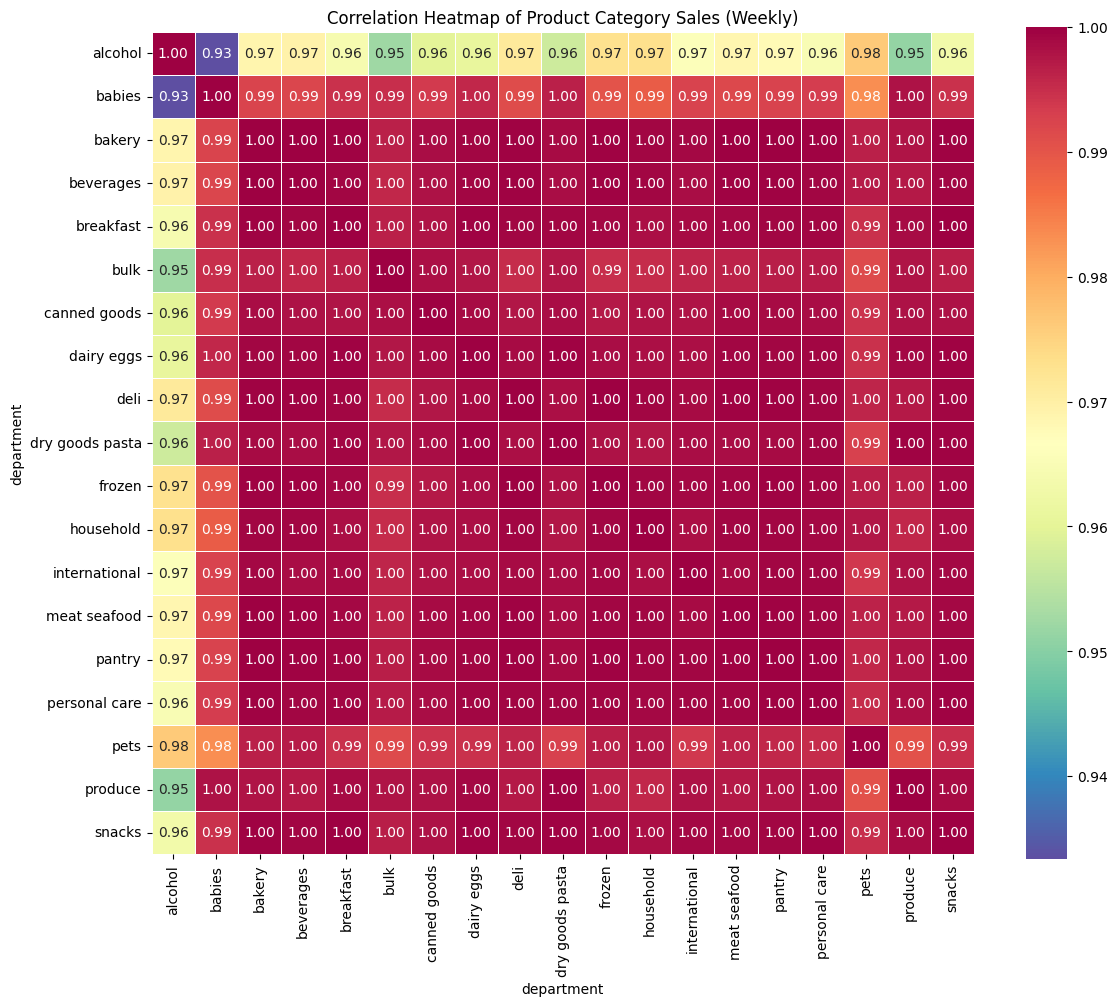

In [23]:
#Calculate correlation matrix
corr_matrix = weekly_sales_log.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))  
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Spectral_r', square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Product Category Sales (Weekly)")
plt.tight_layout()
plt.show()

Objective 1: Establish Long-Run Sales Relationships Among Product Categories
----------------------------------------------------------------------------
Stationarity and Cointegration Test

ADF Test (H₀: Series is non-stationary).  
KPSS Test (H₀: Series is stationary).  
Results are stored in adf_df and kpss_df for comparison.

Using statsmodels.tsa.stattools.coint()       
Null hypothesis (H₀): No cointegration.

Results are saved in coint_df with test statistic and p-value.

In [24]:
ts_df = weekly_sales_log.copy()   # or = weekly_sales

# Unit‑root tests on each series
adf_results   = []
kpss_results  = []

for col in ts_df.columns:
    series = ts_df[col].dropna()

    # Augmented Dickey‑Fuller (H0: non‑stationary)
    adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
    adf_results.append({'department': col,
                        'adf_stat': adf_stat,
                        'adf_pvalue': adf_p})

    # KPSS (H0: stationary)
    kpss_stat, kpss_p, *_ = kpss(series, regression='c')
    kpss_results.append({'department': col,
                         'kpss_stat': kpss_stat,
                         'kpss_pvalue': kpss_p})

adf_df  = pd.DataFrame(adf_results)
kpss_df = pd.DataFrame(kpss_results)

print(adf_df)
print(kpss_df)

# Engle‑Granger cointegration test on pairs
# (H0: not cointegrated)

# Compute total quantity sold for each department
dept_totals = ts_df.sum(axis=0) 

pairs   = combinations(ts_df.columns, 2)
coint_results = []

for x, y in tqdm(pairs, total=len(ts_df.columns)*(len(ts_df.columns)-1)//2):

    if dept_totals[x] >= dept_totals[y]:
        dept_x, dept_y = x, y
    else:
        dept_x, dept_y = y, x 

    score, pvalue, _ = coint(ts_df[dept_x].dropna(), ts_df[dept_y].dropna())
    coint_results.append({'dept_x': dept_x,
                          'dept_y': dept_y,
                          'coint_stat': score,
                          'pvalue': pvalue})

coint_df = pd.DataFrame(coint_results)


# Filter for significant pairs
sig_pairs = (coint_df
             .query('pvalue < 0.05')
             .sort_values('pvalue')
             .reset_index(drop=True))

print(f"Found {len(sig_pairs)} cointegrated pairs at 5% level")

         department  adf_stat  adf_pvalue
0           alcohol -0.927406    0.778813
1            babies  3.934078    1.000000
2            bakery -1.627069    0.469025
3         beverages -2.135361    0.230536
4         breakfast -1.252439    0.650641
5              bulk  0.086480    0.965126
6      canned goods  1.909734    0.998544
7        dairy eggs -2.067002    0.257988
8              deli -1.534939    0.516162
9   dry goods pasta -1.564626    0.501334
10           frozen -1.404248    0.580238
11        household -1.530739    0.518254
12    international -0.500675    0.891885
13     meat seafood -1.028283    0.742810
14           pantry -1.622100    0.471628
15    personal care -1.210214    0.669186
16             pets -1.161104    0.690100
17          produce -1.294071    0.631880
18           snacks -1.438169    0.563847
         department  kpss_stat  kpss_pvalue
0           alcohol   1.146608         0.01
1            babies   1.126936         0.01
2            bakery   1.0454

  0%|          | 0/171 [00:00<?, ?it/s]

Found 23 cointegrated pairs at 5% level


In [25]:
print("Below is the list of significant cointegrated pairs")
display(sig_pairs)

Below is the list of significant cointegrated pairs


,dept_x,dept_y,coint_stat,pvalue
0,dry goods pasta,personal care,-5.968686,0.000002
1,frozen,deli,-5.821453,0.000004
2,bakery,meat seafood,-5.212395,0.000066
3,pantry,meat seafood,-5.146852,0.000088
4,snacks,personal care,-5.060142,0.000127
5,deli,household,-5.024750,0.000148
6,breakfast,personal care,-4.941246,0.000211
7,snacks,breakfast,-4.678337,0.000614
8,personal care,international,-4.563608,0.000961
9,beverages,deli,-4.339504,0.002220


Objective 2: Estimate Bundle Ratio
--
Performing OLS linear regression of y_cat on x_cat using log-transformed weekly sales across all 23 pairs.

The beta coefficient (beta_bundle_ratio) indicates how much one category’s sales (log scale) move in relation to the other.

This ratio can be interpreted as the optimal quantity of one product category to be bundled with another.

In [26]:
bundle_ratios = []

print("----- Bundle Ratio Estimation via OLS (Full Summary Shown) -----")
print(f"Total cointegrated pairs to analyze: {len(sig_pairs)}")
print("-" * 70)

for idx, row in sig_pairs.iterrows():
    x_cat = row['dept_x']
    y_cat = row['dept_y']

    X = weekly_sales_log[x_cat]
    y = weekly_sales_log[y_cat]

    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()

    print(f"\n=== Pair {idx+1}: {y_cat} ~ {x_cat} ===")
    print(model.summary())

    bundle_ratios.append({
        'dependent': y_cat,
        'independent': x_cat,
        'beta_bundle_ratio': model.params[x_cat],
        'intercept': model.params['const'],
        'r_squared': model.rsquared
    })

bundle_ratios_df = pd.DataFrame(bundle_ratios)

print("\n--- Bundle Ratio Summary Table ---")
print(bundle_ratios_df)


----- Bundle Ratio Estimation via OLS (Full Summary Shown) -----
Total cointegrated pairs to analyze: 23
----------------------------------------------------------------------

=== Pair 1: personal care ~ dry goods pasta ===
                            OLS Regression Results                            
Dep. Variable:          personal care   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 3.624e+04
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           2.07e-74
Time:                        09:23:46   Log-Likelihood:                 98.033
No. Observations:                  53   AIC:                            -192.1
Df Residuals:                      51   BIC:                            -188.1
Df Model:                           1                                         
Covariance Type:            nonrobust                           

Objective 3: Error Correction Model and Detect Bundling Opportunities
----------------
Calculates lagged equilibrium deviation: how much y deviated from long-run path in previous period.     
Compute Δy and Δx, i.e., weekly changes in log-sales.

Regress change in y on:
ECT_lag (adjustment toward long-run equilibrium)
Δx (short-run shock)

Alpha (α): Strength and direction of error correction (how y corrects past imbalance).
Gamma (γ): Short-term impact of changes in x on changes in y.

ECM Interpretation Notes:
If α is negative and significant, the system adjusts back toward equilibrium.
Significant γ means short-term co-movement also exists, not just long-run.


In [27]:
ecm_results = []

print("----- Error Correction Model (ECM) Estimation -----")
print(f"Total cointegrated pairs to analyze: {len(sig_pairs)}")
print("-" * 70)

for idx, row in sig_pairs.iterrows():
    x_cat = row['dept_x']
    y_cat = row['dept_y']

    y = weekly_sales_log[y_cat]
    x = weekly_sales_log[x_cat]

    # 1. Getting beta from long-run OLS
    X_lr = sm.add_constant(x)
    lr_model = sm.OLS(y, X_lr).fit()
    beta = lr_model.params[x_cat]

    # 2. Computing lagged equilibrium error (ECT = y_t-1 - beta * x_t-1)
    ECT = y.shift(1) - beta * x.shift(1)

    # 3. Computing Δy and Δx
    dy = y.diff()
    dx = x.diff()

    # 4. ECM regression: Δy ~ ECT_lag + Δx
    df_ecm = pd.DataFrame({
        'dy': dy,
        'ECT_lag': ECT,
        'dx': dx
    }).dropna()

    X_ecm = sm.add_constant(df_ecm[['ECT_lag', 'dx']])
    model = sm.OLS(df_ecm['dy'], X_ecm).fit()

    print(f"\n=== Pair {idx+1}: Δ{y_cat} ~ ECT + Δ{x_cat} ===")
    print(model.summary())

    ecm_results.append({
        'dependent': y_cat,
        'independent': x_cat,
        'alpha': model.params['ECT_lag'],
        'alpha_pval': model.pvalues['ECT_lag'],
        'gamma': model.params['dx'],
        'gamma_pval': model.pvalues['dx'],
        'r_squared': model.rsquared
    })

# Creating summary DataFrame
ecm_df = pd.DataFrame(ecm_results)

print("\n--- ECM Summary Table ---")
display(ecm_df)


----- Error Correction Model (ECM) Estimation -----
Total cointegrated pairs to analyze: 23
----------------------------------------------------------------------

=== Pair 1: Δpersonal care ~ ECT + Δdry goods pasta ===
                            OLS Regression Results                            
Dep. Variable:                     dy   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     6934.
Date:                Wed, 06 Aug 2025   Prob (F-statistic):           7.81e-61
Time:                        09:23:47   Log-Likelihood:                 108.06
No. Observations:                  52   AIC:                            -210.1
Df Residuals:                      49   BIC:                            -204.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                

,dependent,independent,alpha,alpha_pval,gamma,gamma_pval,r_squared
0,personal care,dry goods pasta,-0.689366,0.000015,0.916676,1.283443e-60,0.996479
1,deli,frozen,-0.660038,0.000187,0.963572,2.261907e-73,0.999110
2,meat seafood,bakery,-0.588376,0.000010,1.070646,1.515989e-73,0.998856
3,meat seafood,pantry,-0.516850,0.000020,1.029419,6.088486e-69,0.998266
4,personal care,snacks,-0.642292,0.000010,1.035154,6.761094e-65,0.997385
5,household,deli,-0.532879,0.001612,1.011697,2.130911e-53,0.994036
6,personal care,breakfast,-0.569282,0.000098,0.993208,2.088938e-60,0.996299
7,breakfast,snacks,-0.575622,0.000213,1.040775,1.592519e-72,0.998960
8,international,personal care,-0.571350,0.000023,0.951002,1.829502e-59,0.995644
9,deli,beverages,-0.552053,0.000067,0.999218,1.027896e-68,0.998372


### Bundling Signal Detection
---------------------------------------
Regress dependent category on the independent to get predicted relationship (spread).\
Residuals (spread) show deviation from the long-run trend.\
Z-scores help identify unusually negative deviations.\
Weeks where the dependent category underperforms the expected relationship (z < -1.5) are potential bundling signals.\
Save all significant weeks along with their z-scores.\
Print bundling recommendations per pair.

Interpretation:\
Z < -1.5 indicates the dependent product is underperforming relative to its usual link with the independent product.\
This may be a good week to bundle them — i.e., promote the lagging one alongside the stronger performer.




In [28]:
# Creating dictionary to hold bundling suggestions
bundling_signals = {}

print("----- Bundling Signal Detection -----\n")

for idx, row in sig_pairs.iterrows():
    indep = row['dept_x']
    dep = row['dept_y']
    
    # Regressing dep ~ indep to get long-run relationship
    X = sm.add_constant(weekly_sales_log[indep])
    y = weekly_sales_log[dep]
    model = sm.OLS(y, X).fit()
    
    # Residuals = actual - predicted (spread)
    spread = model.resid
    z_scores = zscore(spread)
    
    # Identifing bundling signals where z < -2
    signal_weeks = weekly_sales_log.index[z_scores < -1.5].tolist()
    signal_zs = z_scores[z_scores < -1.5]
    
    if len(signal_weeks) > 0:
        bundling_signals[f"{dep} ~ {indep}"] = list(zip(signal_weeks, signal_zs))

        print(f"Pair {dep} ~ {indep}:")
        for week, z in zip(signal_weeks, signal_zs):
            print(f"  ⚠️ Week {week}: z = {z:.2f} → Suggest bundling '{dep}' with '{indep}'")
        print()
    else:
        print(f"Pair {dep} ~ {indep}: No bundling suggestions (z-score never < -1.5)\n")

all_signals_df = pd.DataFrame([
    {"pair": pair, "week": week, "z_score": z}
    for pair, signals in bundling_signals.items()
    for week, z in signals
])


----- Bundling Signal Detection -----

Pair personal care ~ dry goods pasta:
  ⚠️ Week 35: z = -1.79 → Suggest bundling 'personal care' with 'dry goods pasta'
  ⚠️ Week 51: z = -1.63 → Suggest bundling 'personal care' with 'dry goods pasta'
  ⚠️ Week 52: z = -2.66 → Suggest bundling 'personal care' with 'dry goods pasta'

Pair deli ~ frozen:
  ⚠️ Week 46: z = -1.66 → Suggest bundling 'deli' with 'frozen'
  ⚠️ Week 53: z = -2.79 → Suggest bundling 'deli' with 'frozen'

Pair meat seafood ~ bakery:
  ⚠️ Week 1: z = -2.85 → Suggest bundling 'meat seafood' with 'bakery'
  ⚠️ Week 47: z = -1.91 → Suggest bundling 'meat seafood' with 'bakery'
  ⚠️ Week 48: z = -2.55 → Suggest bundling 'meat seafood' with 'bakery'
  ⚠️ Week 51: z = -2.34 → Suggest bundling 'meat seafood' with 'bakery'

Pair meat seafood ~ pantry:
  ⚠️ Week 1: z = -3.37 → Suggest bundling 'meat seafood' with 'pantry'
  ⚠️ Week 5: z = -1.51 → Suggest bundling 'meat seafood' with 'pantry'
  ⚠️ Week 51: z = -1.62 → Suggest bundlin

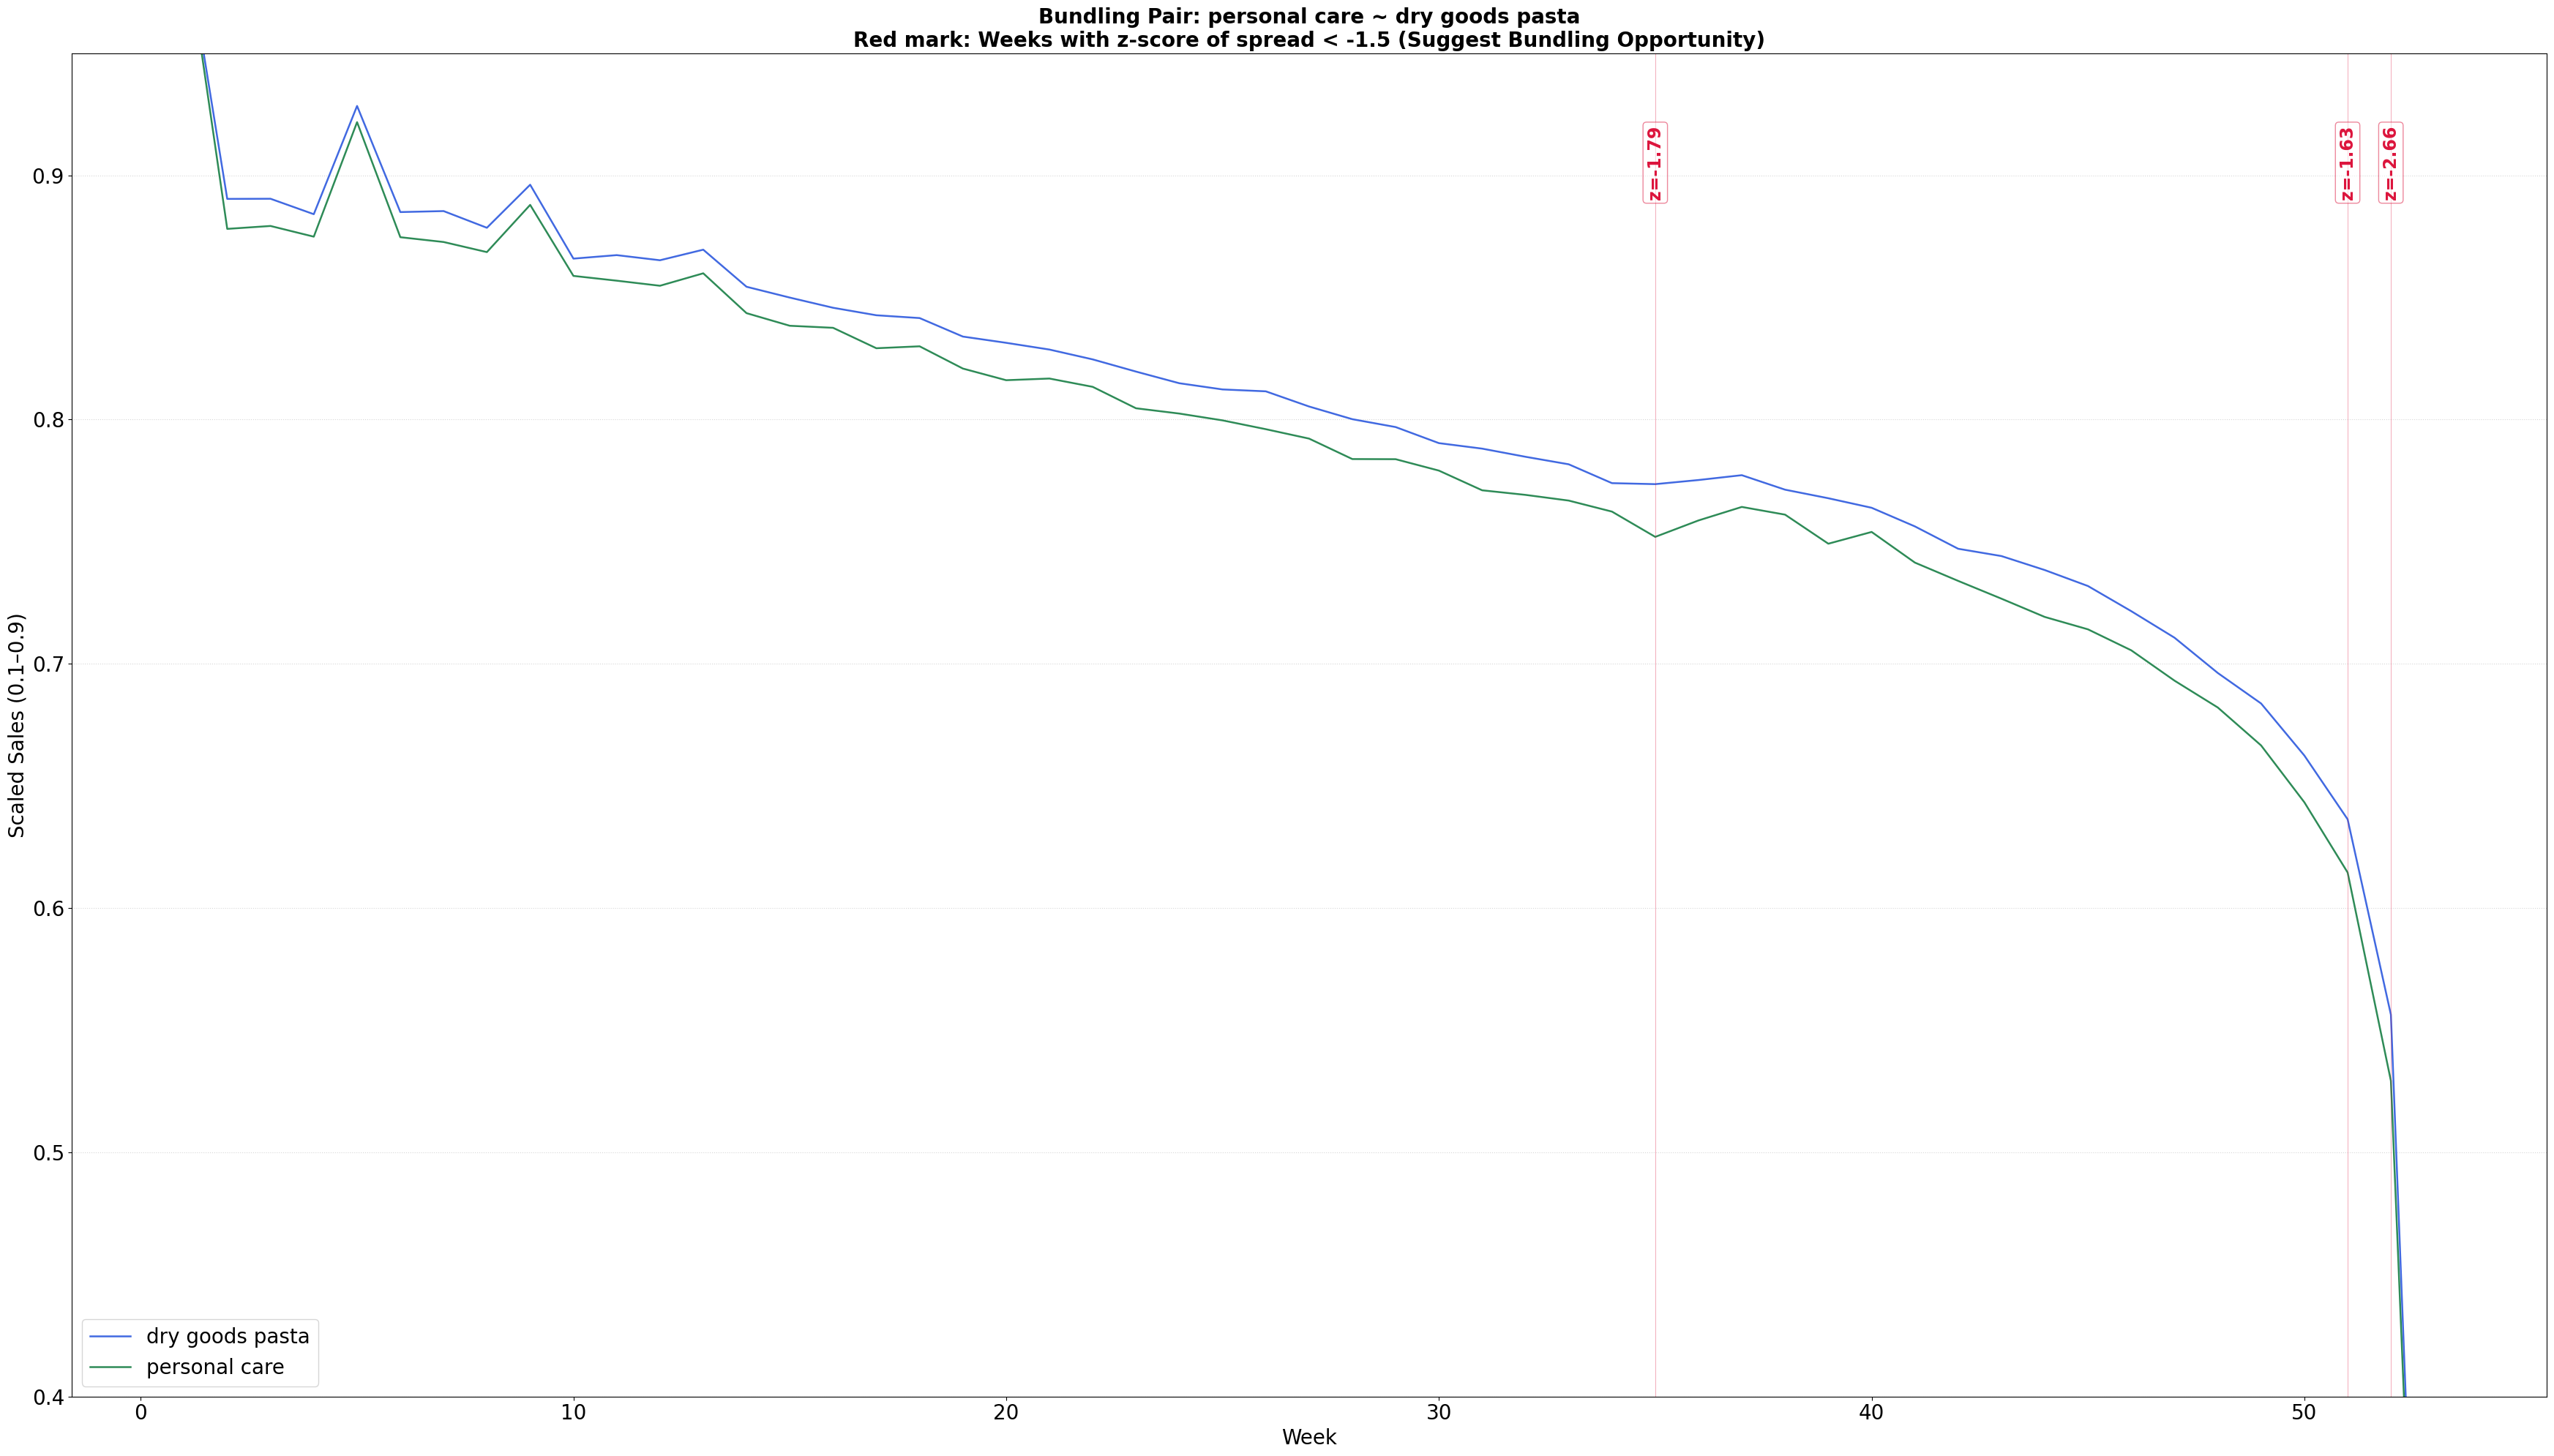

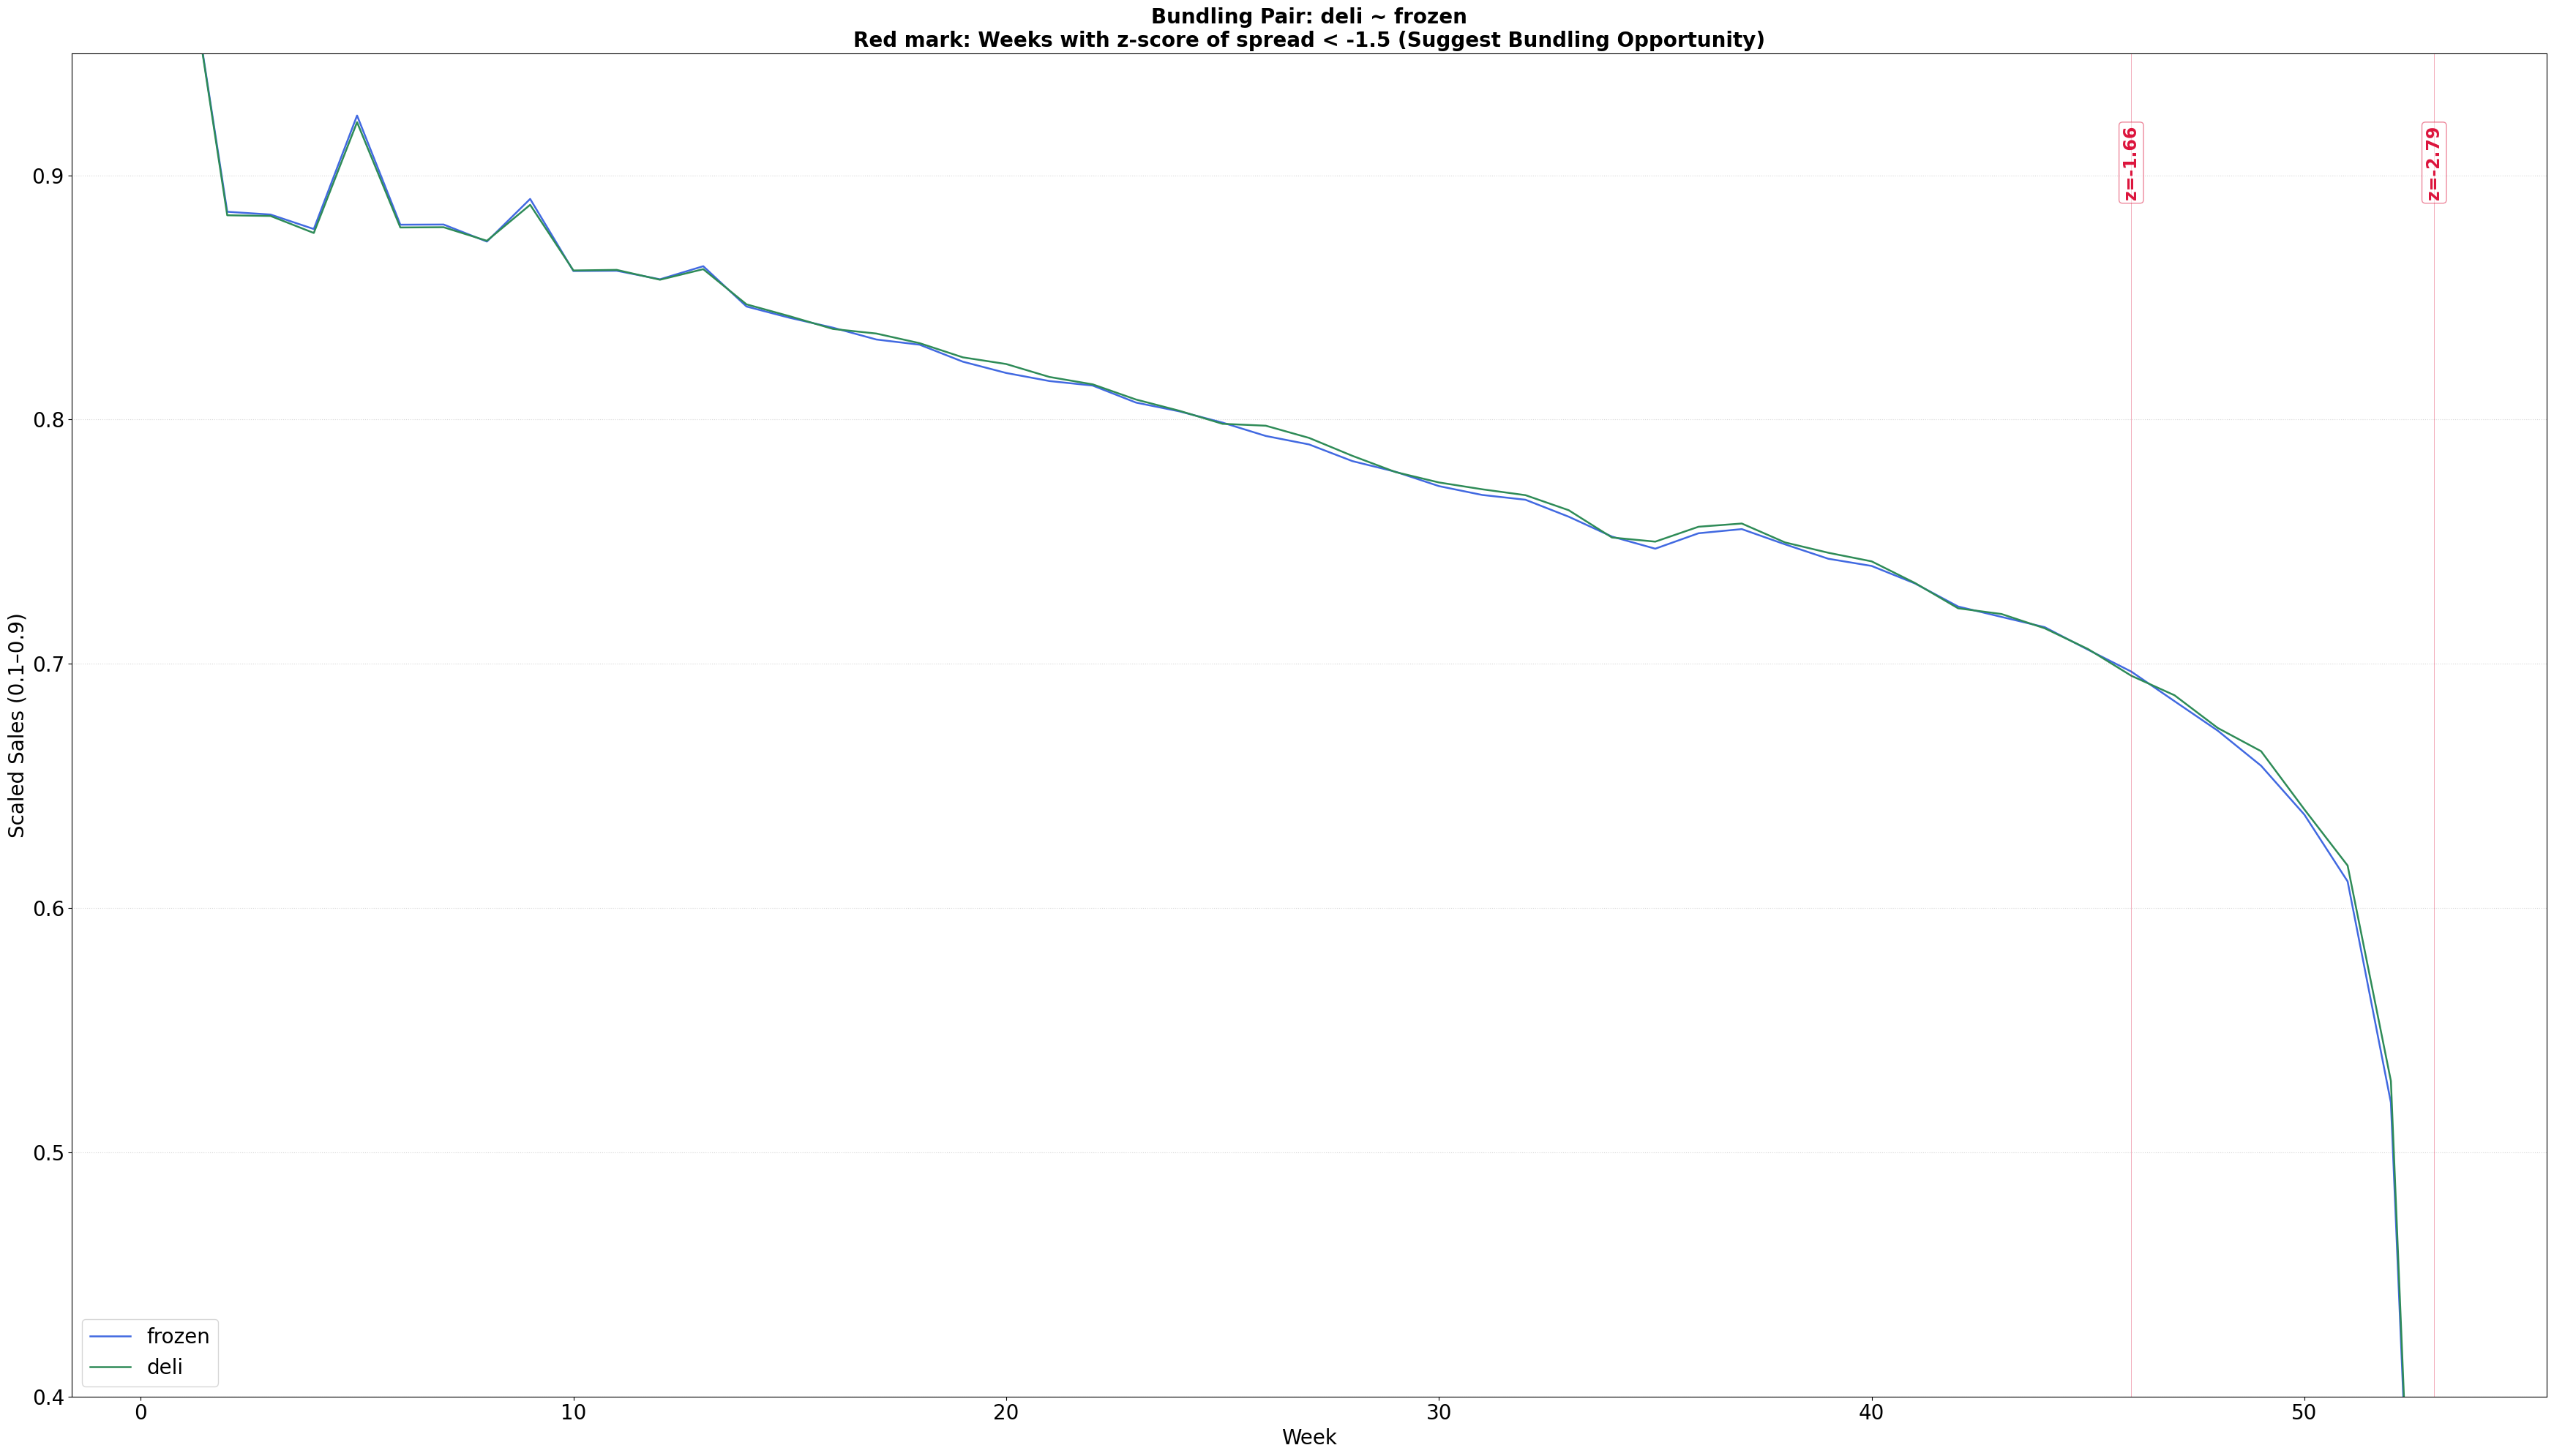

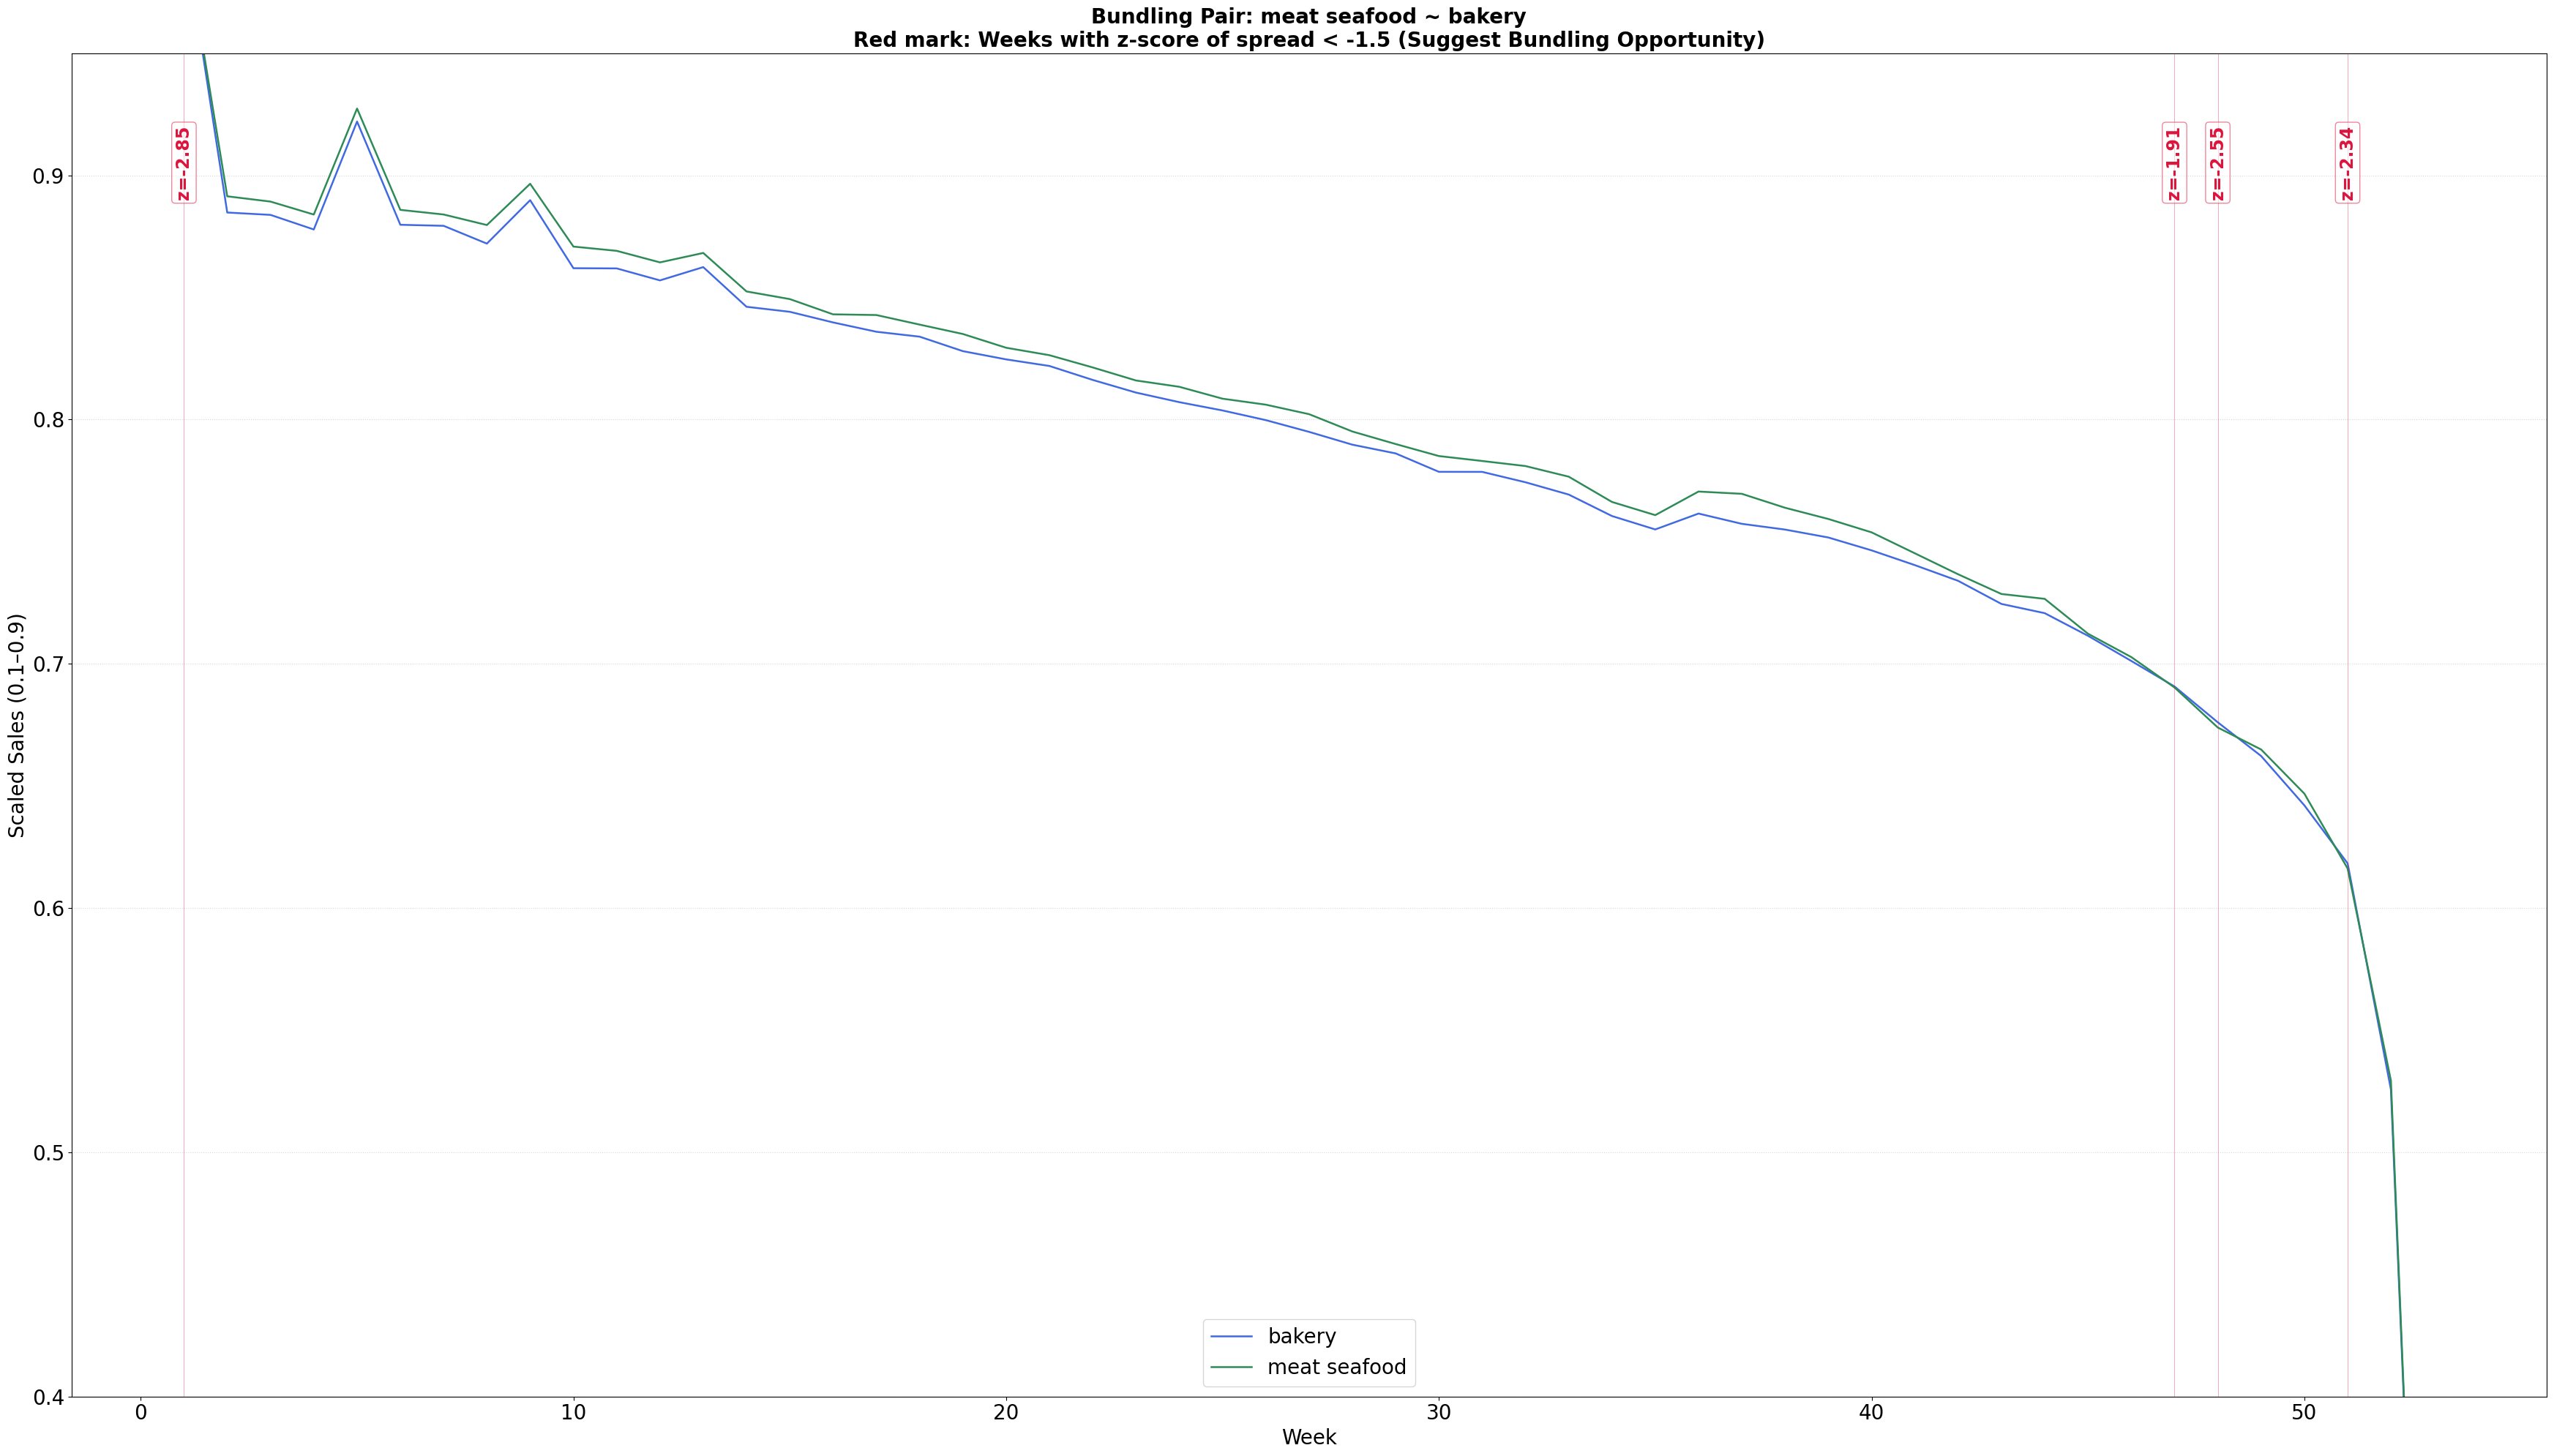

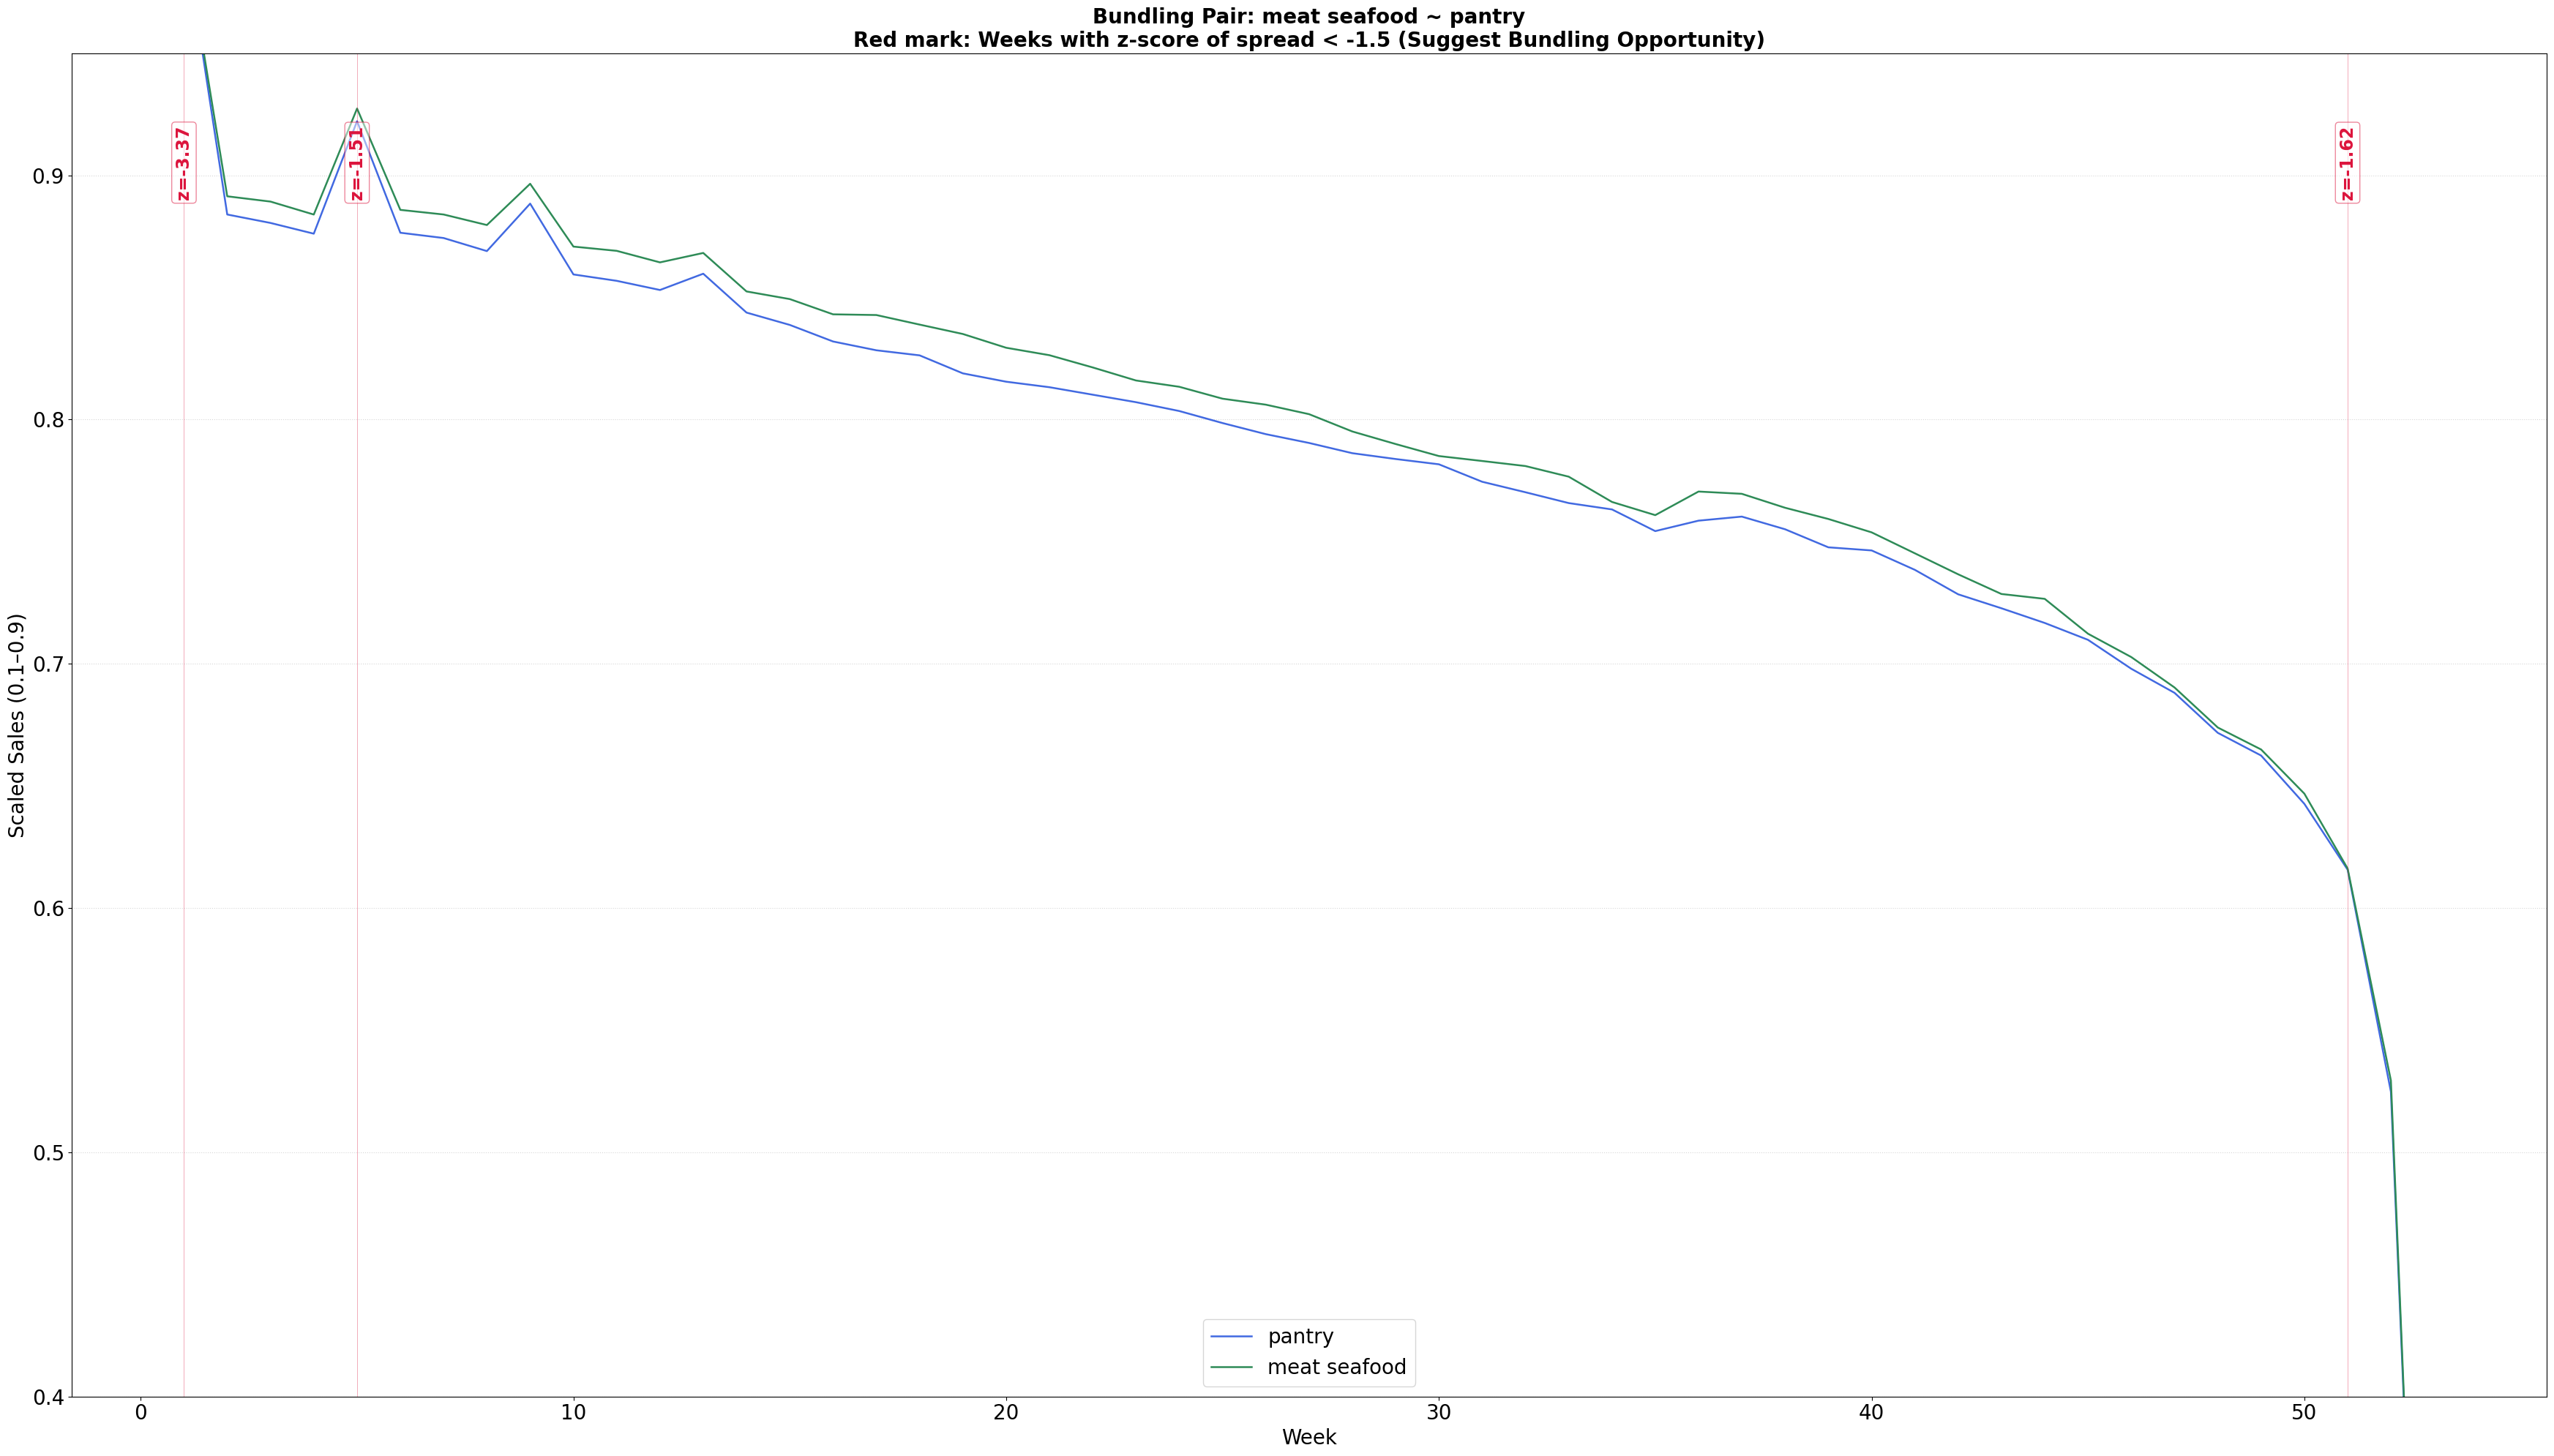

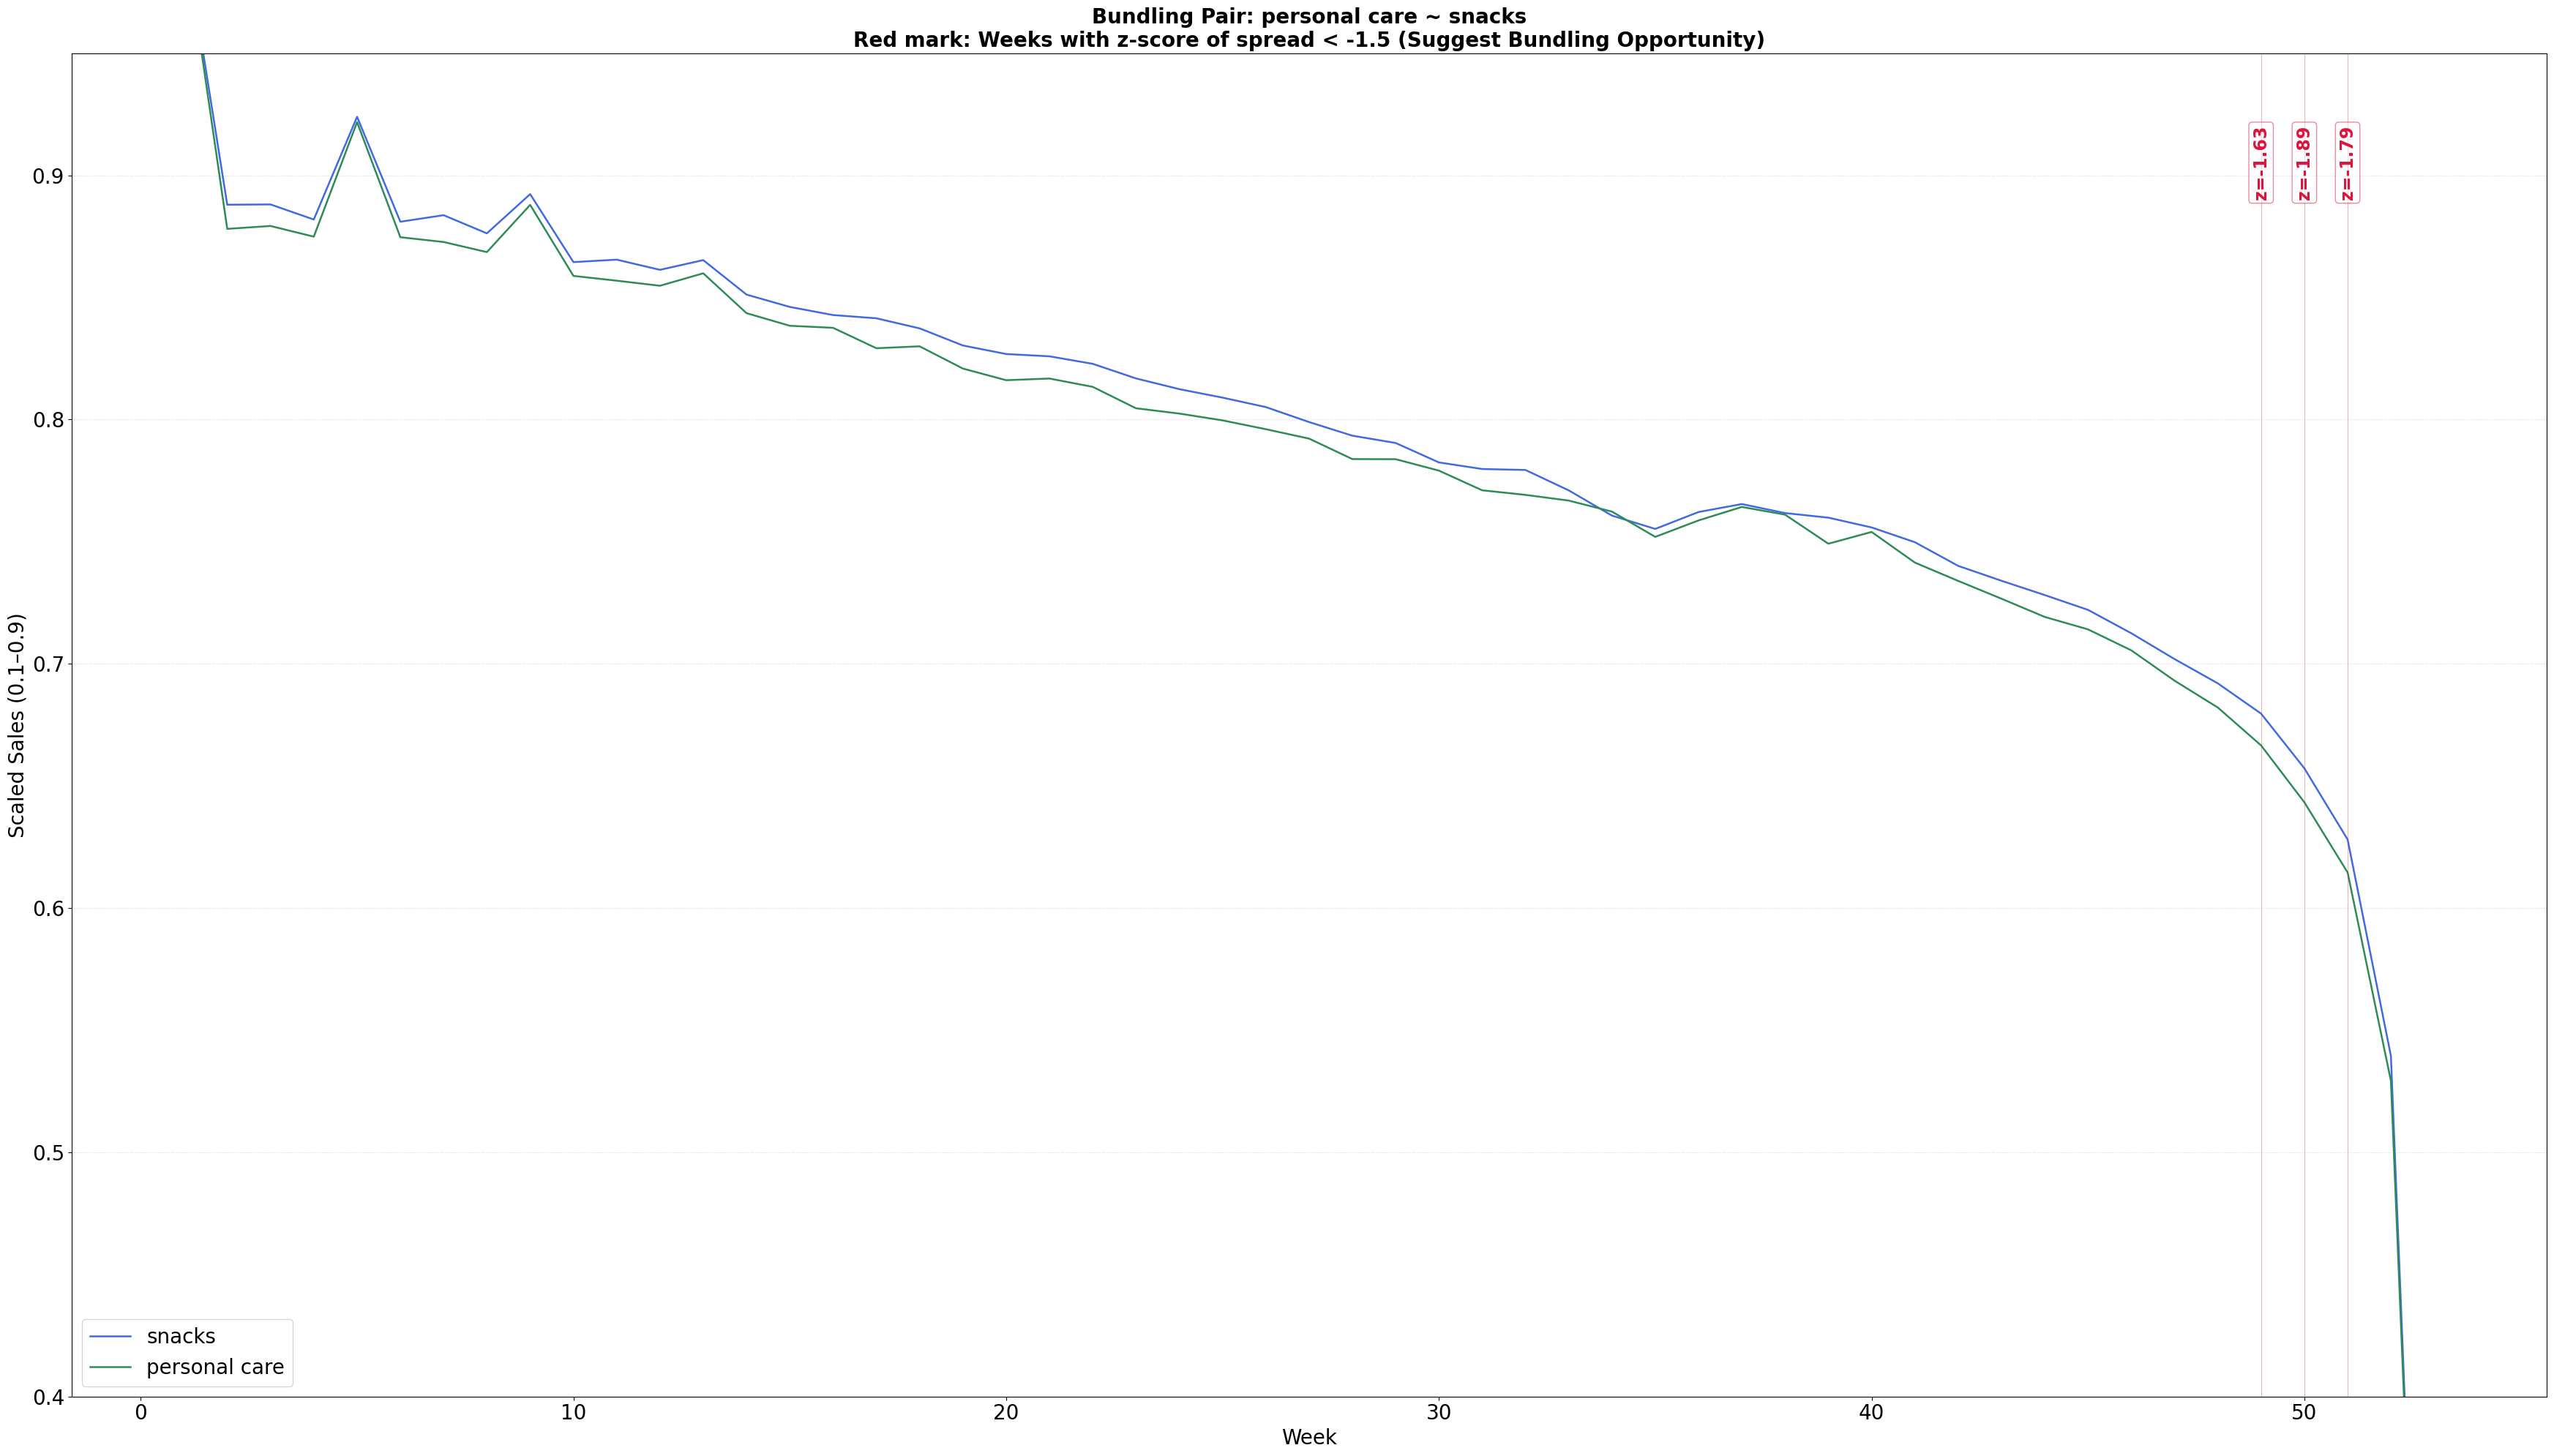

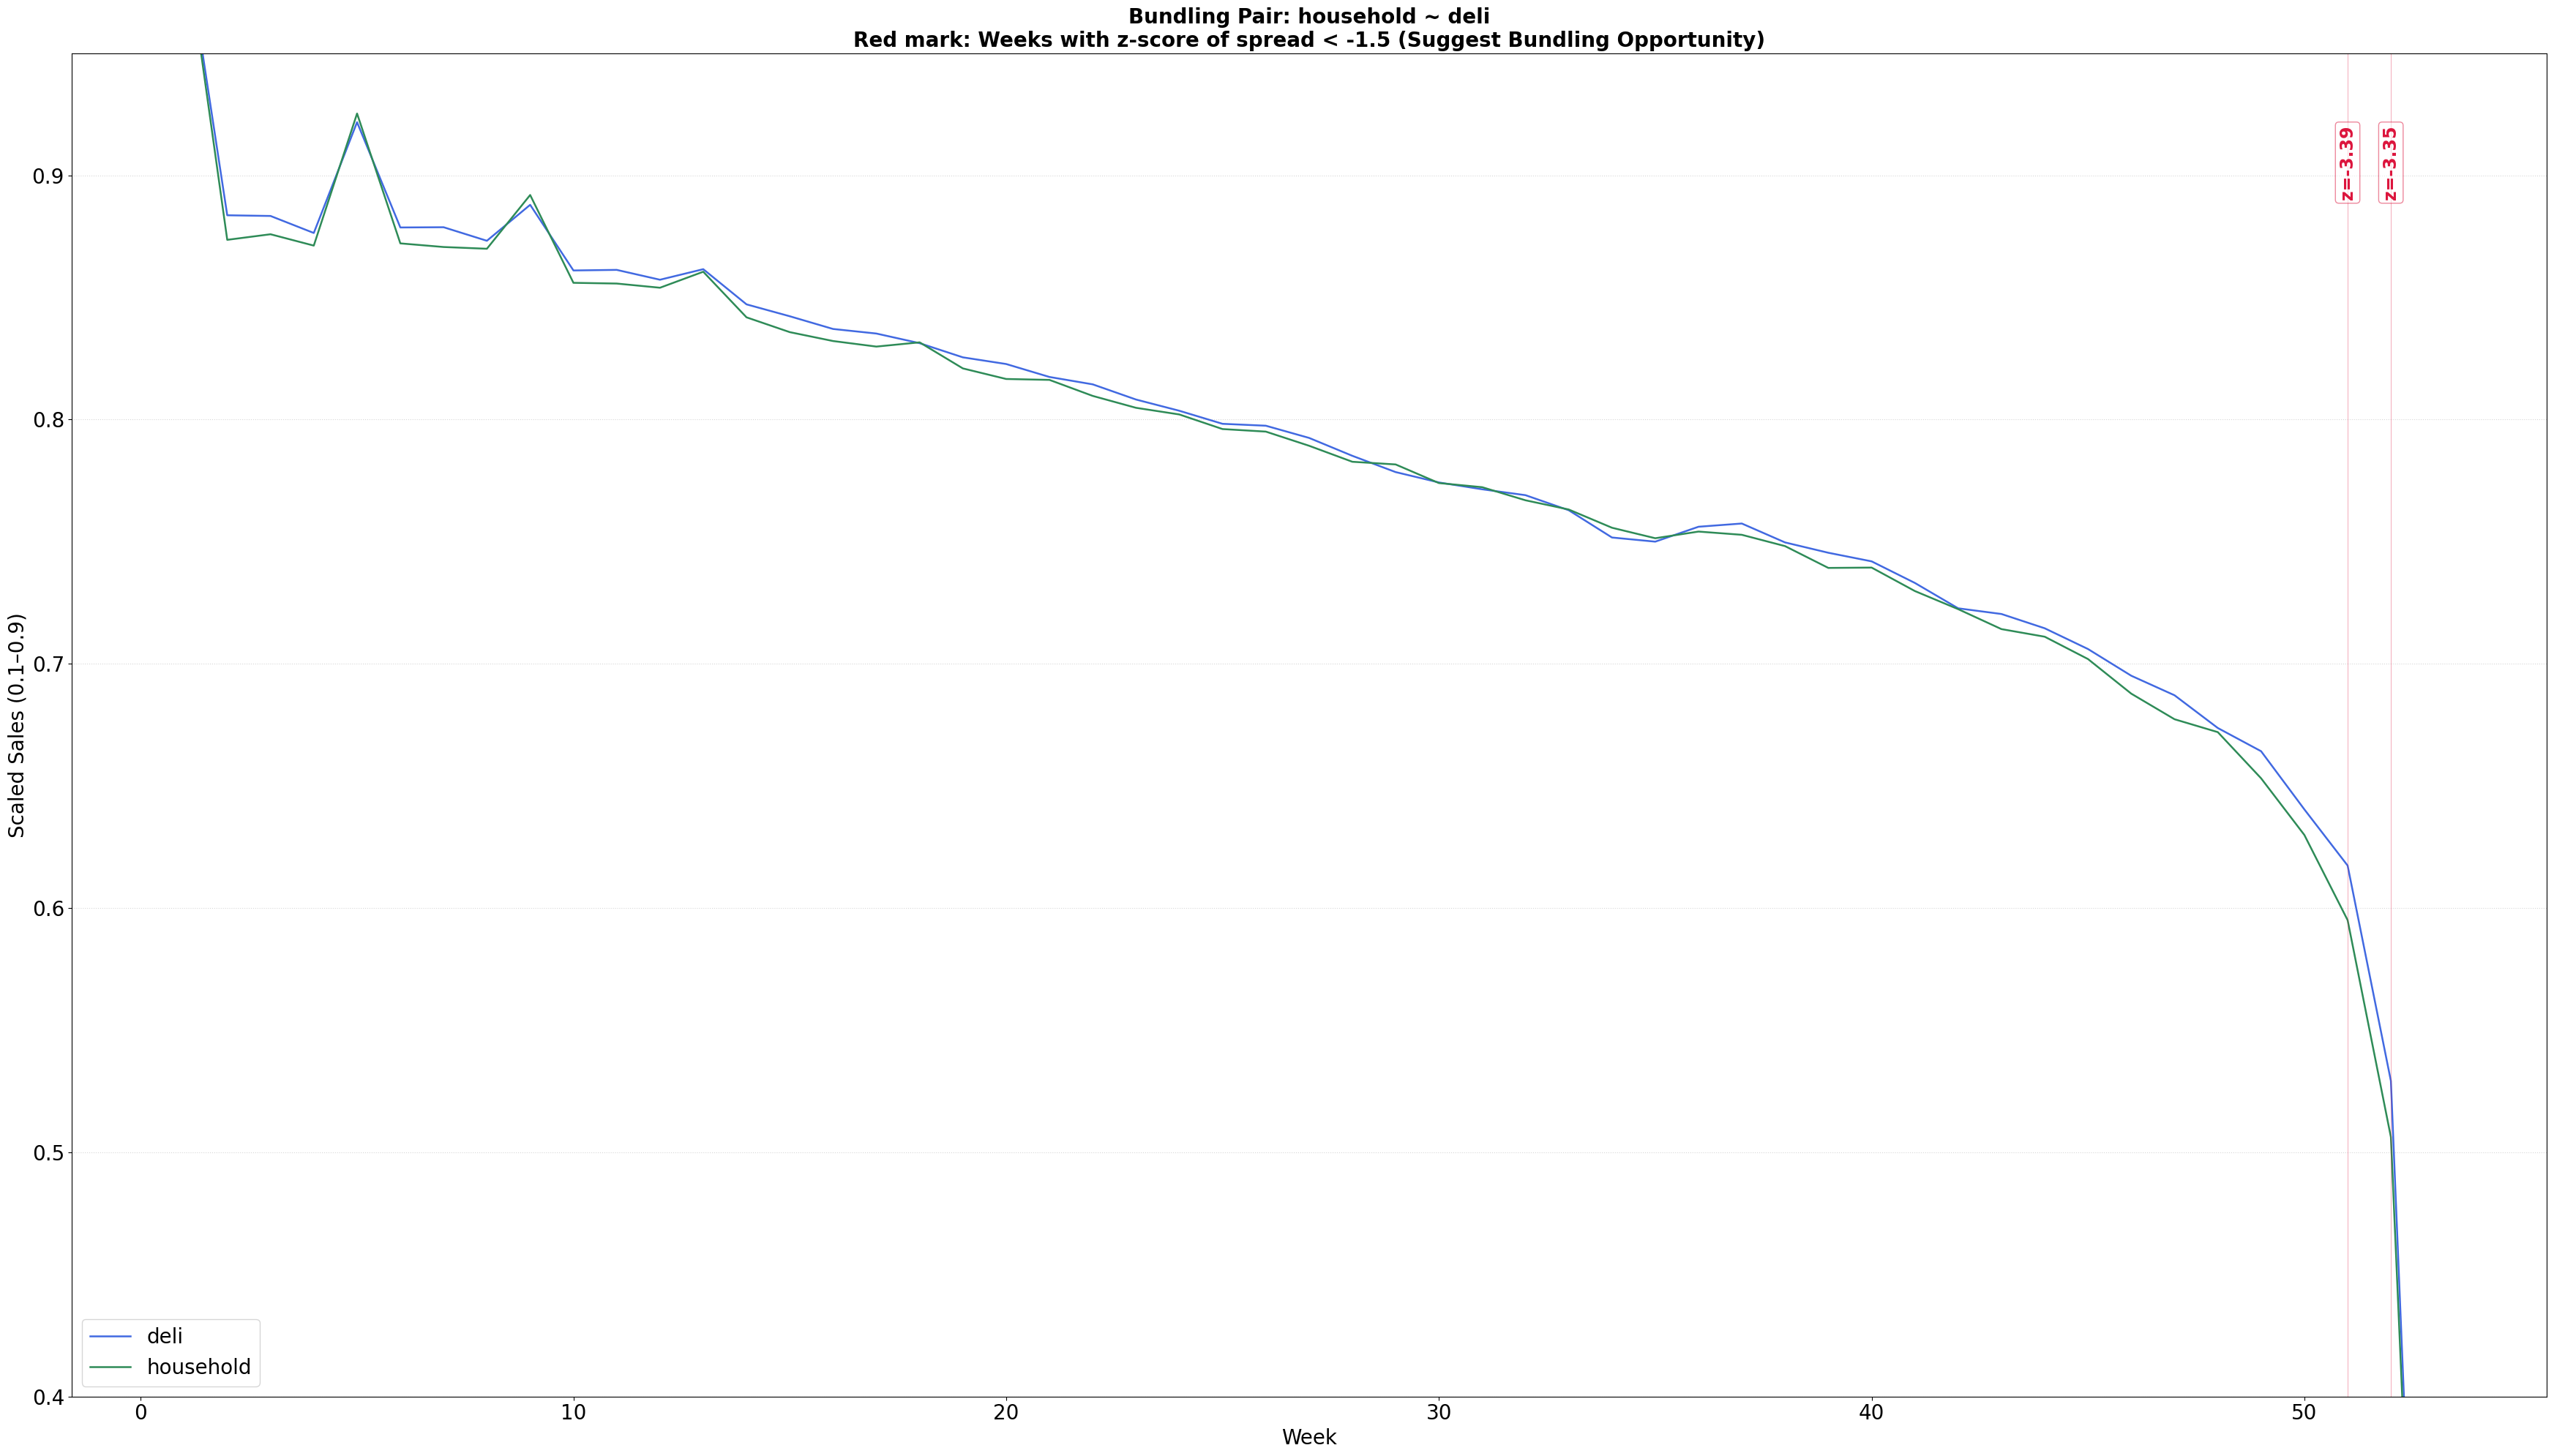

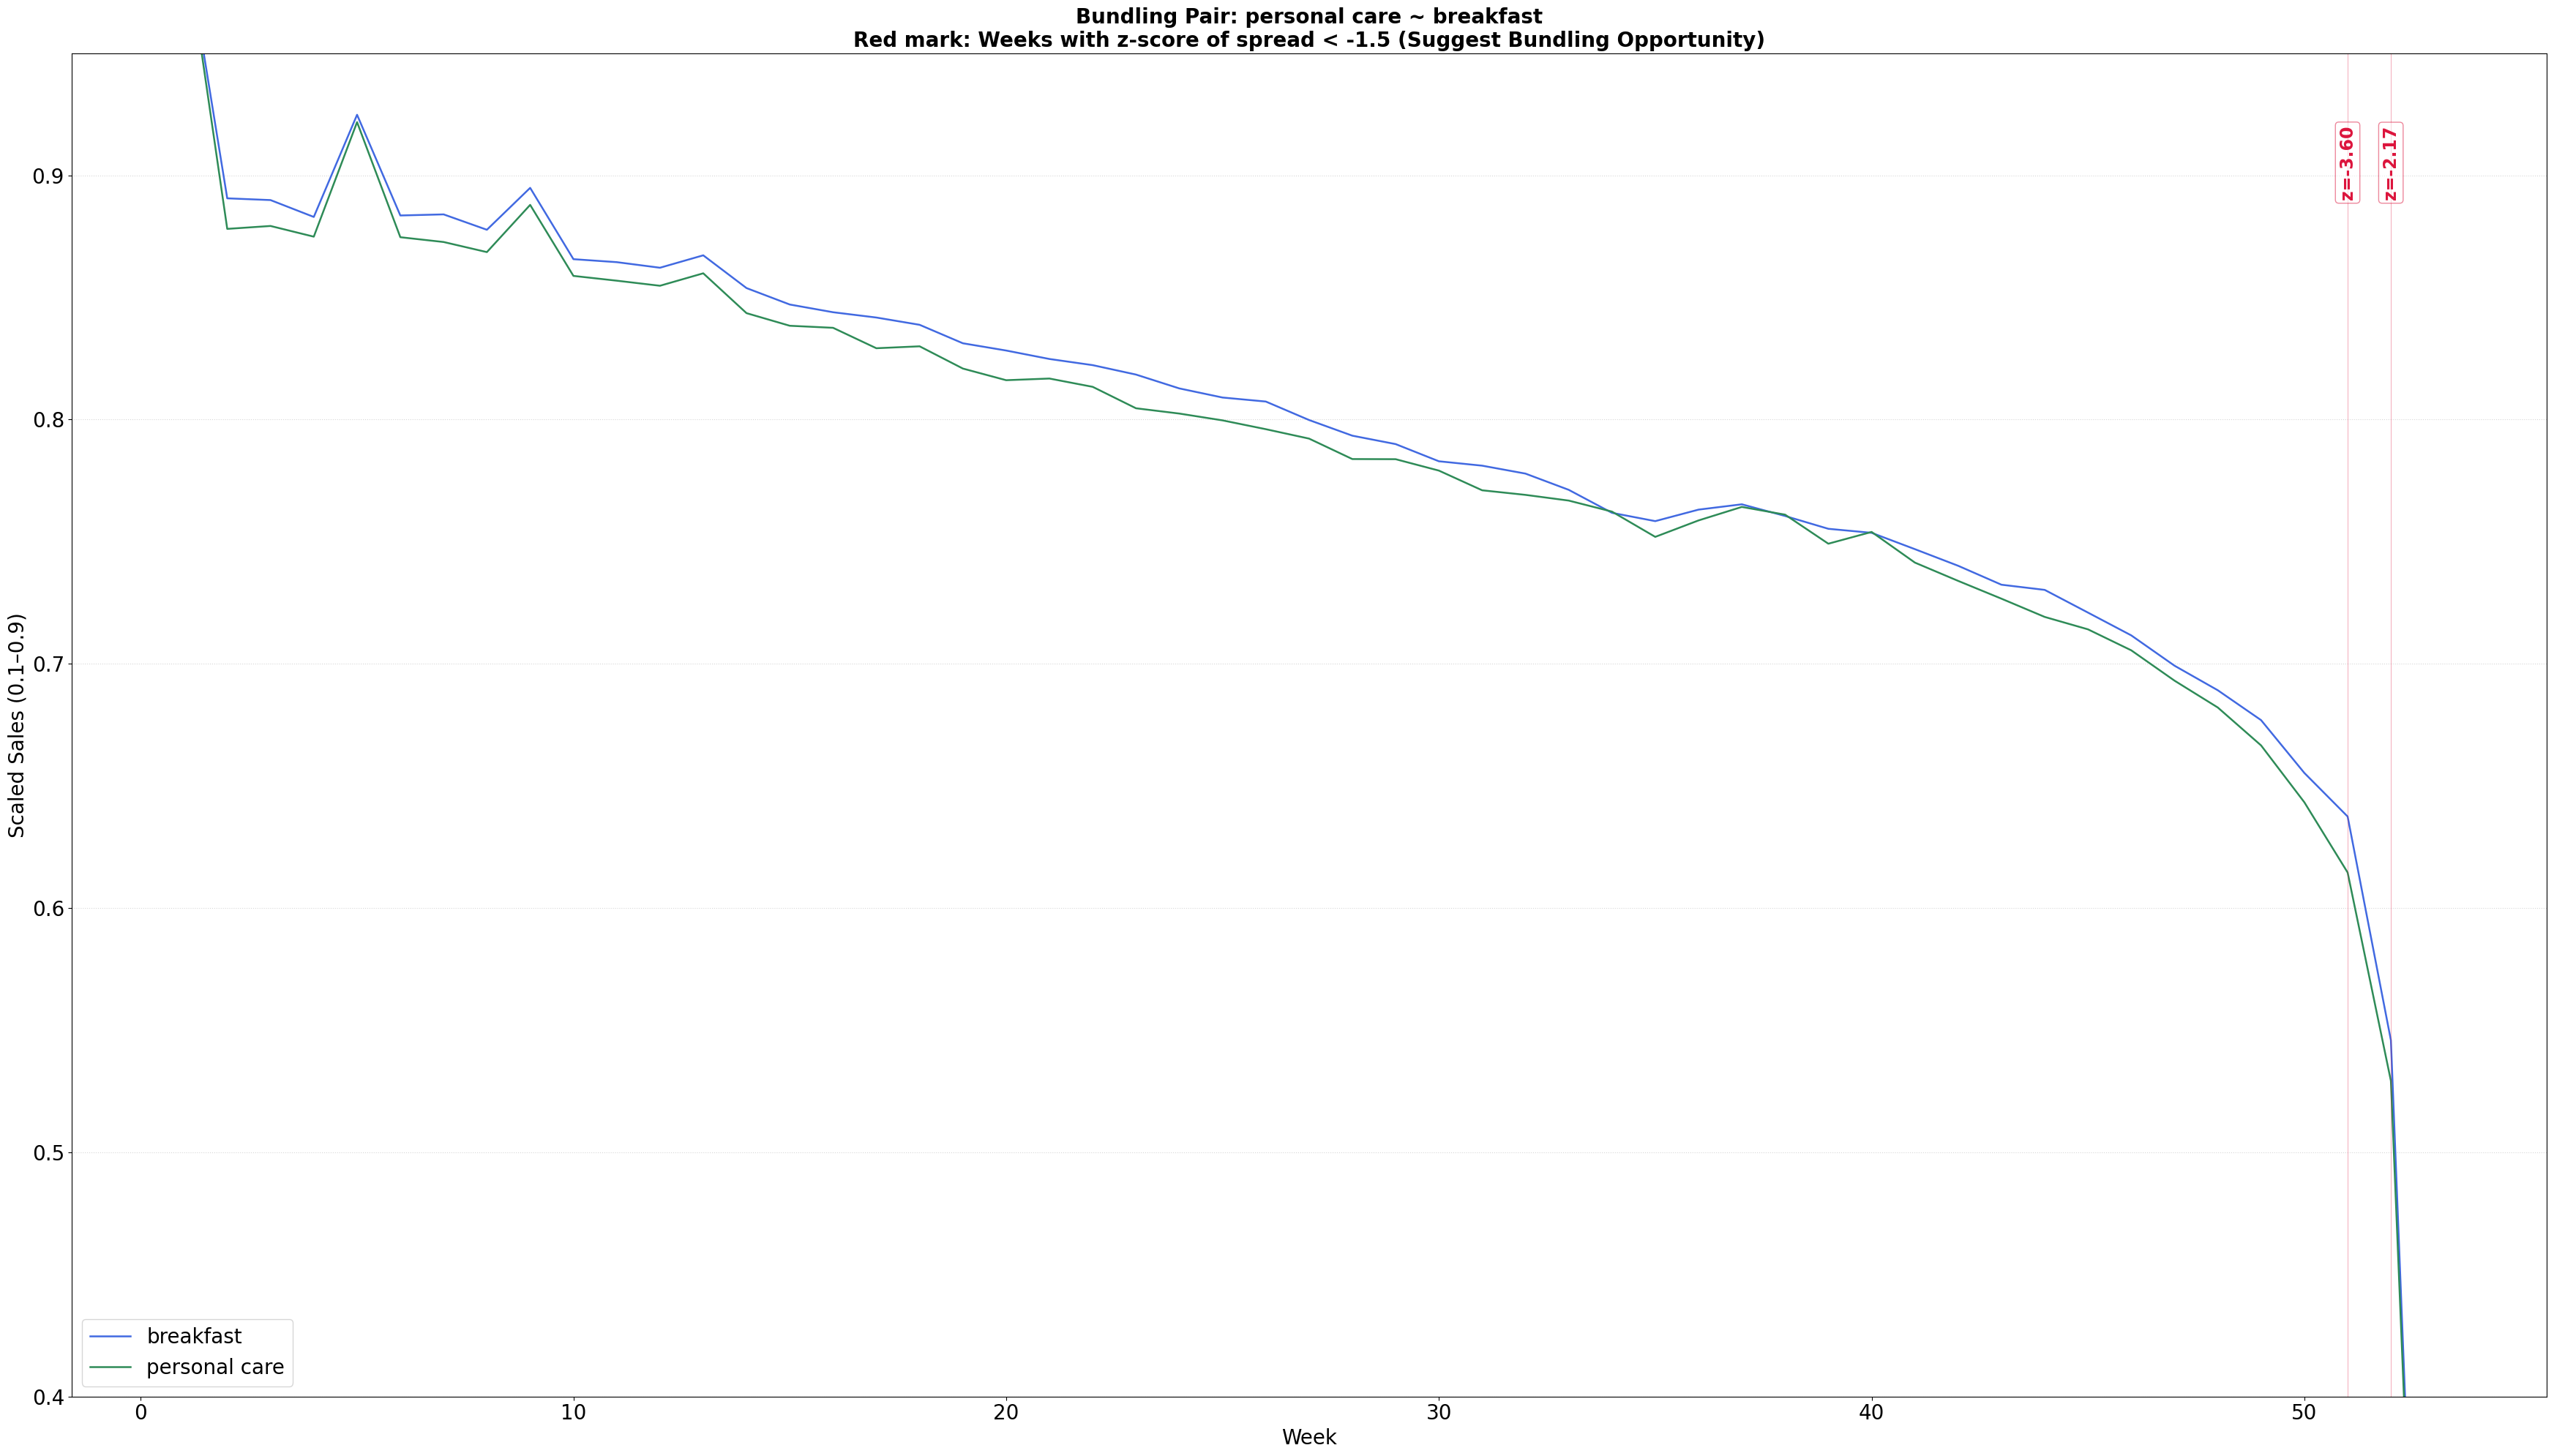

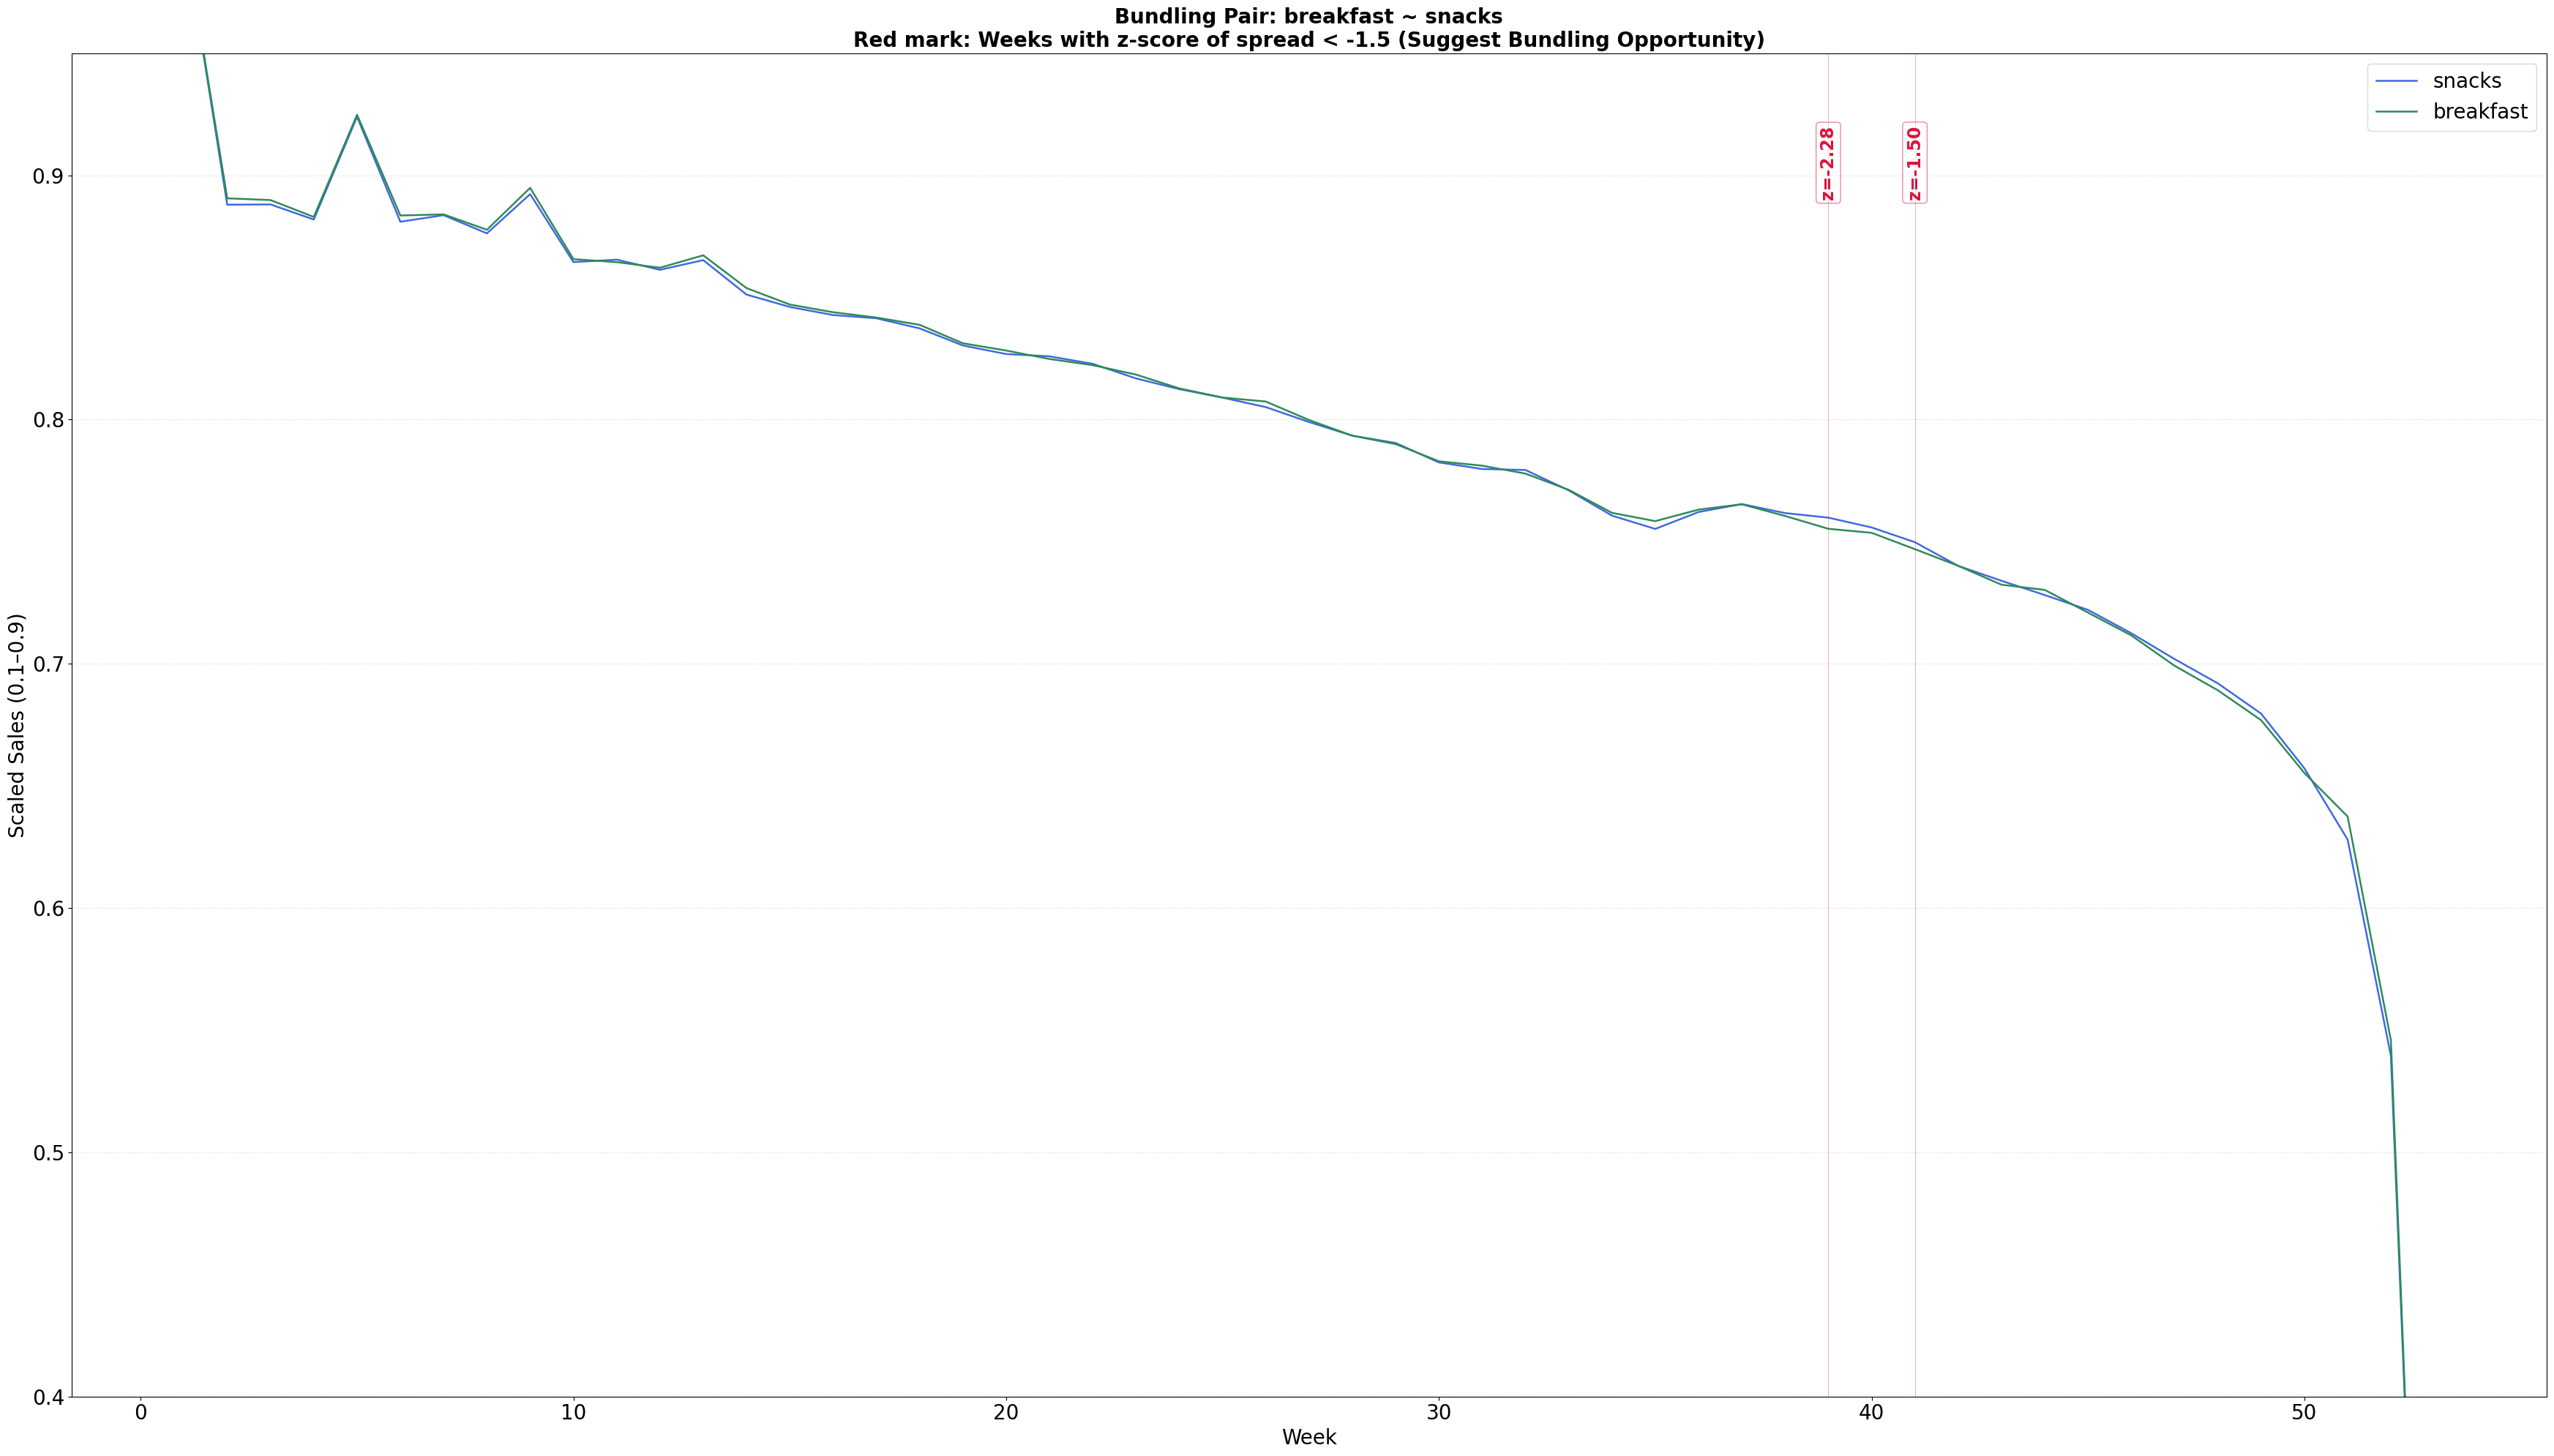

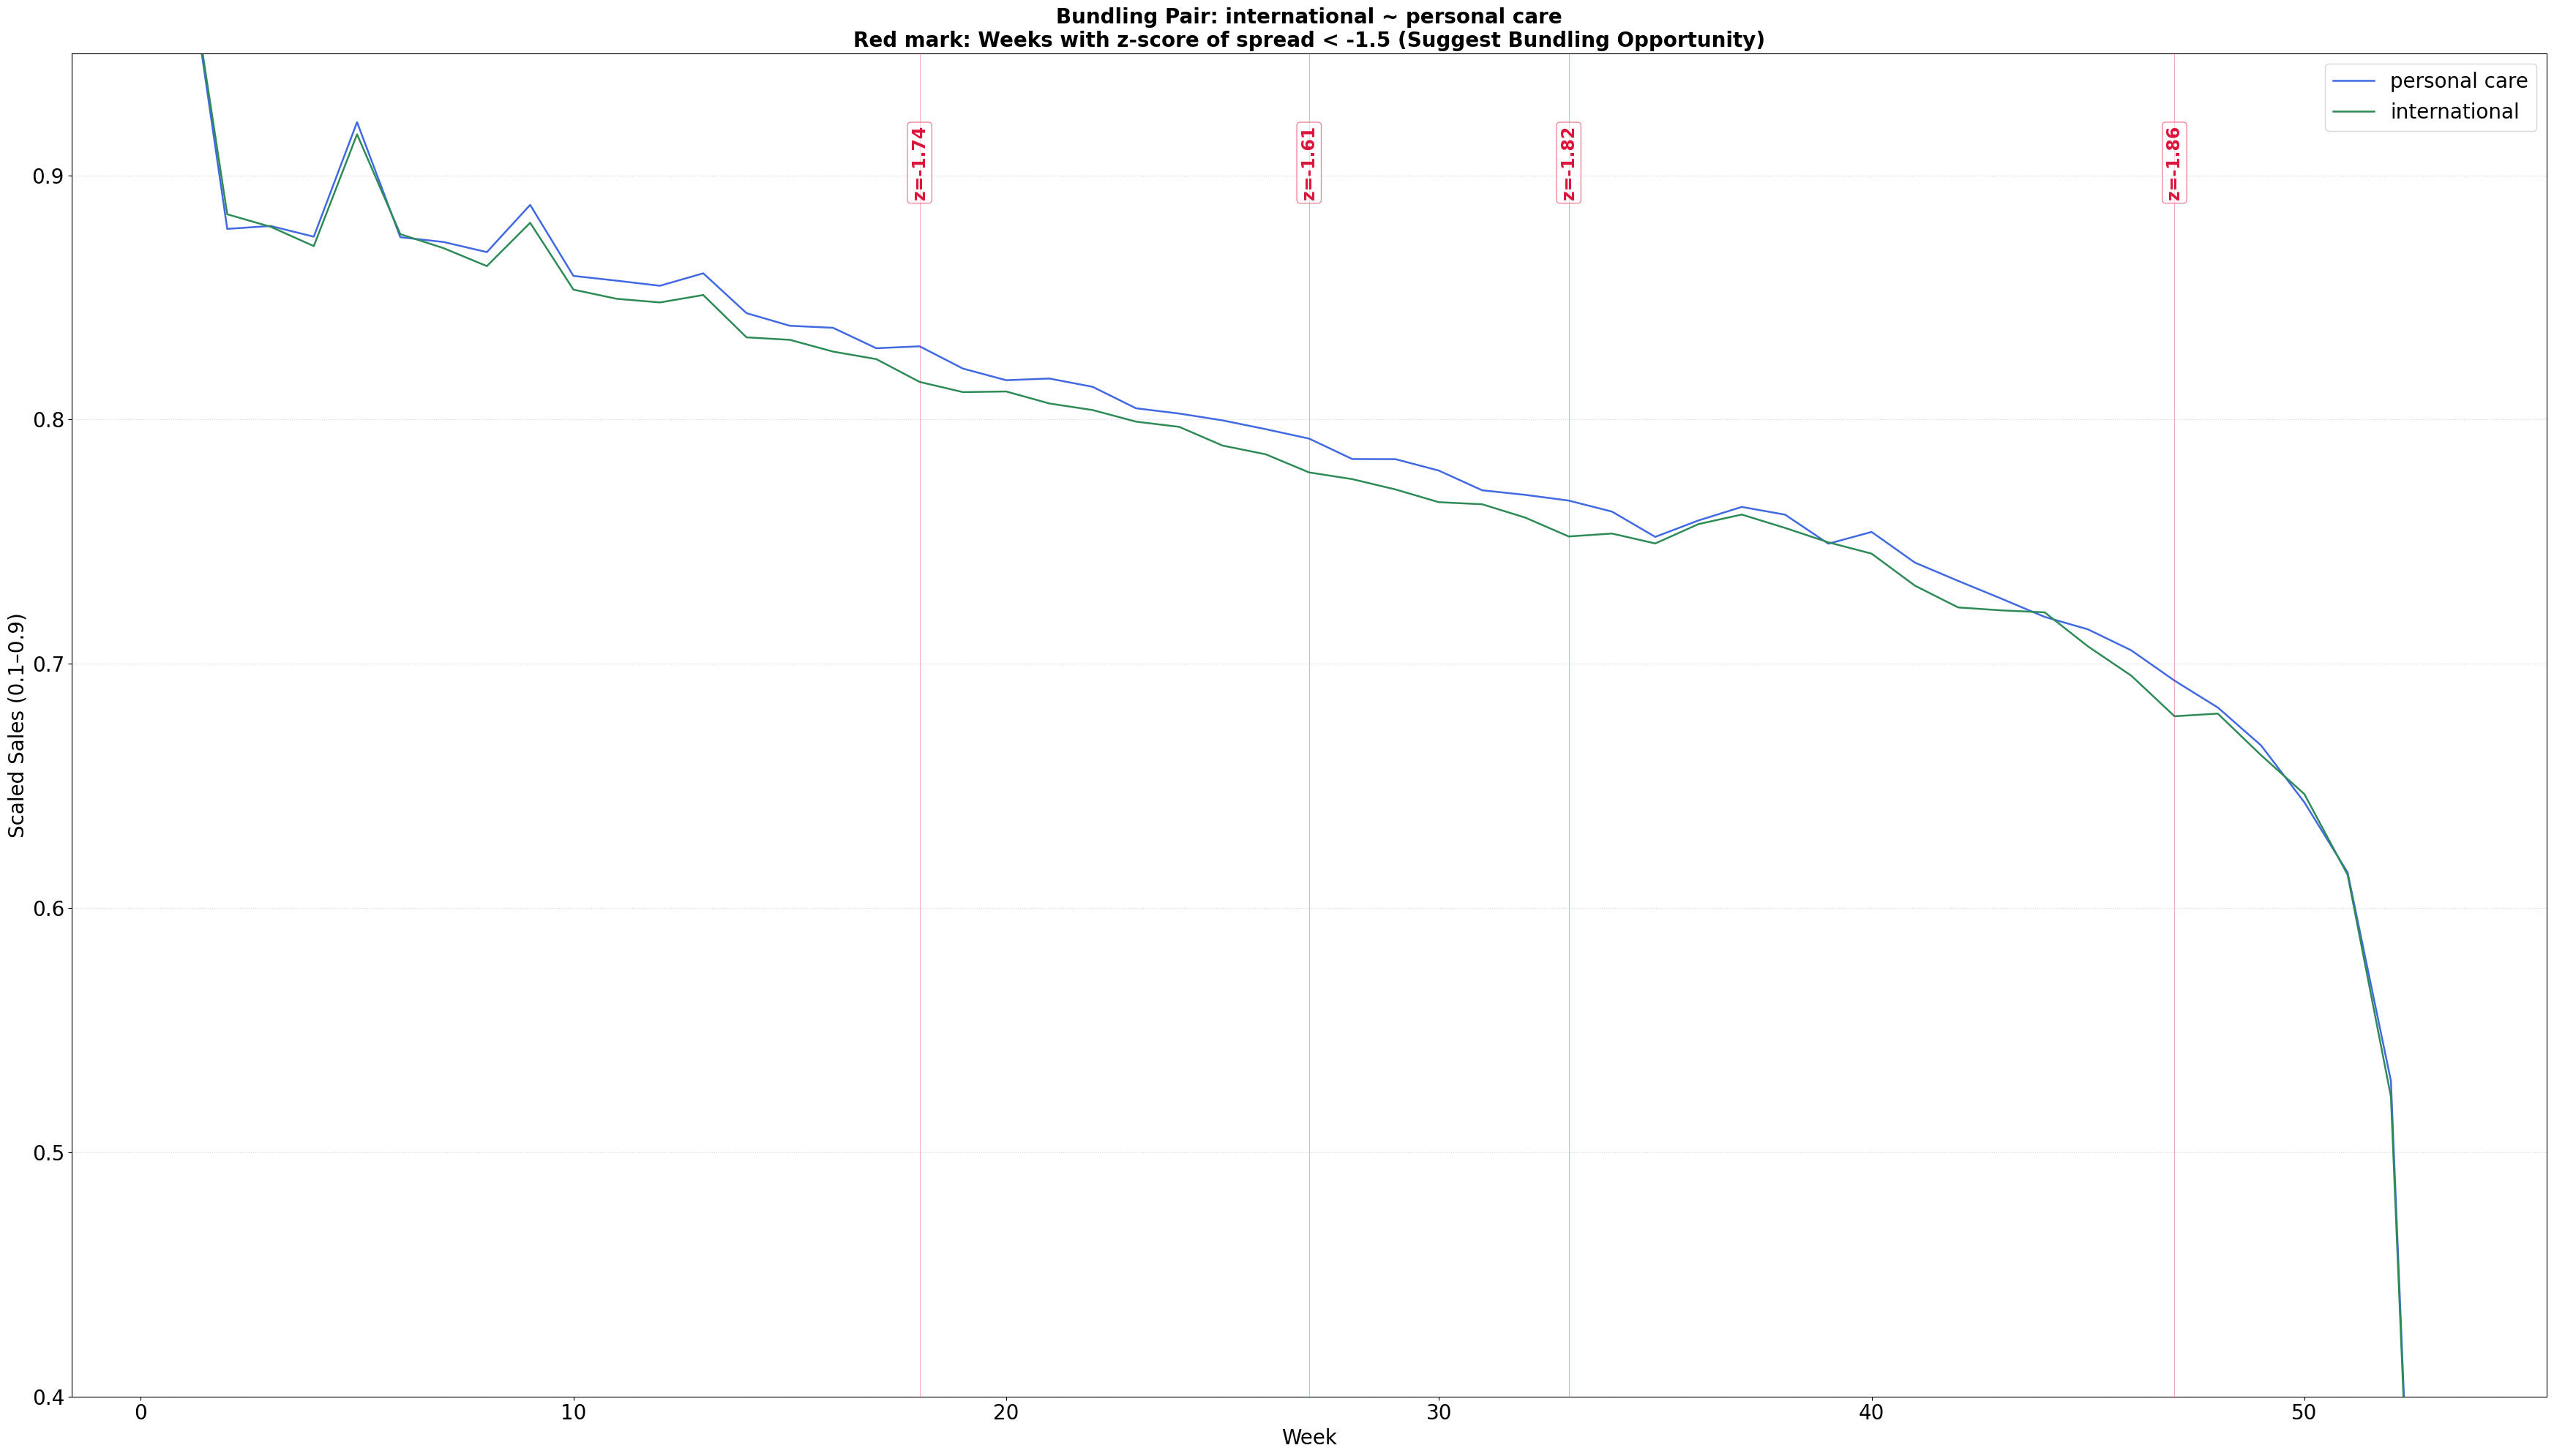

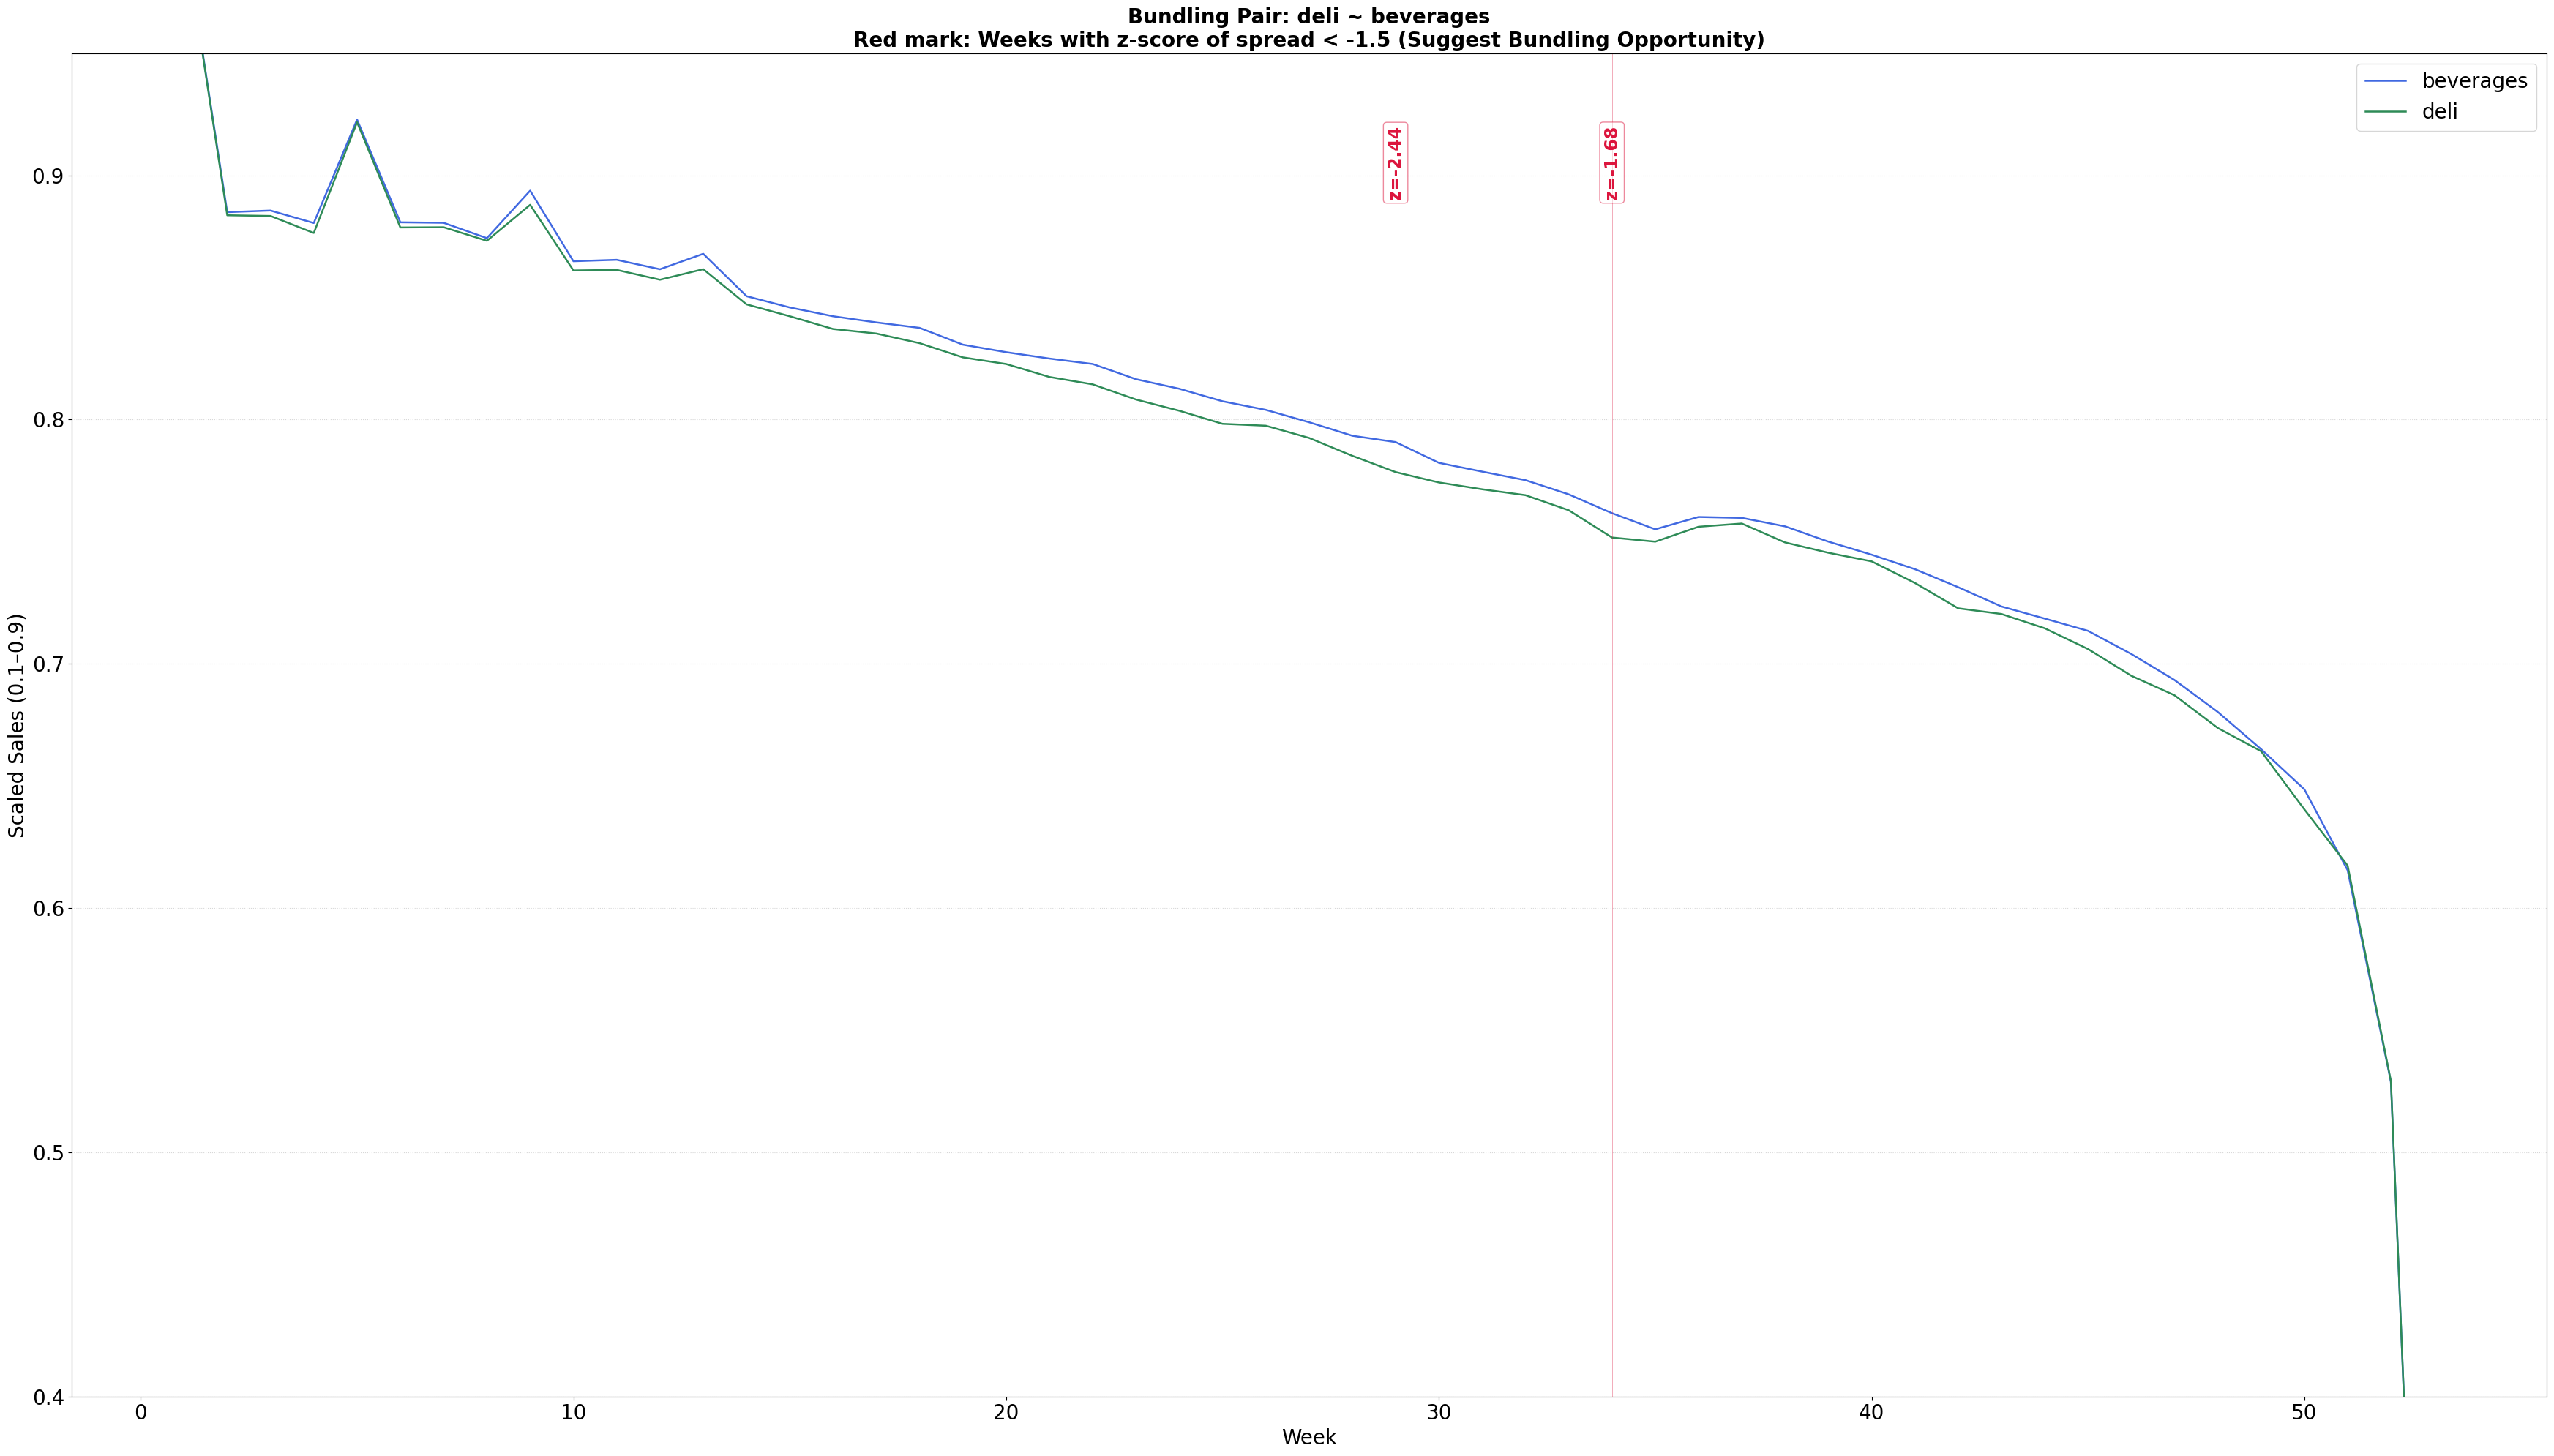

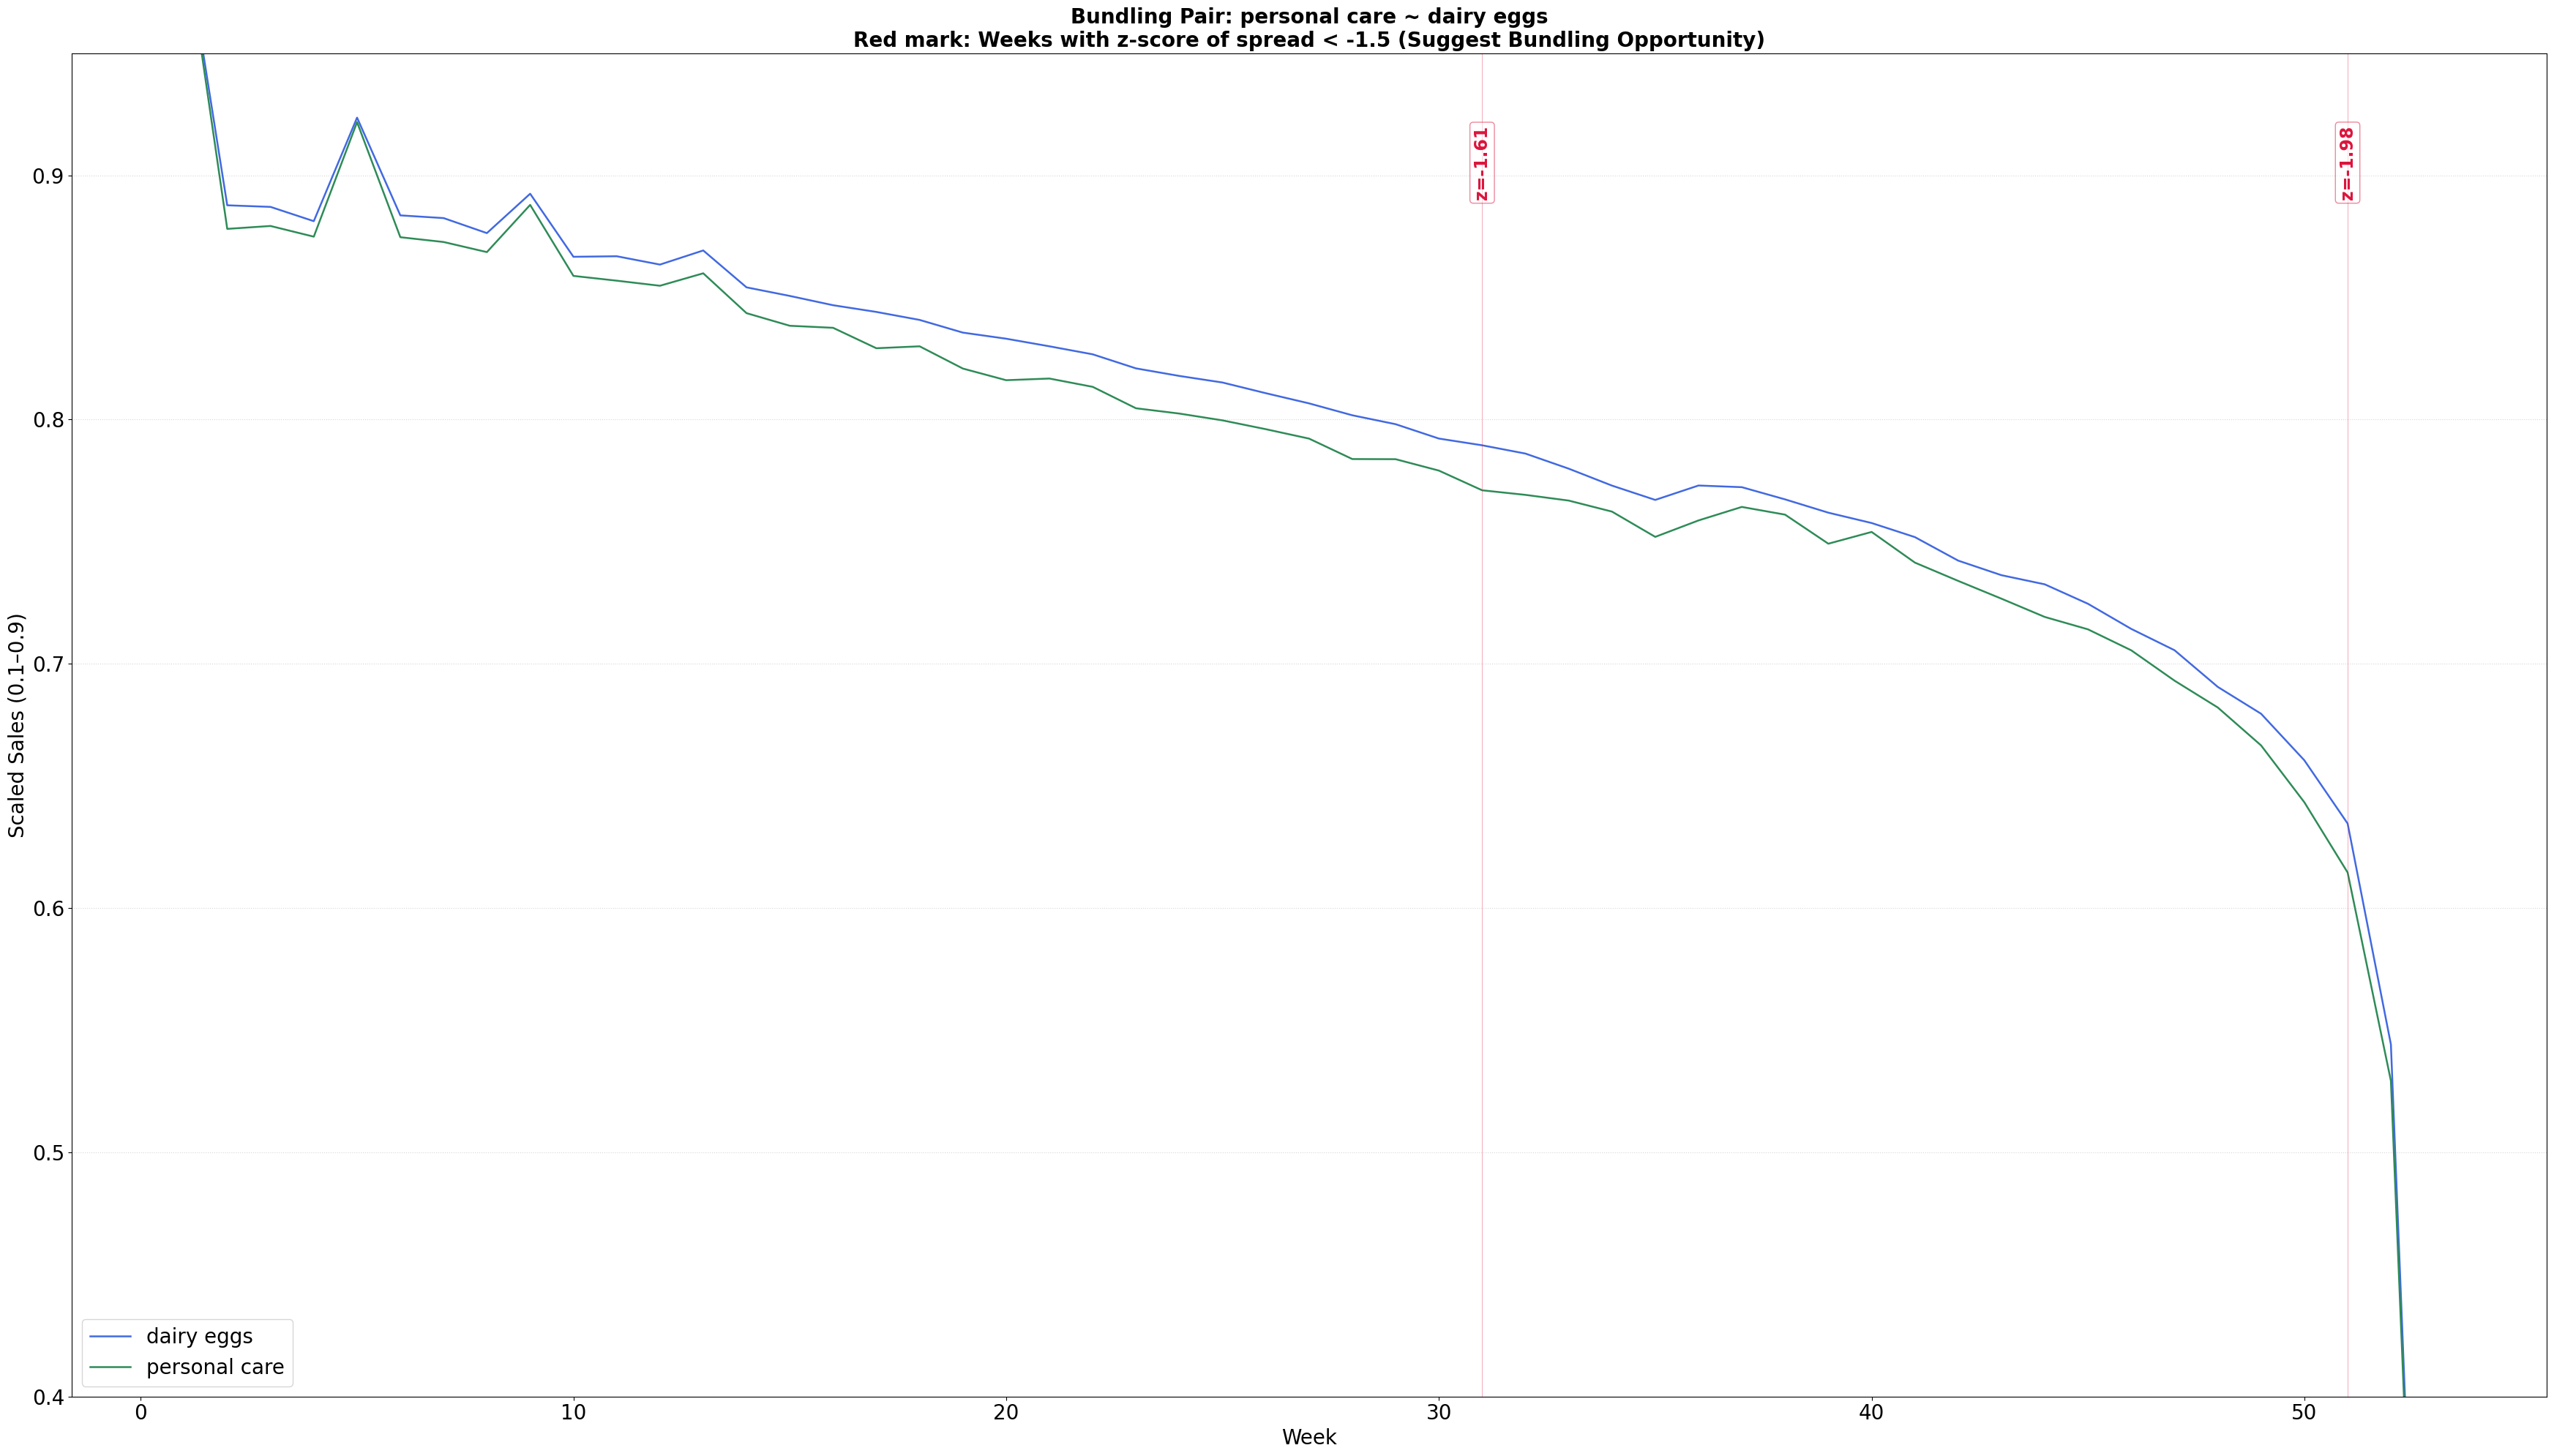

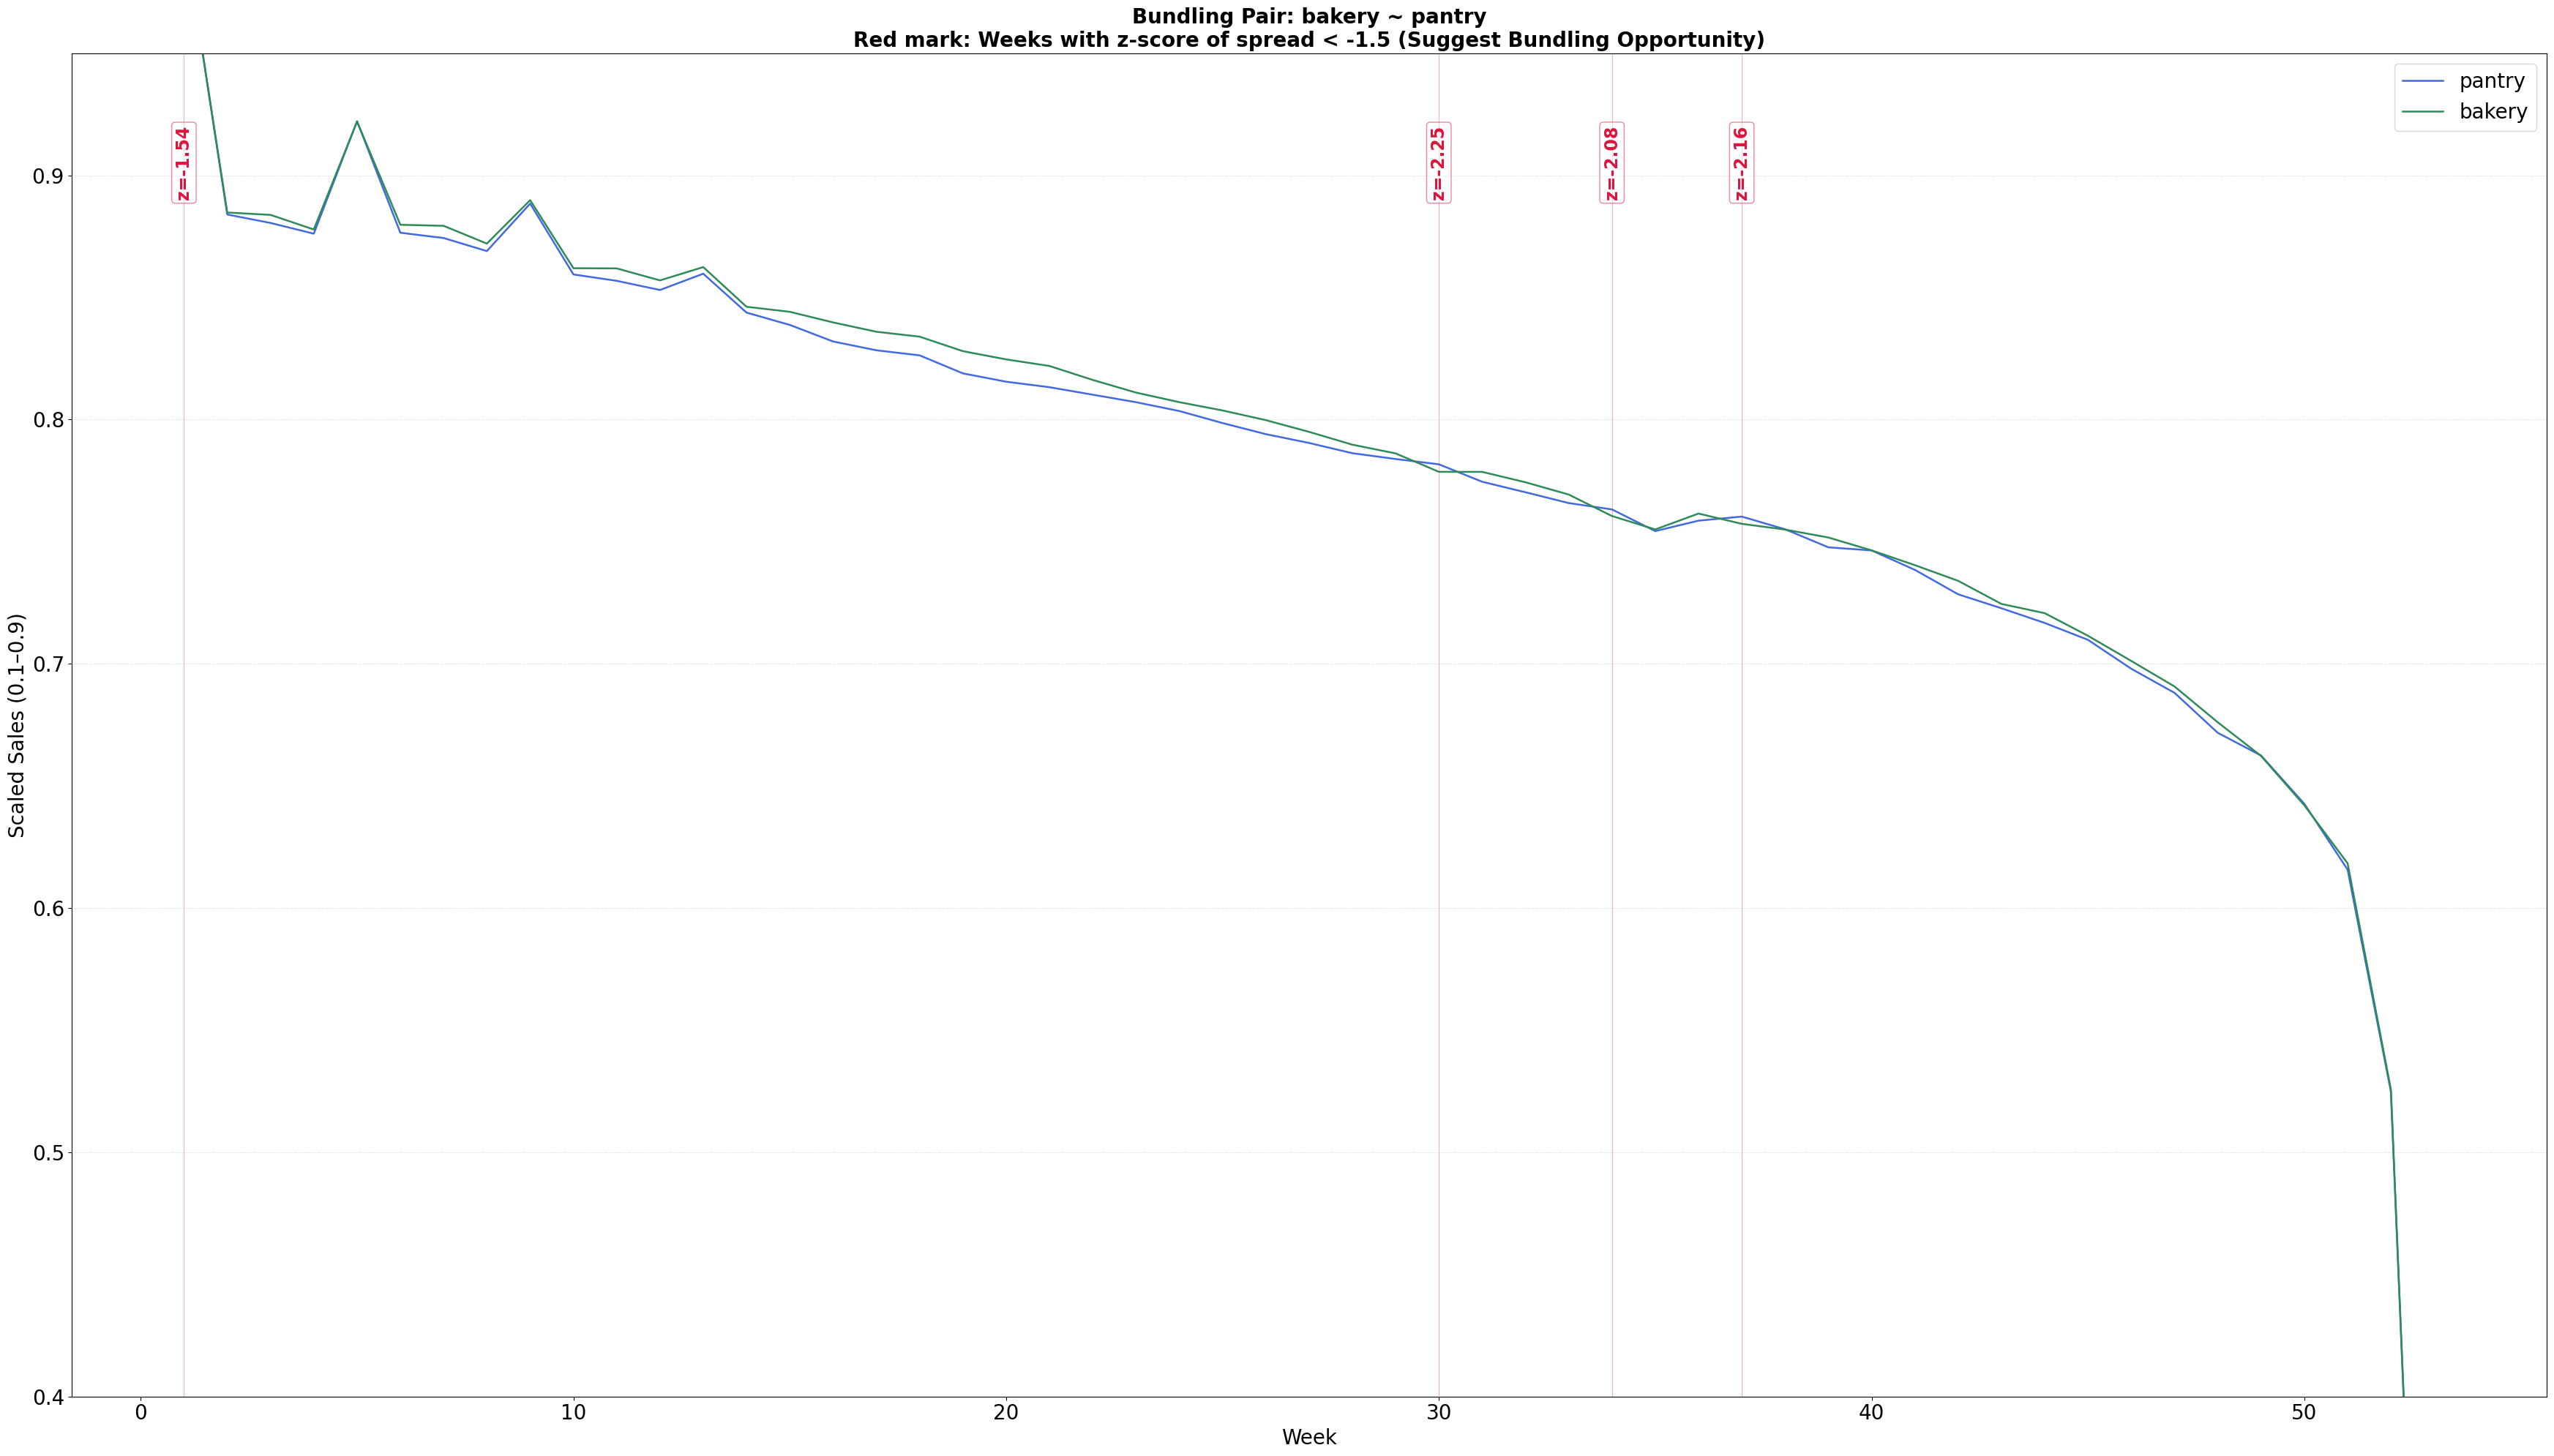

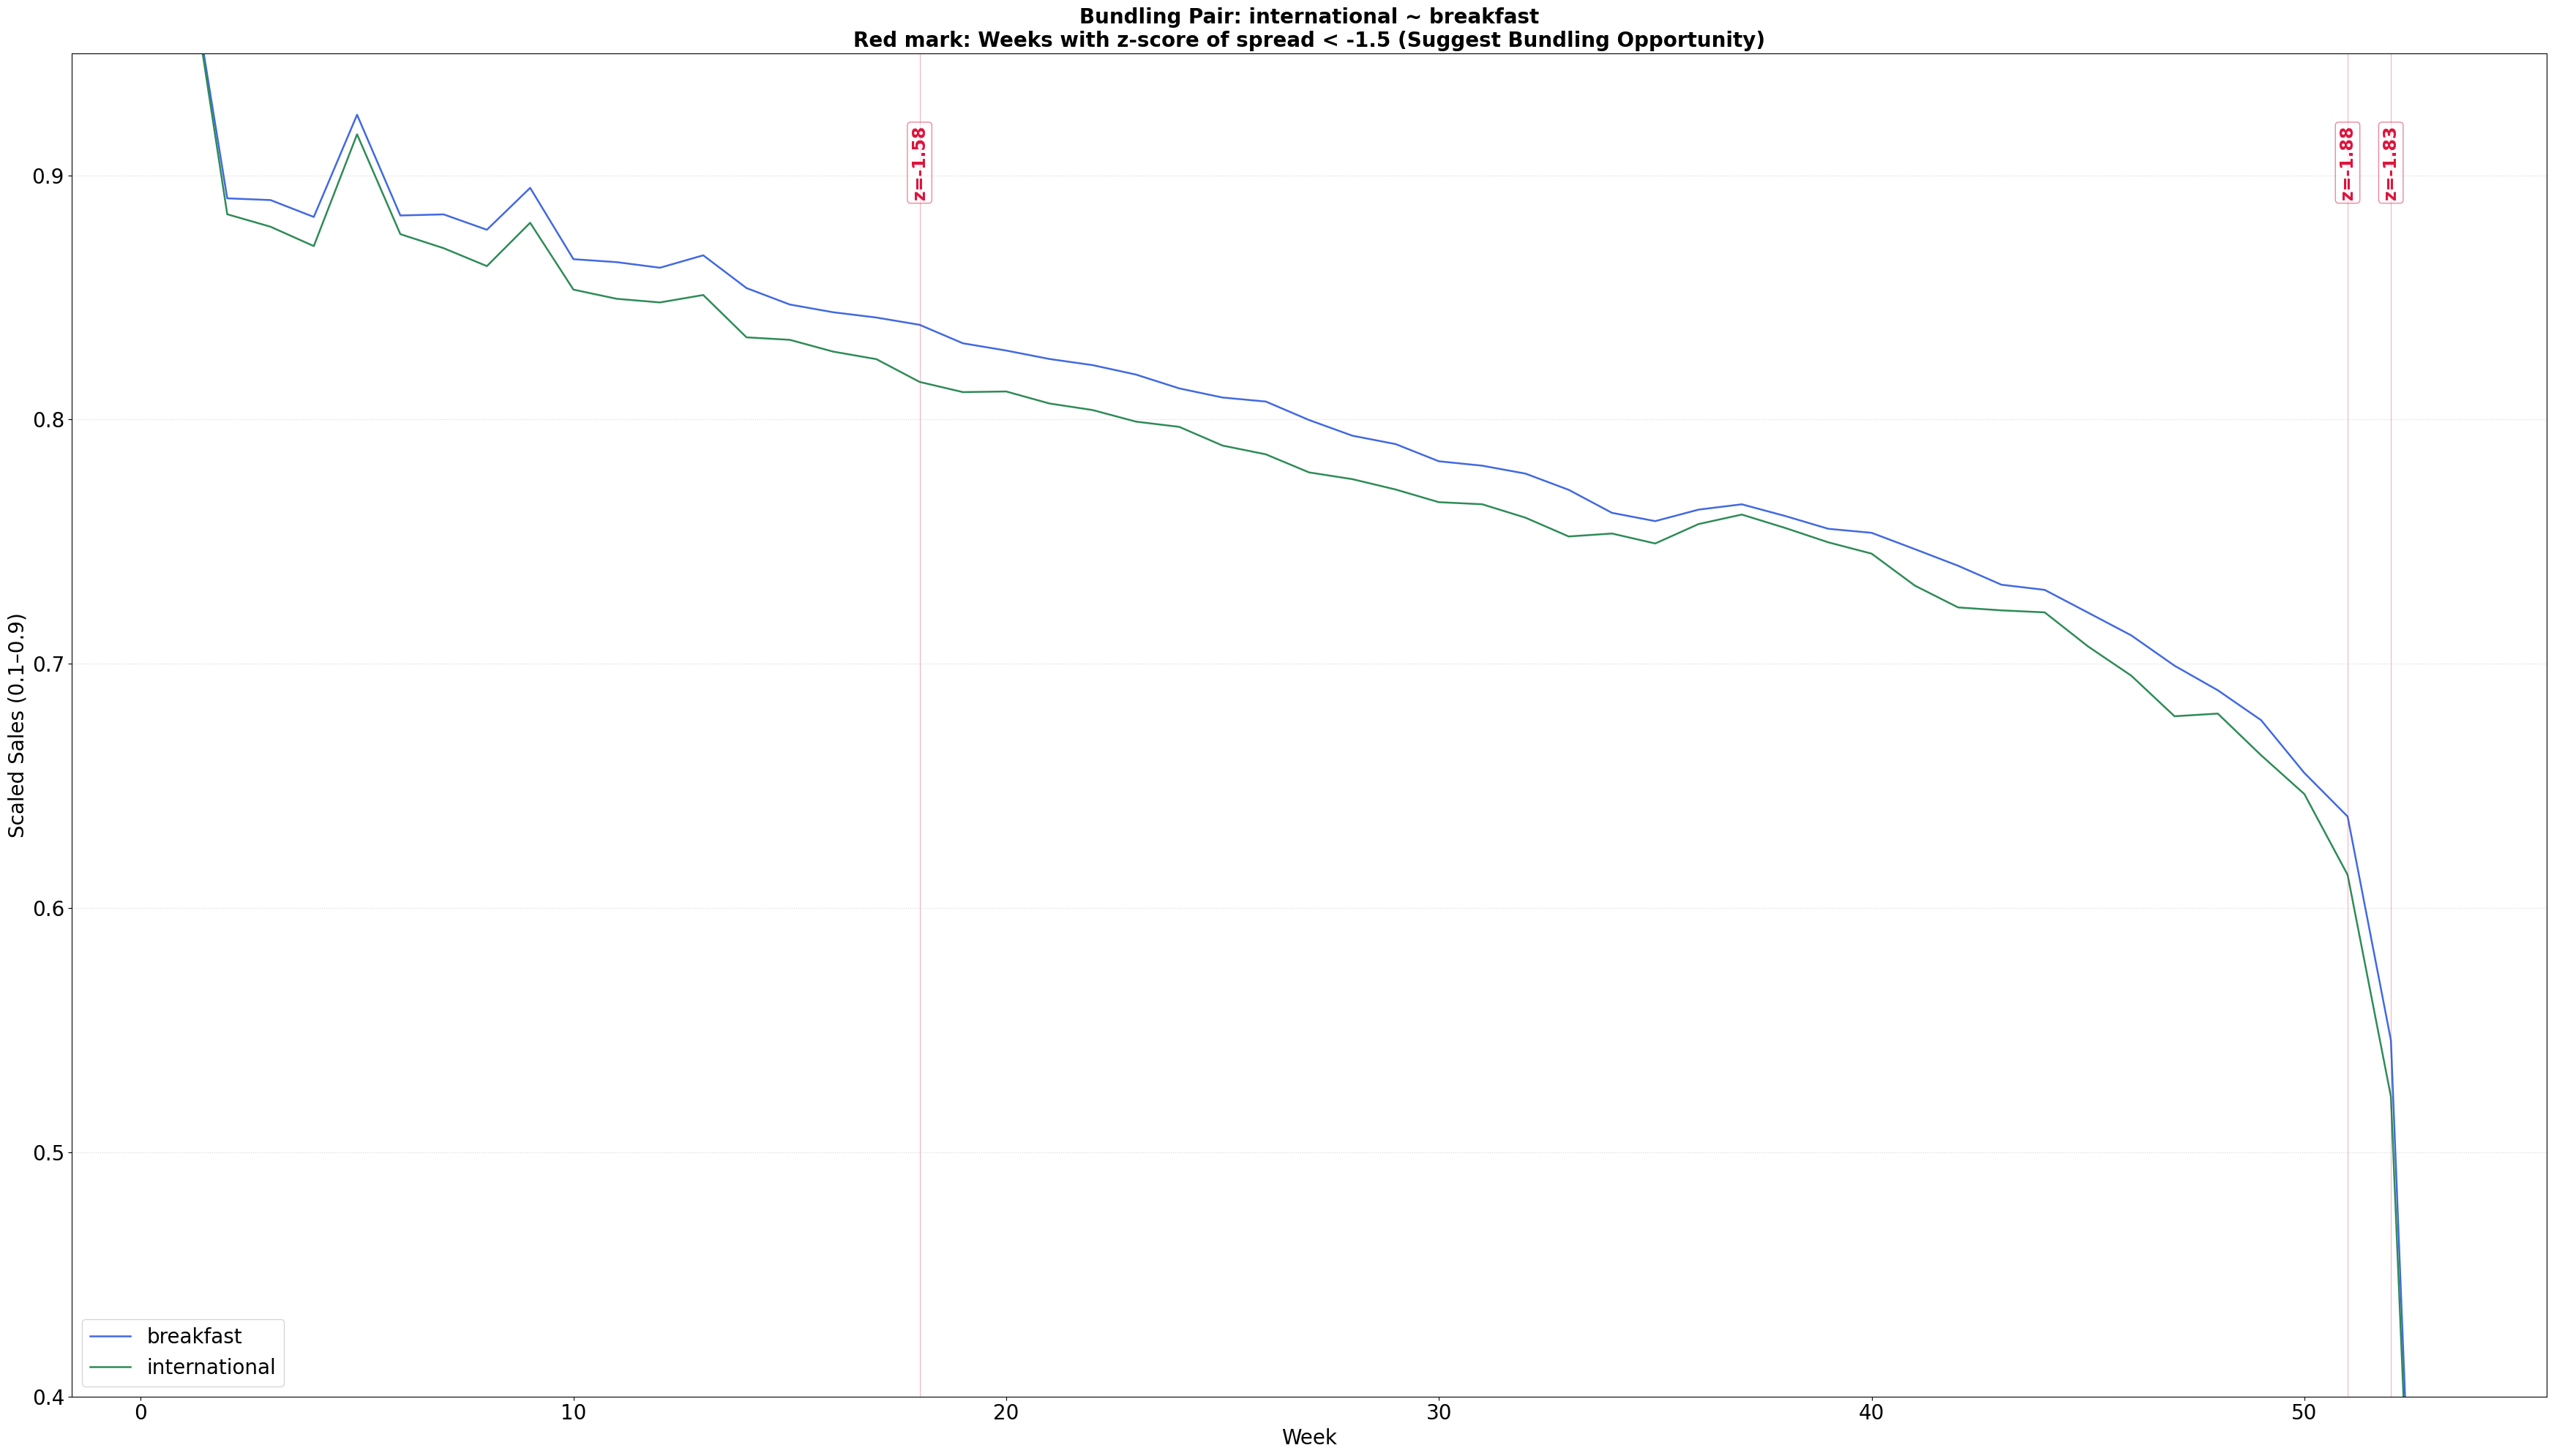

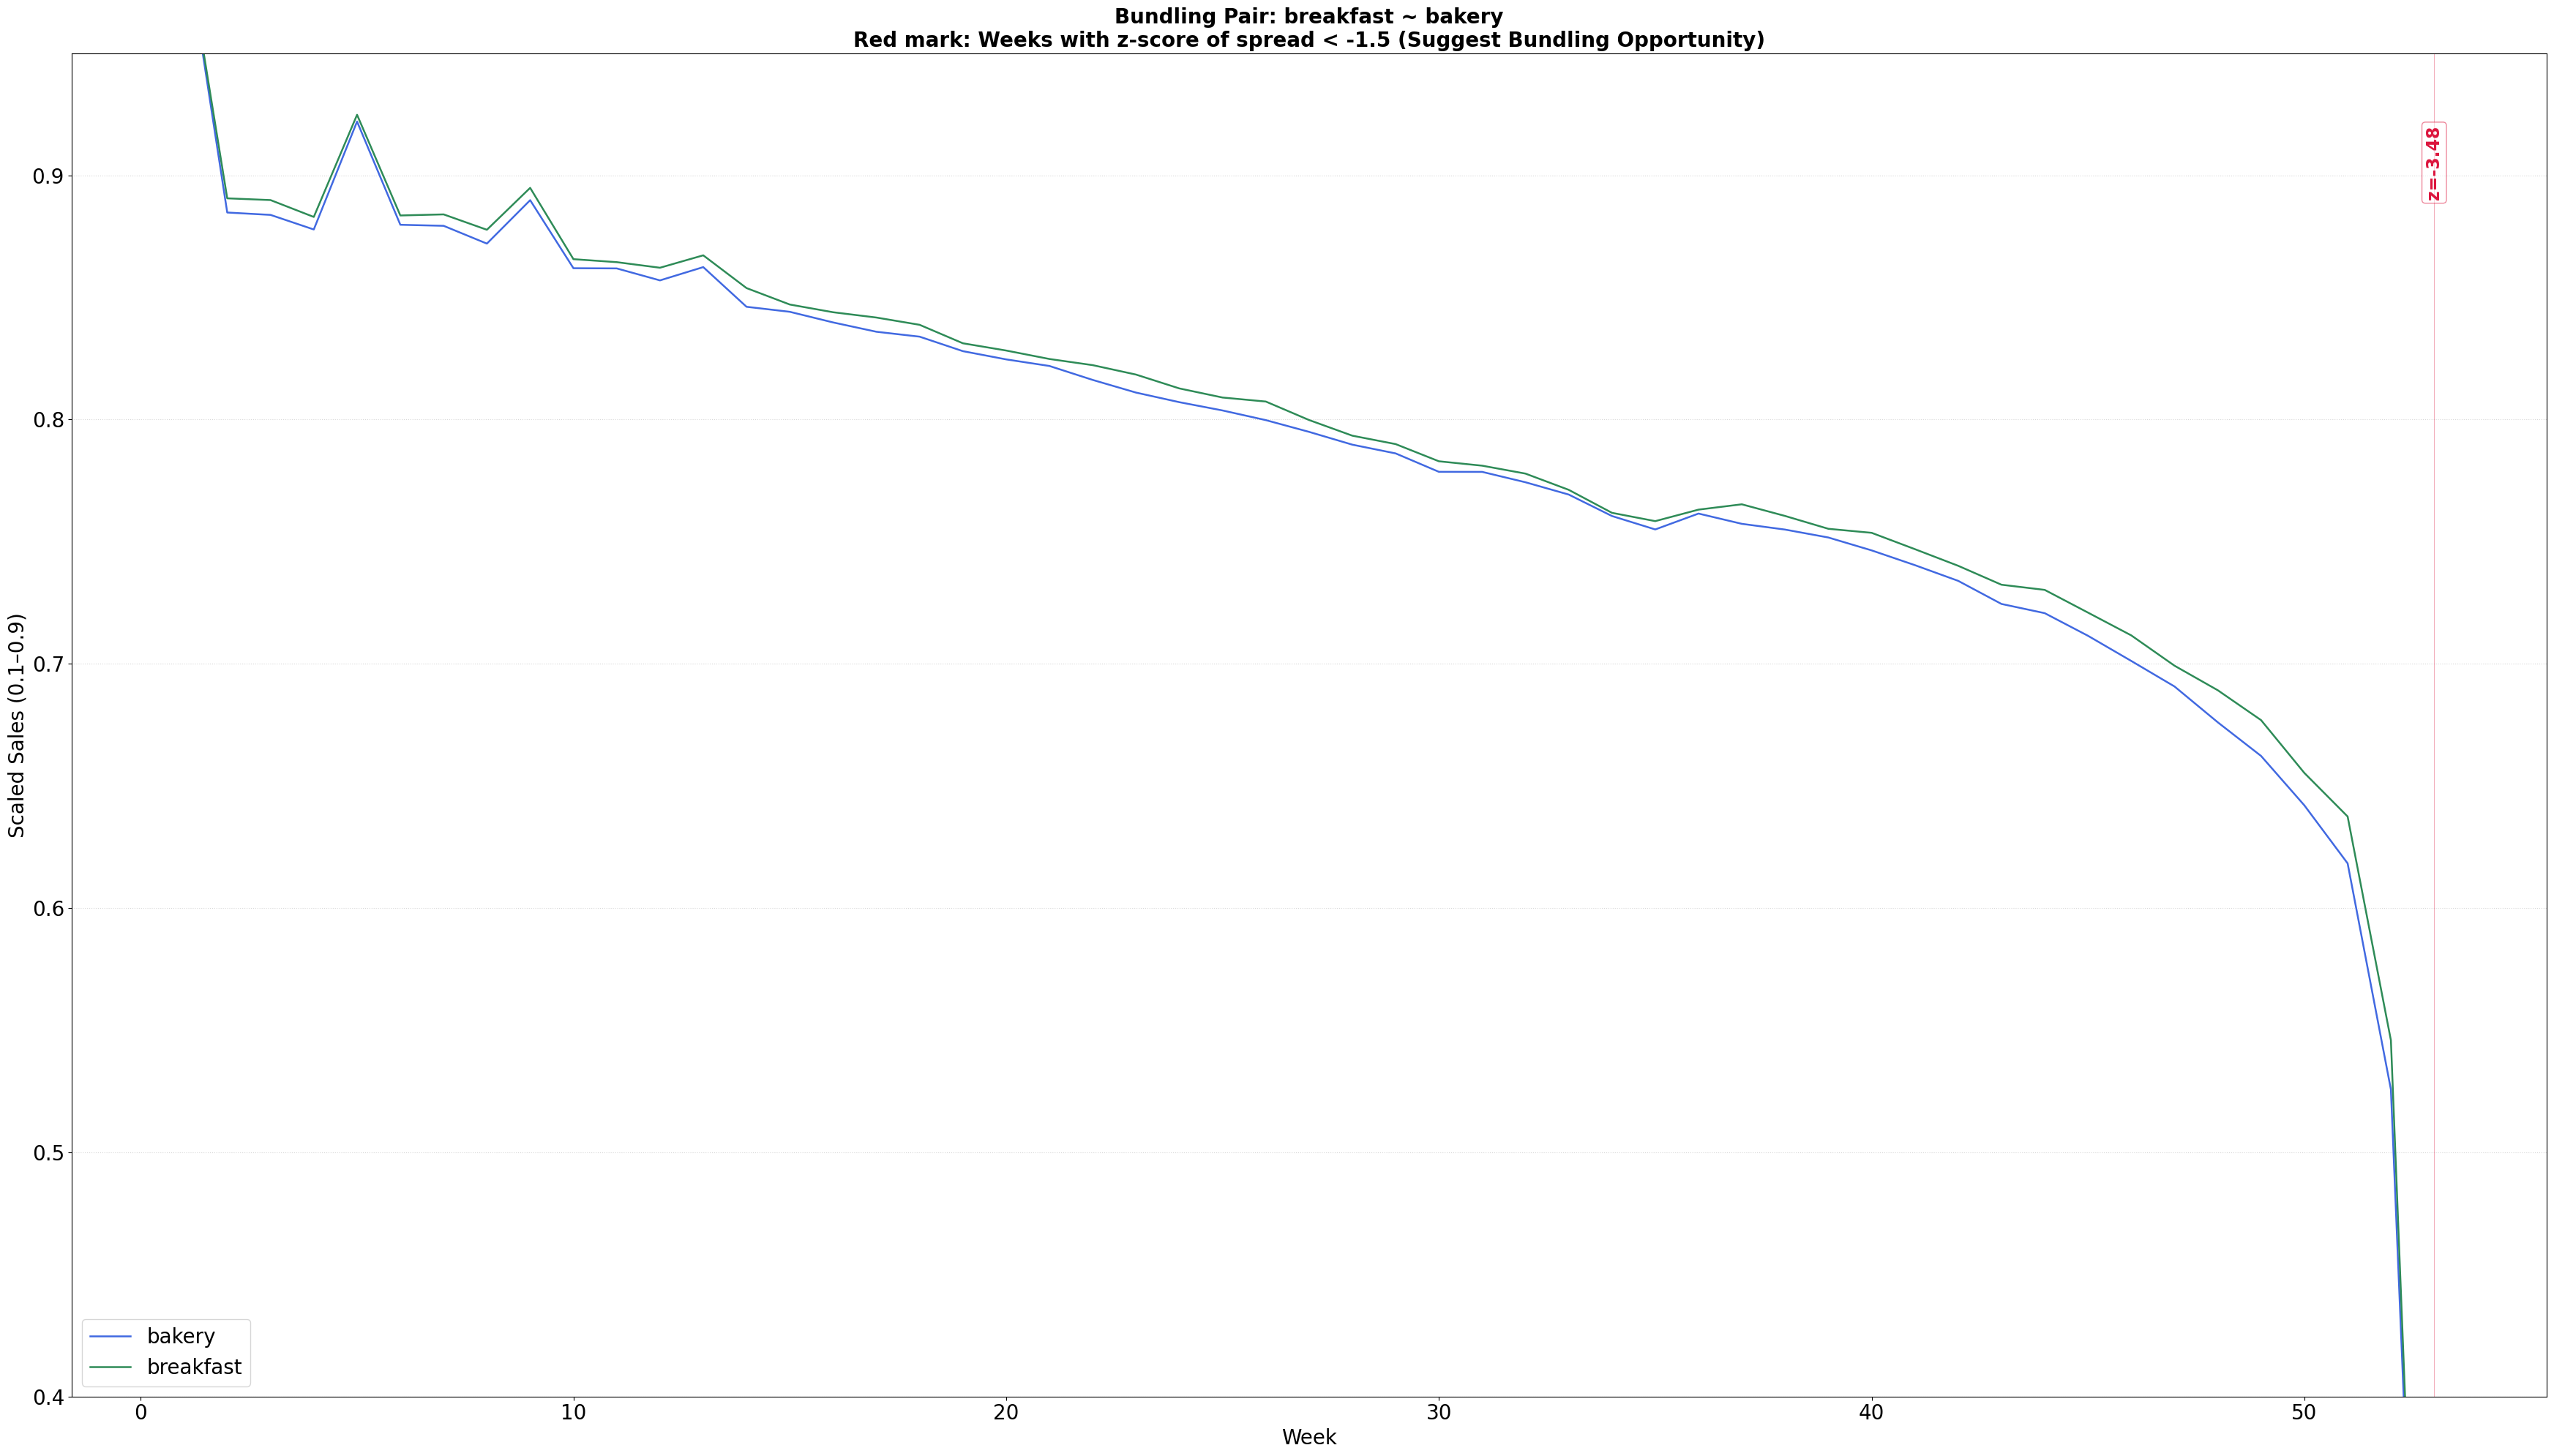

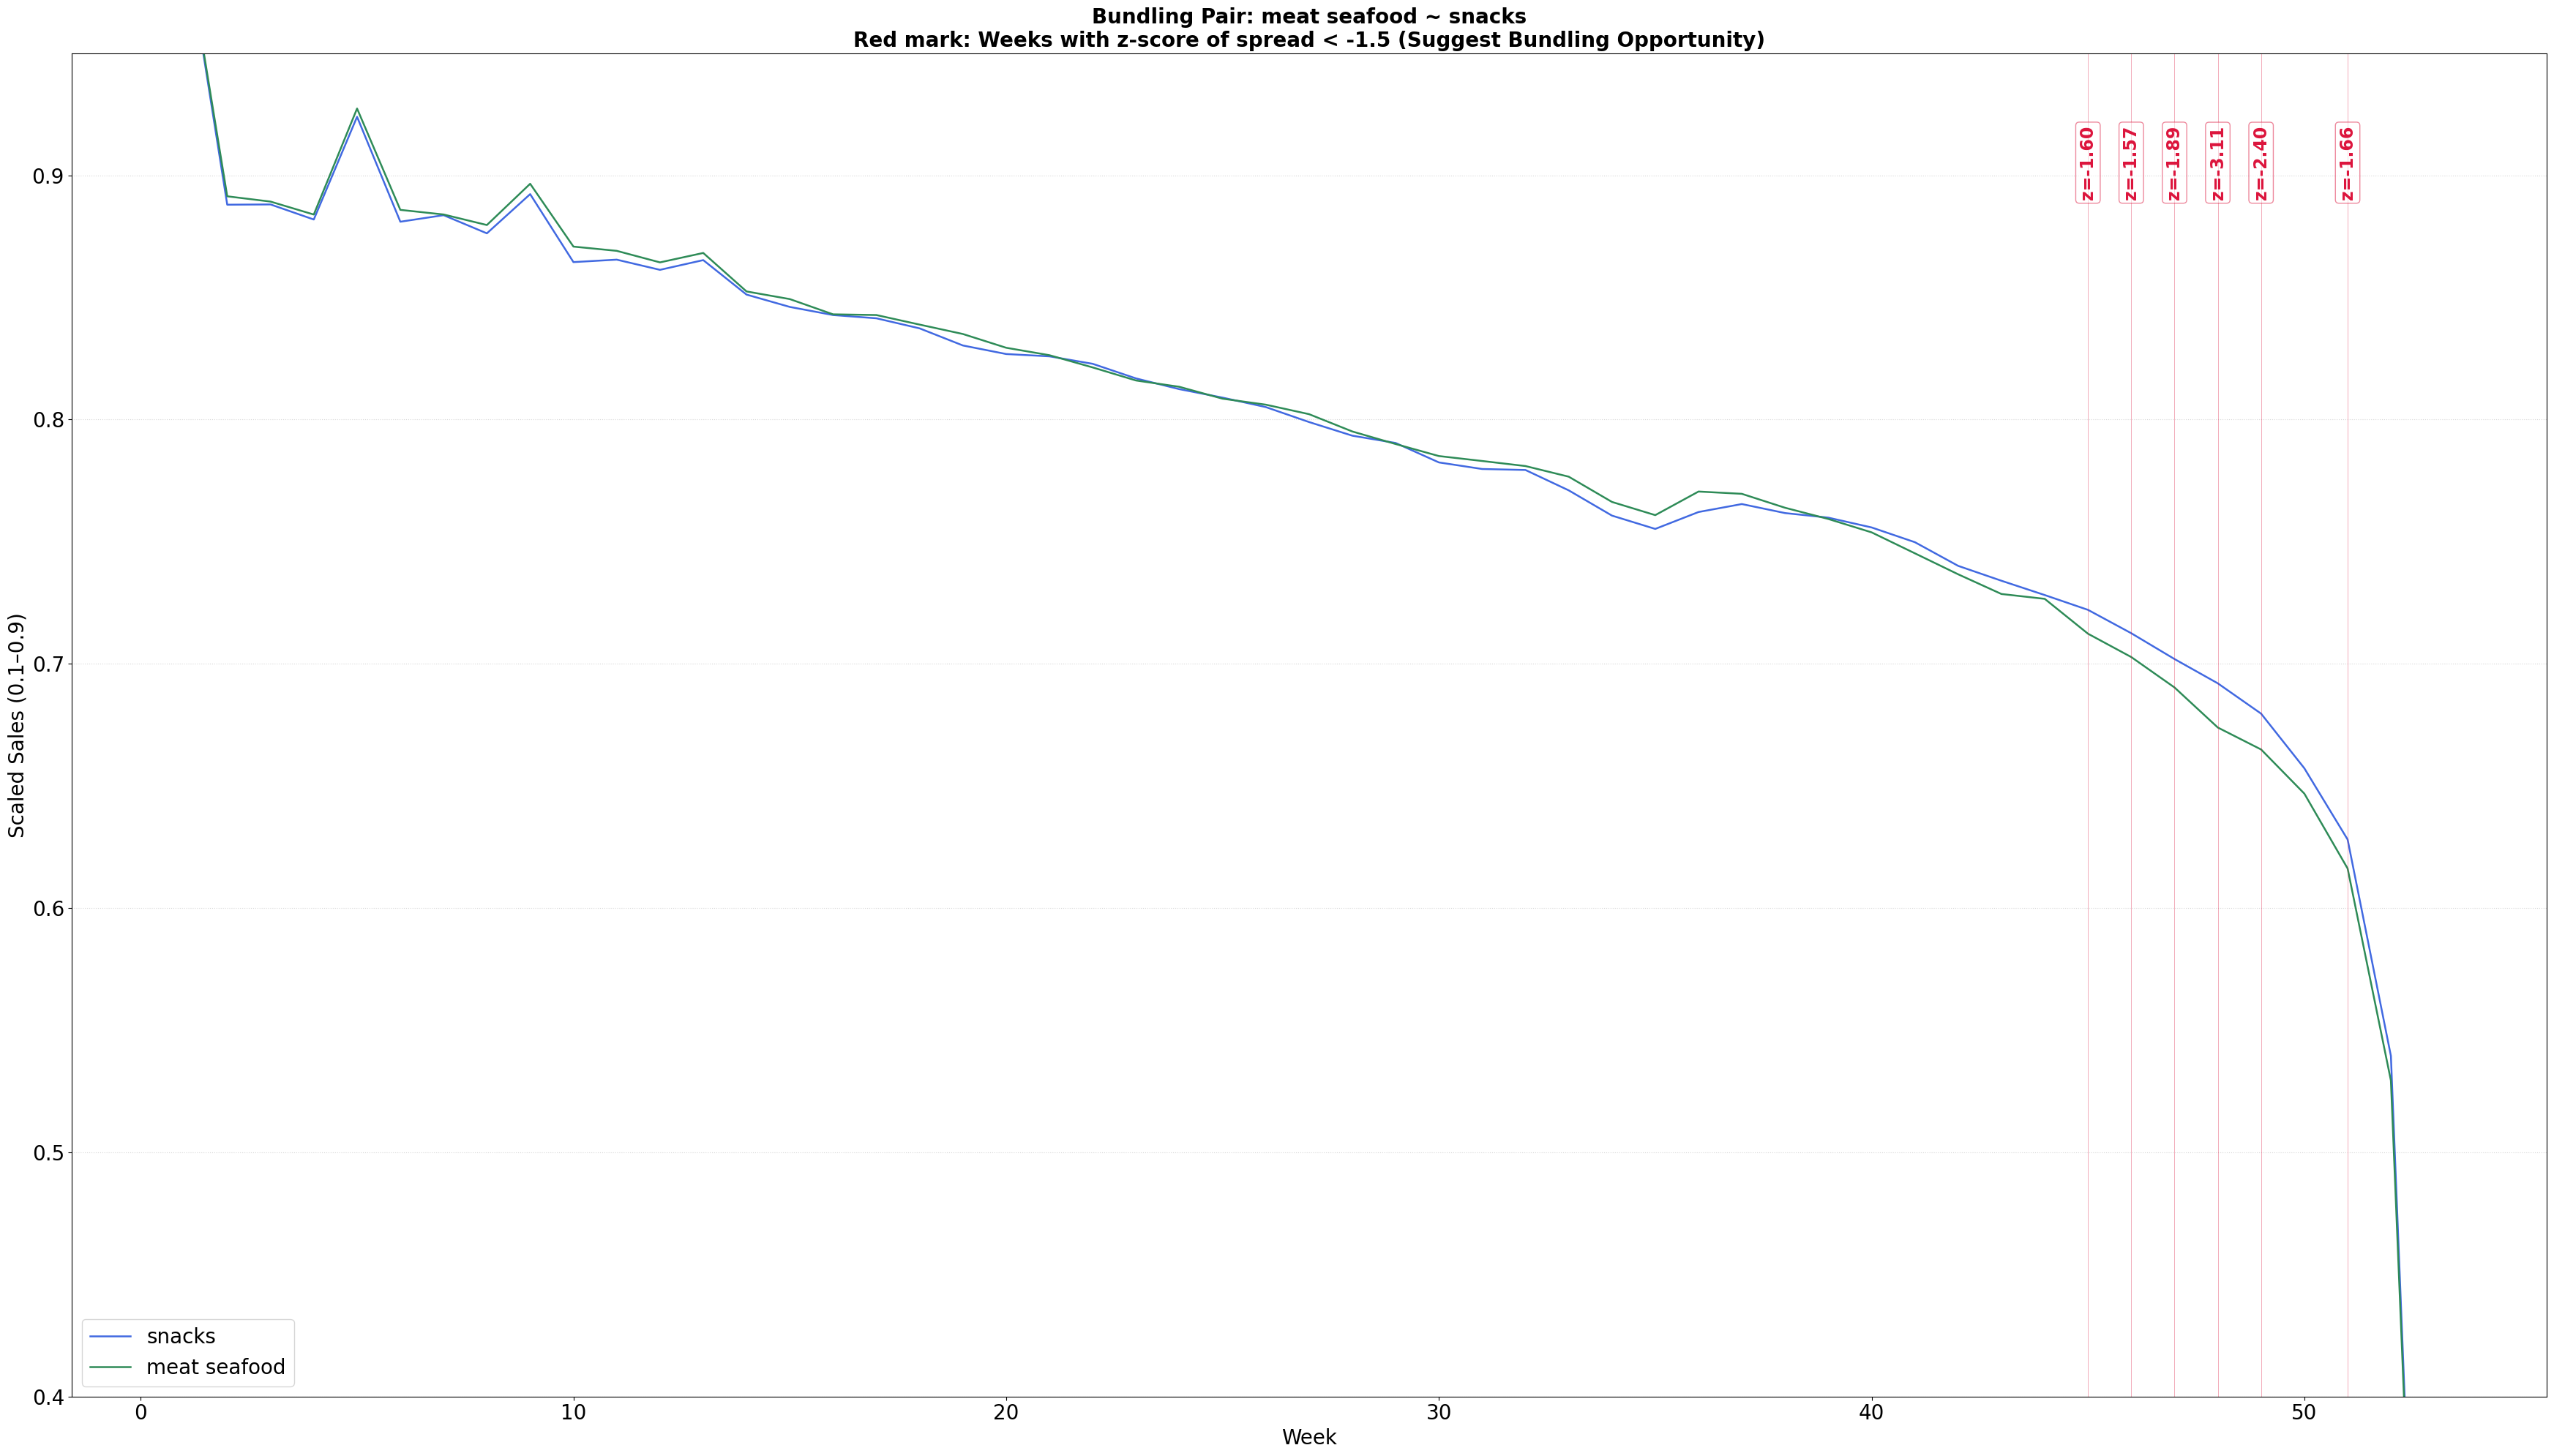

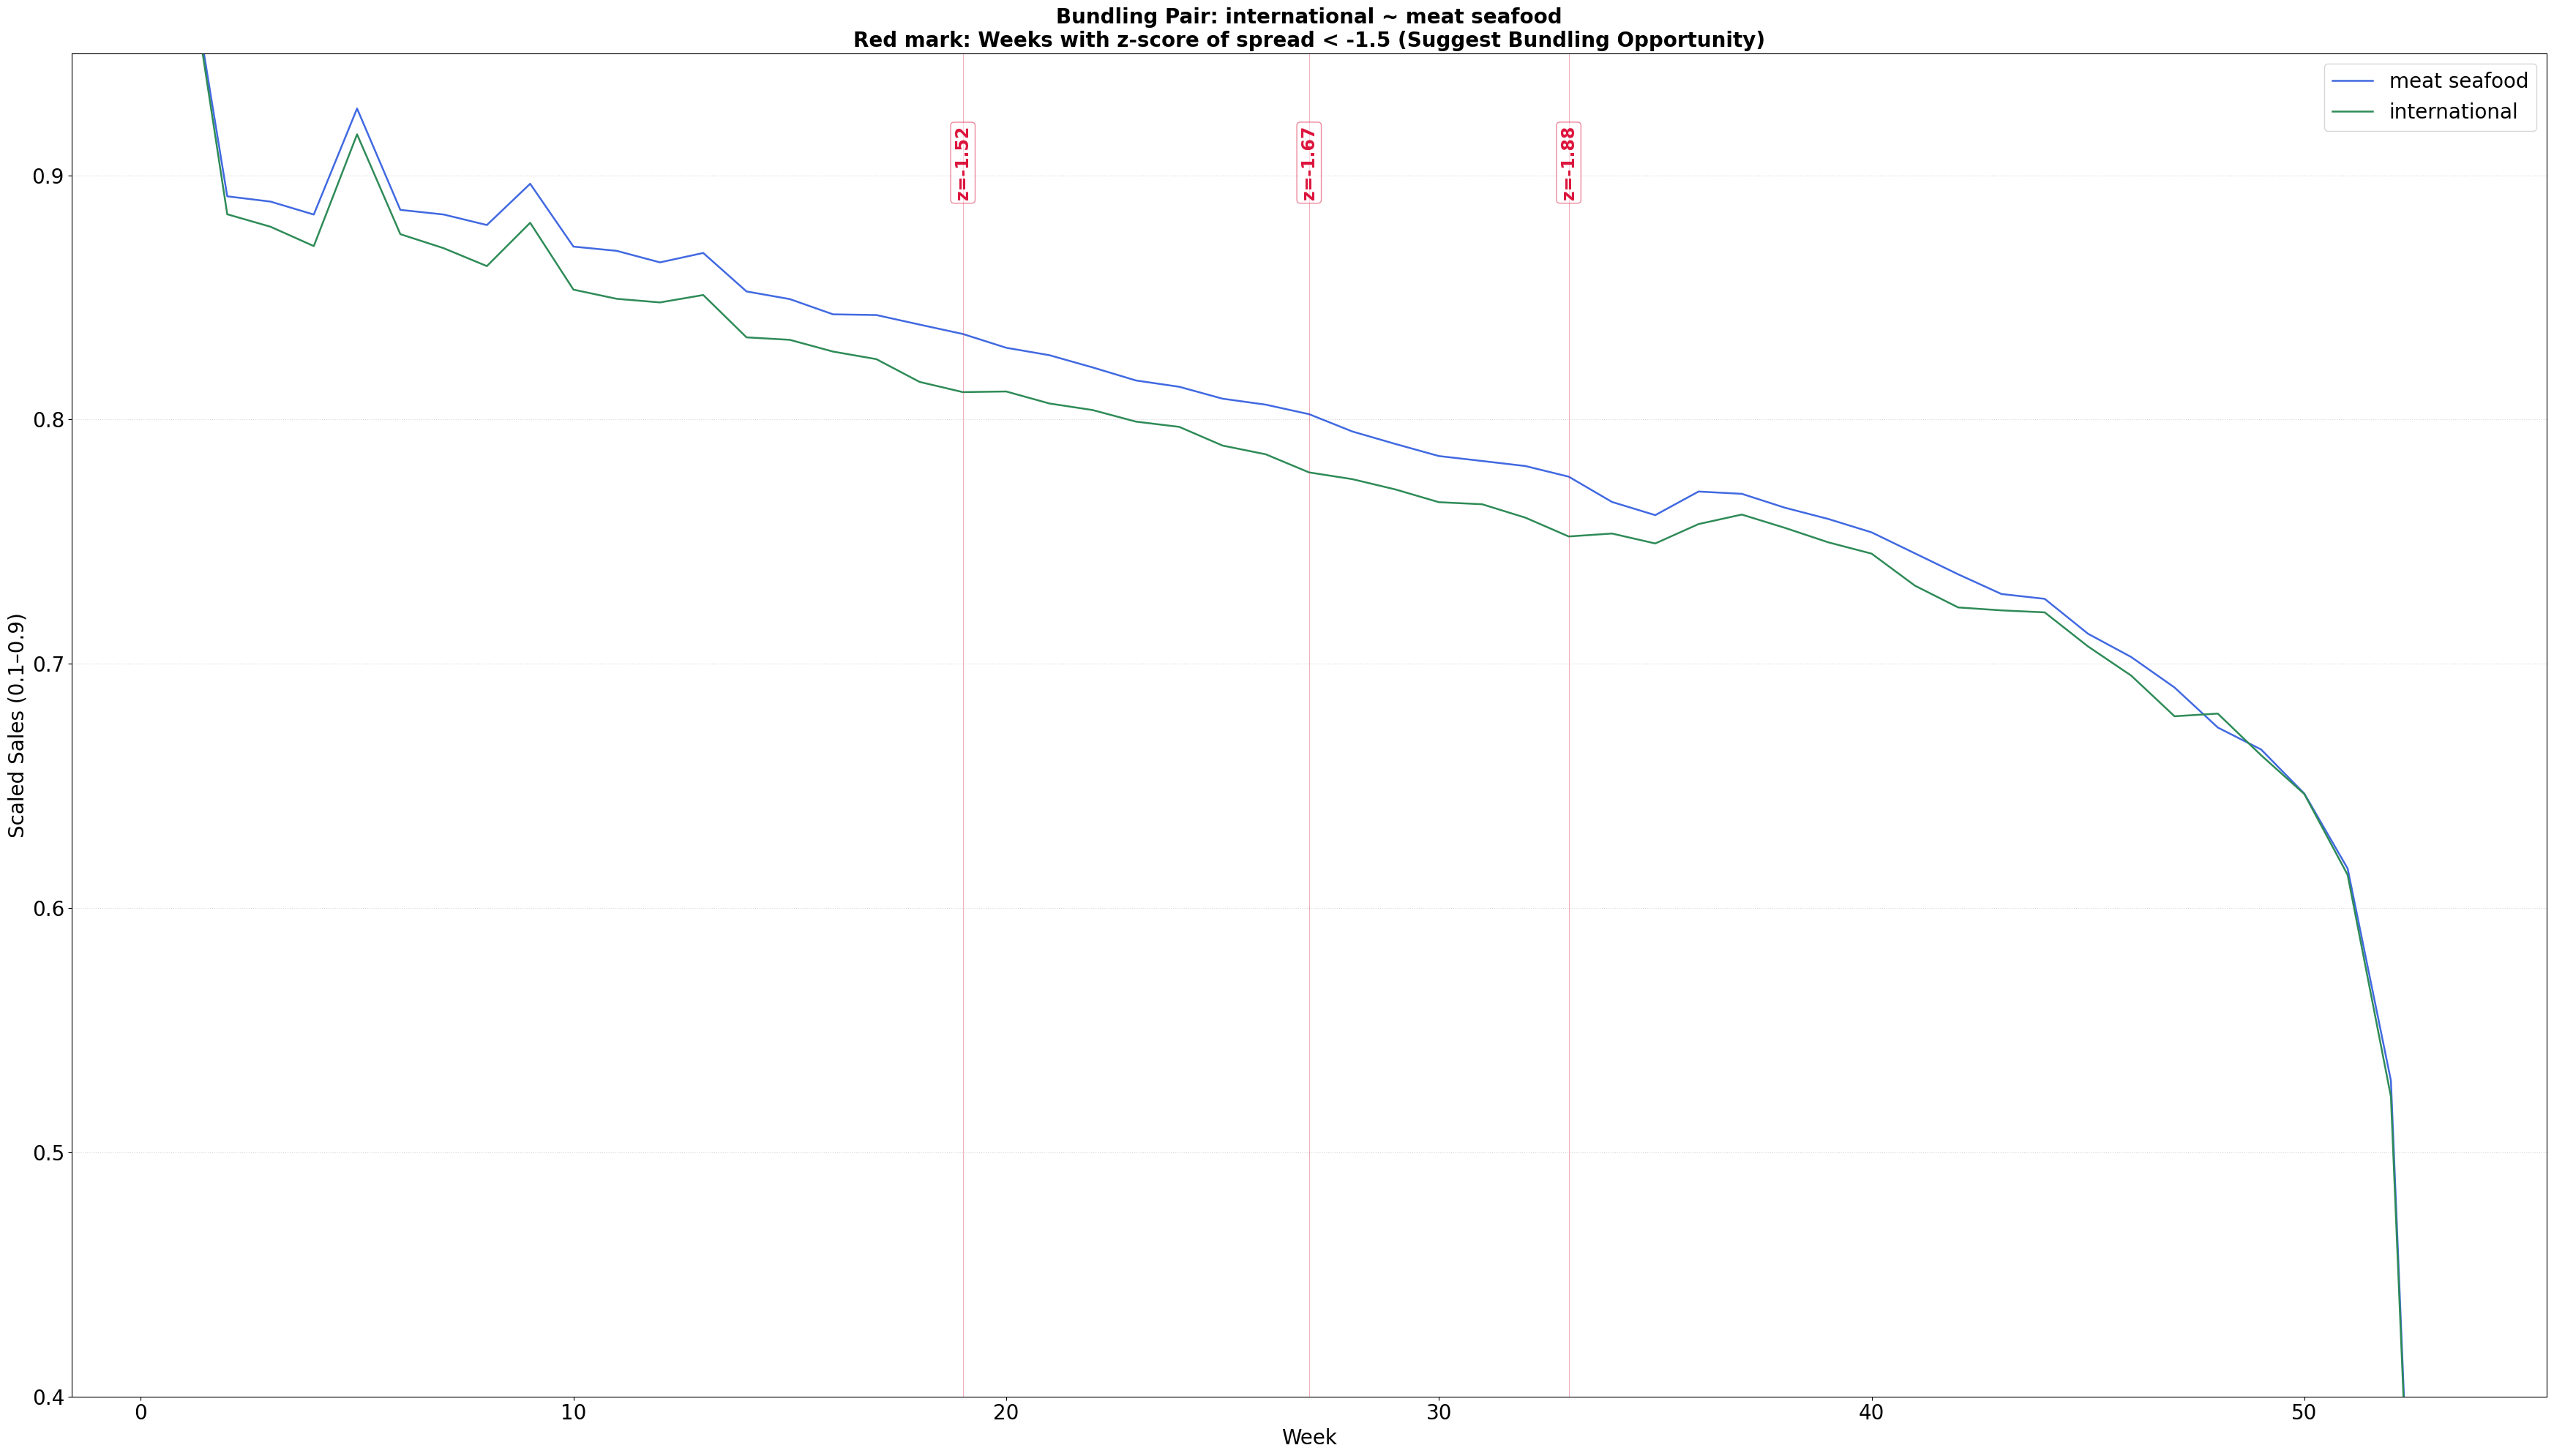

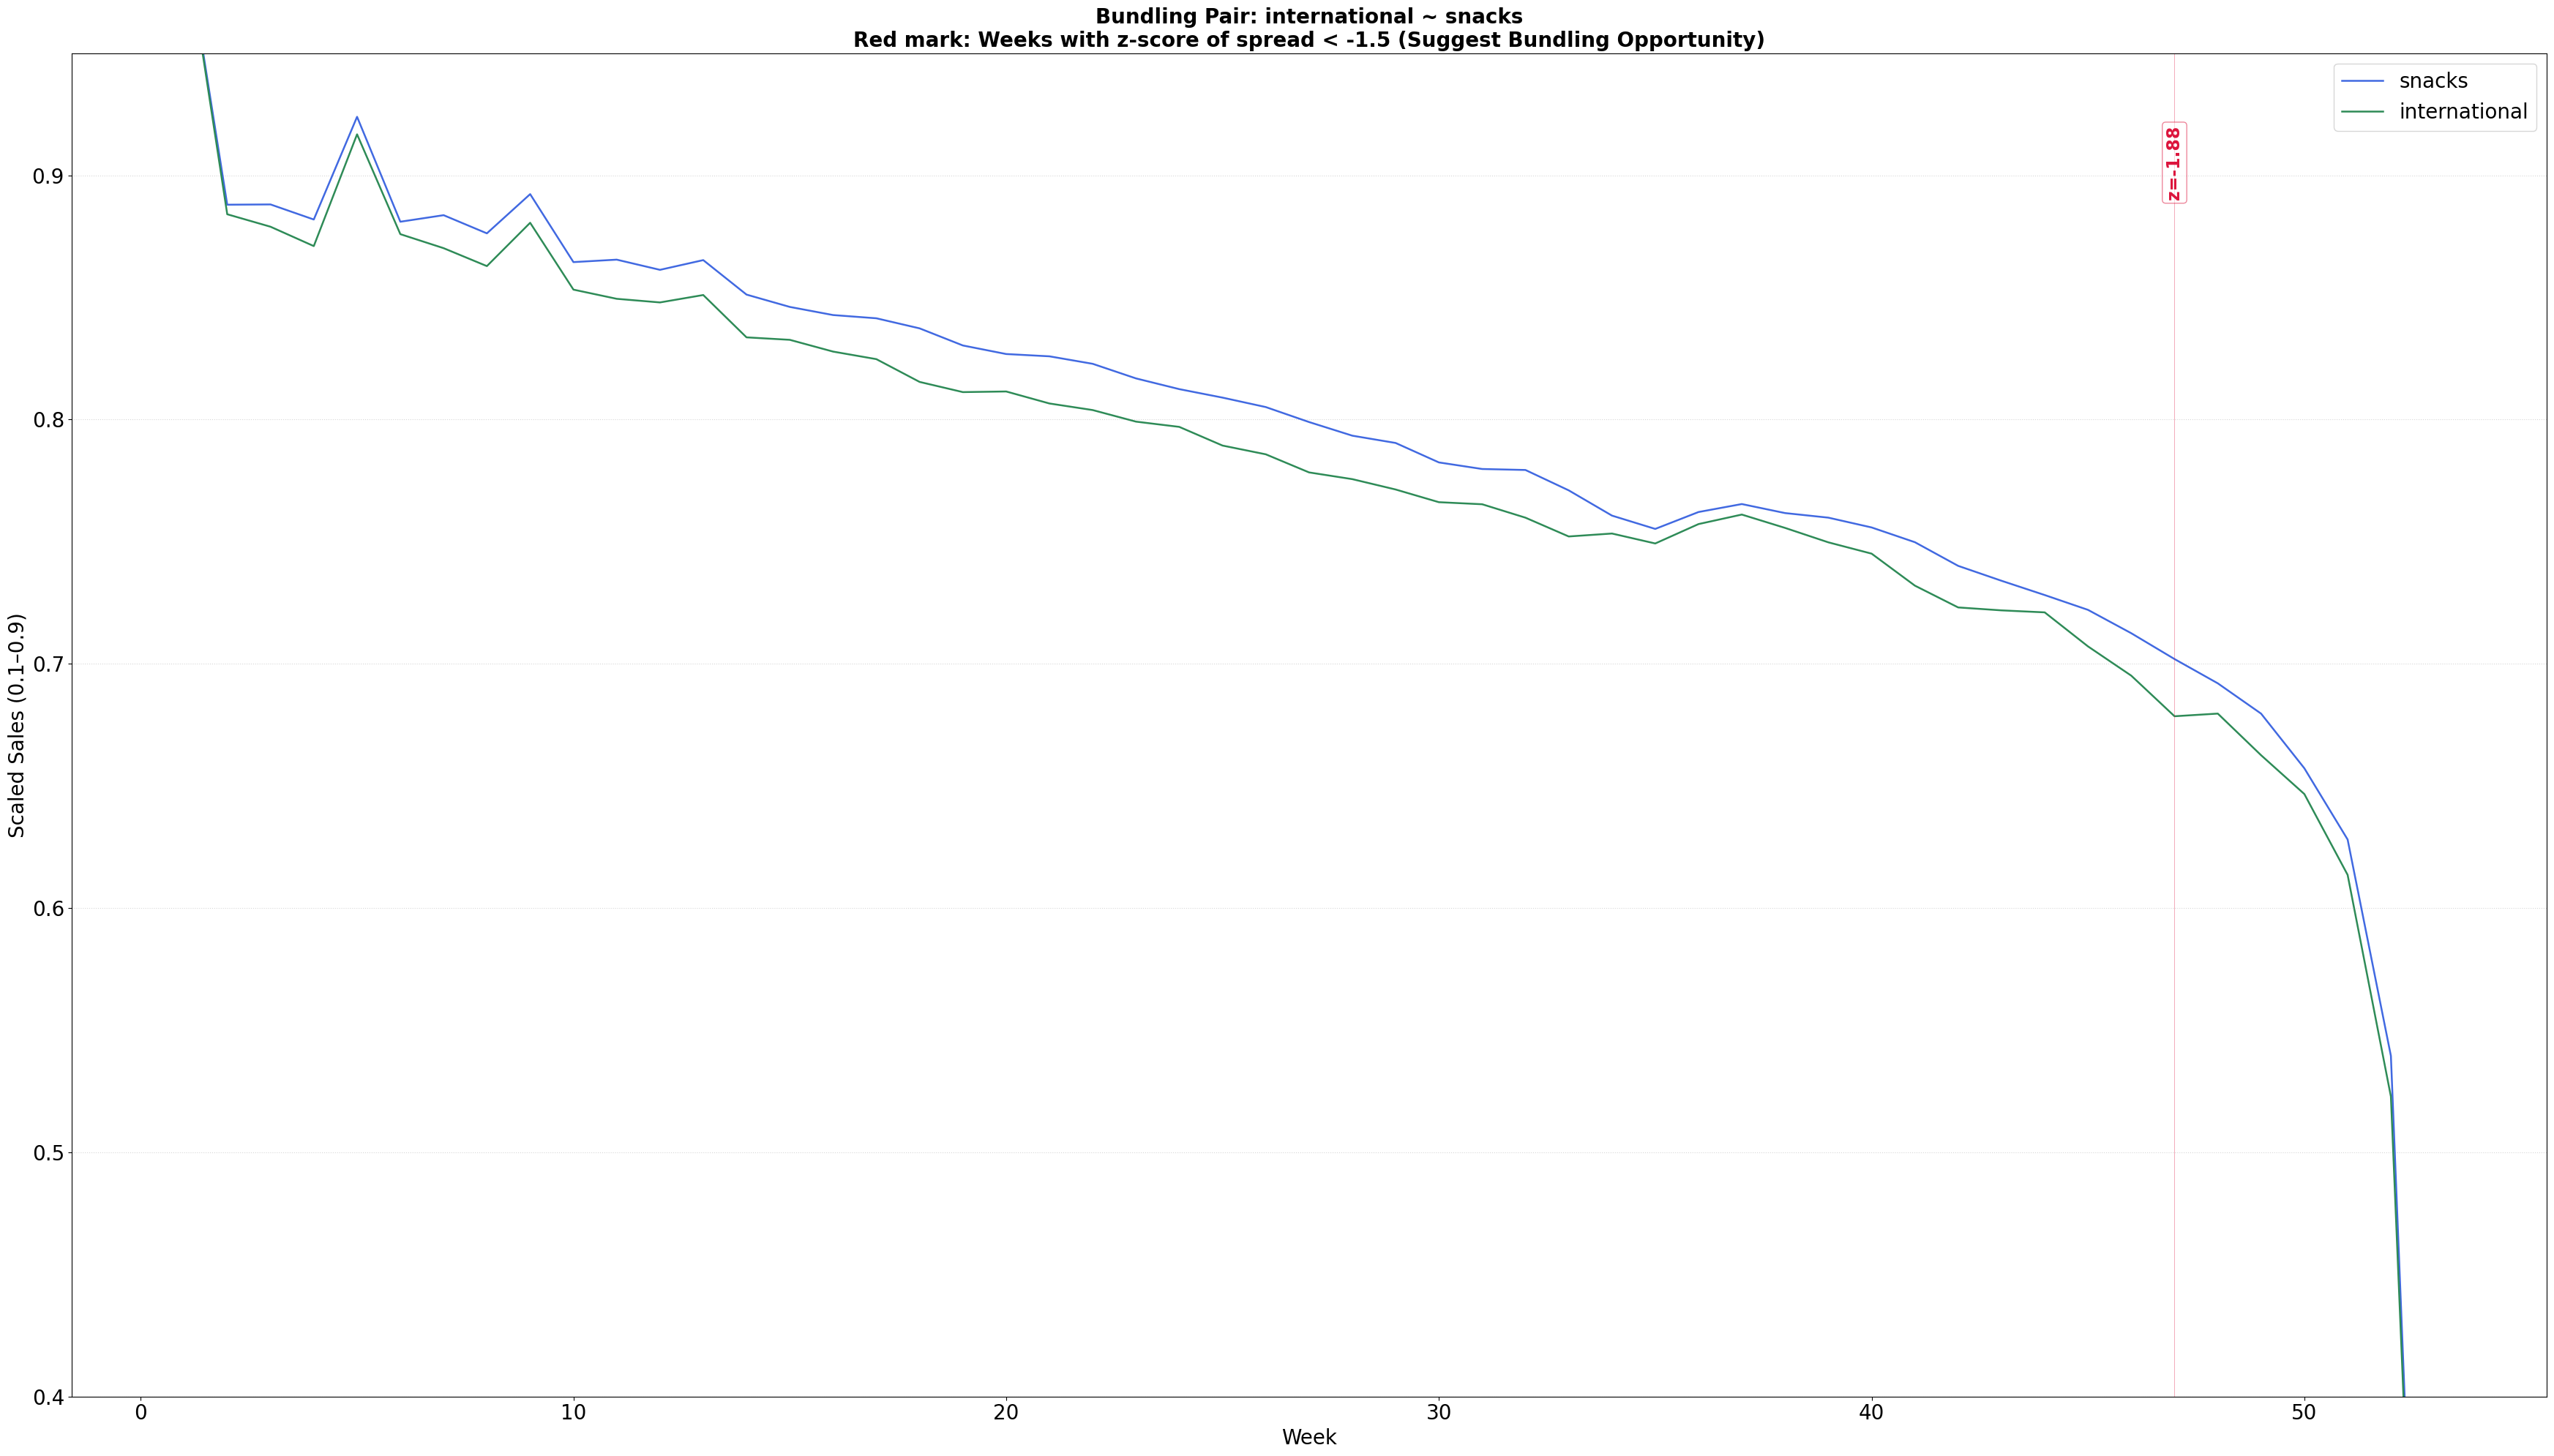

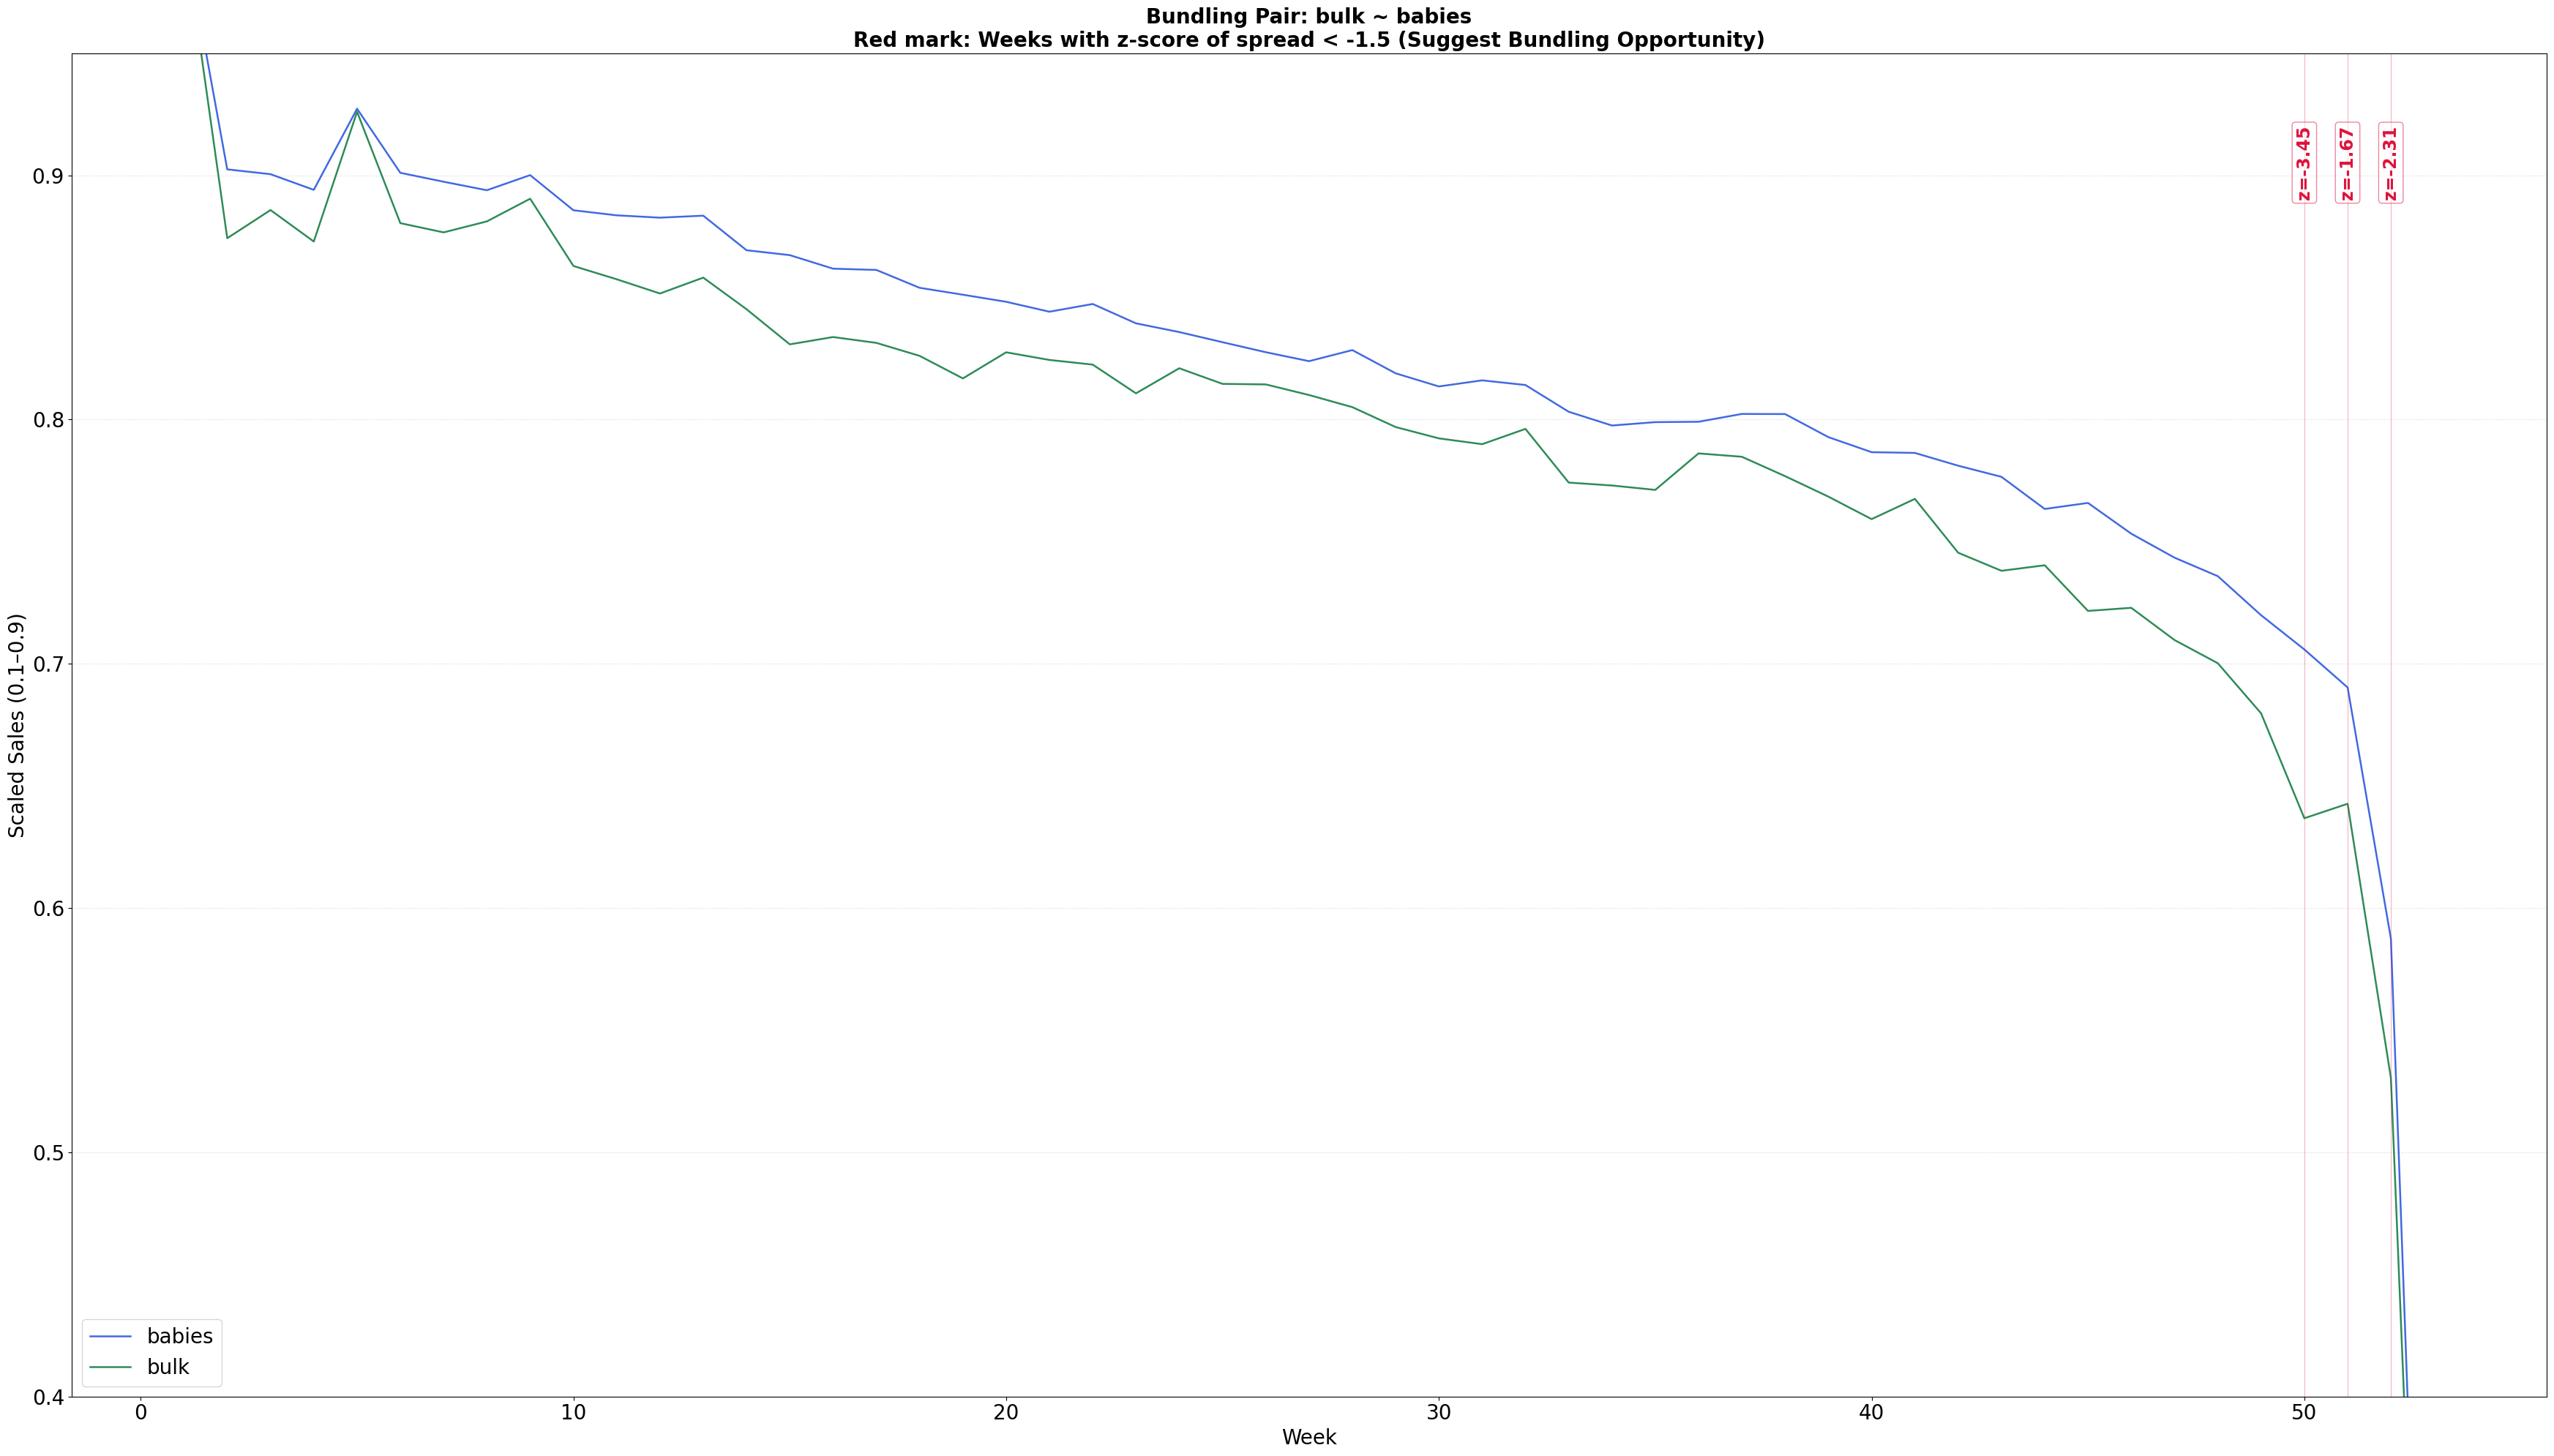

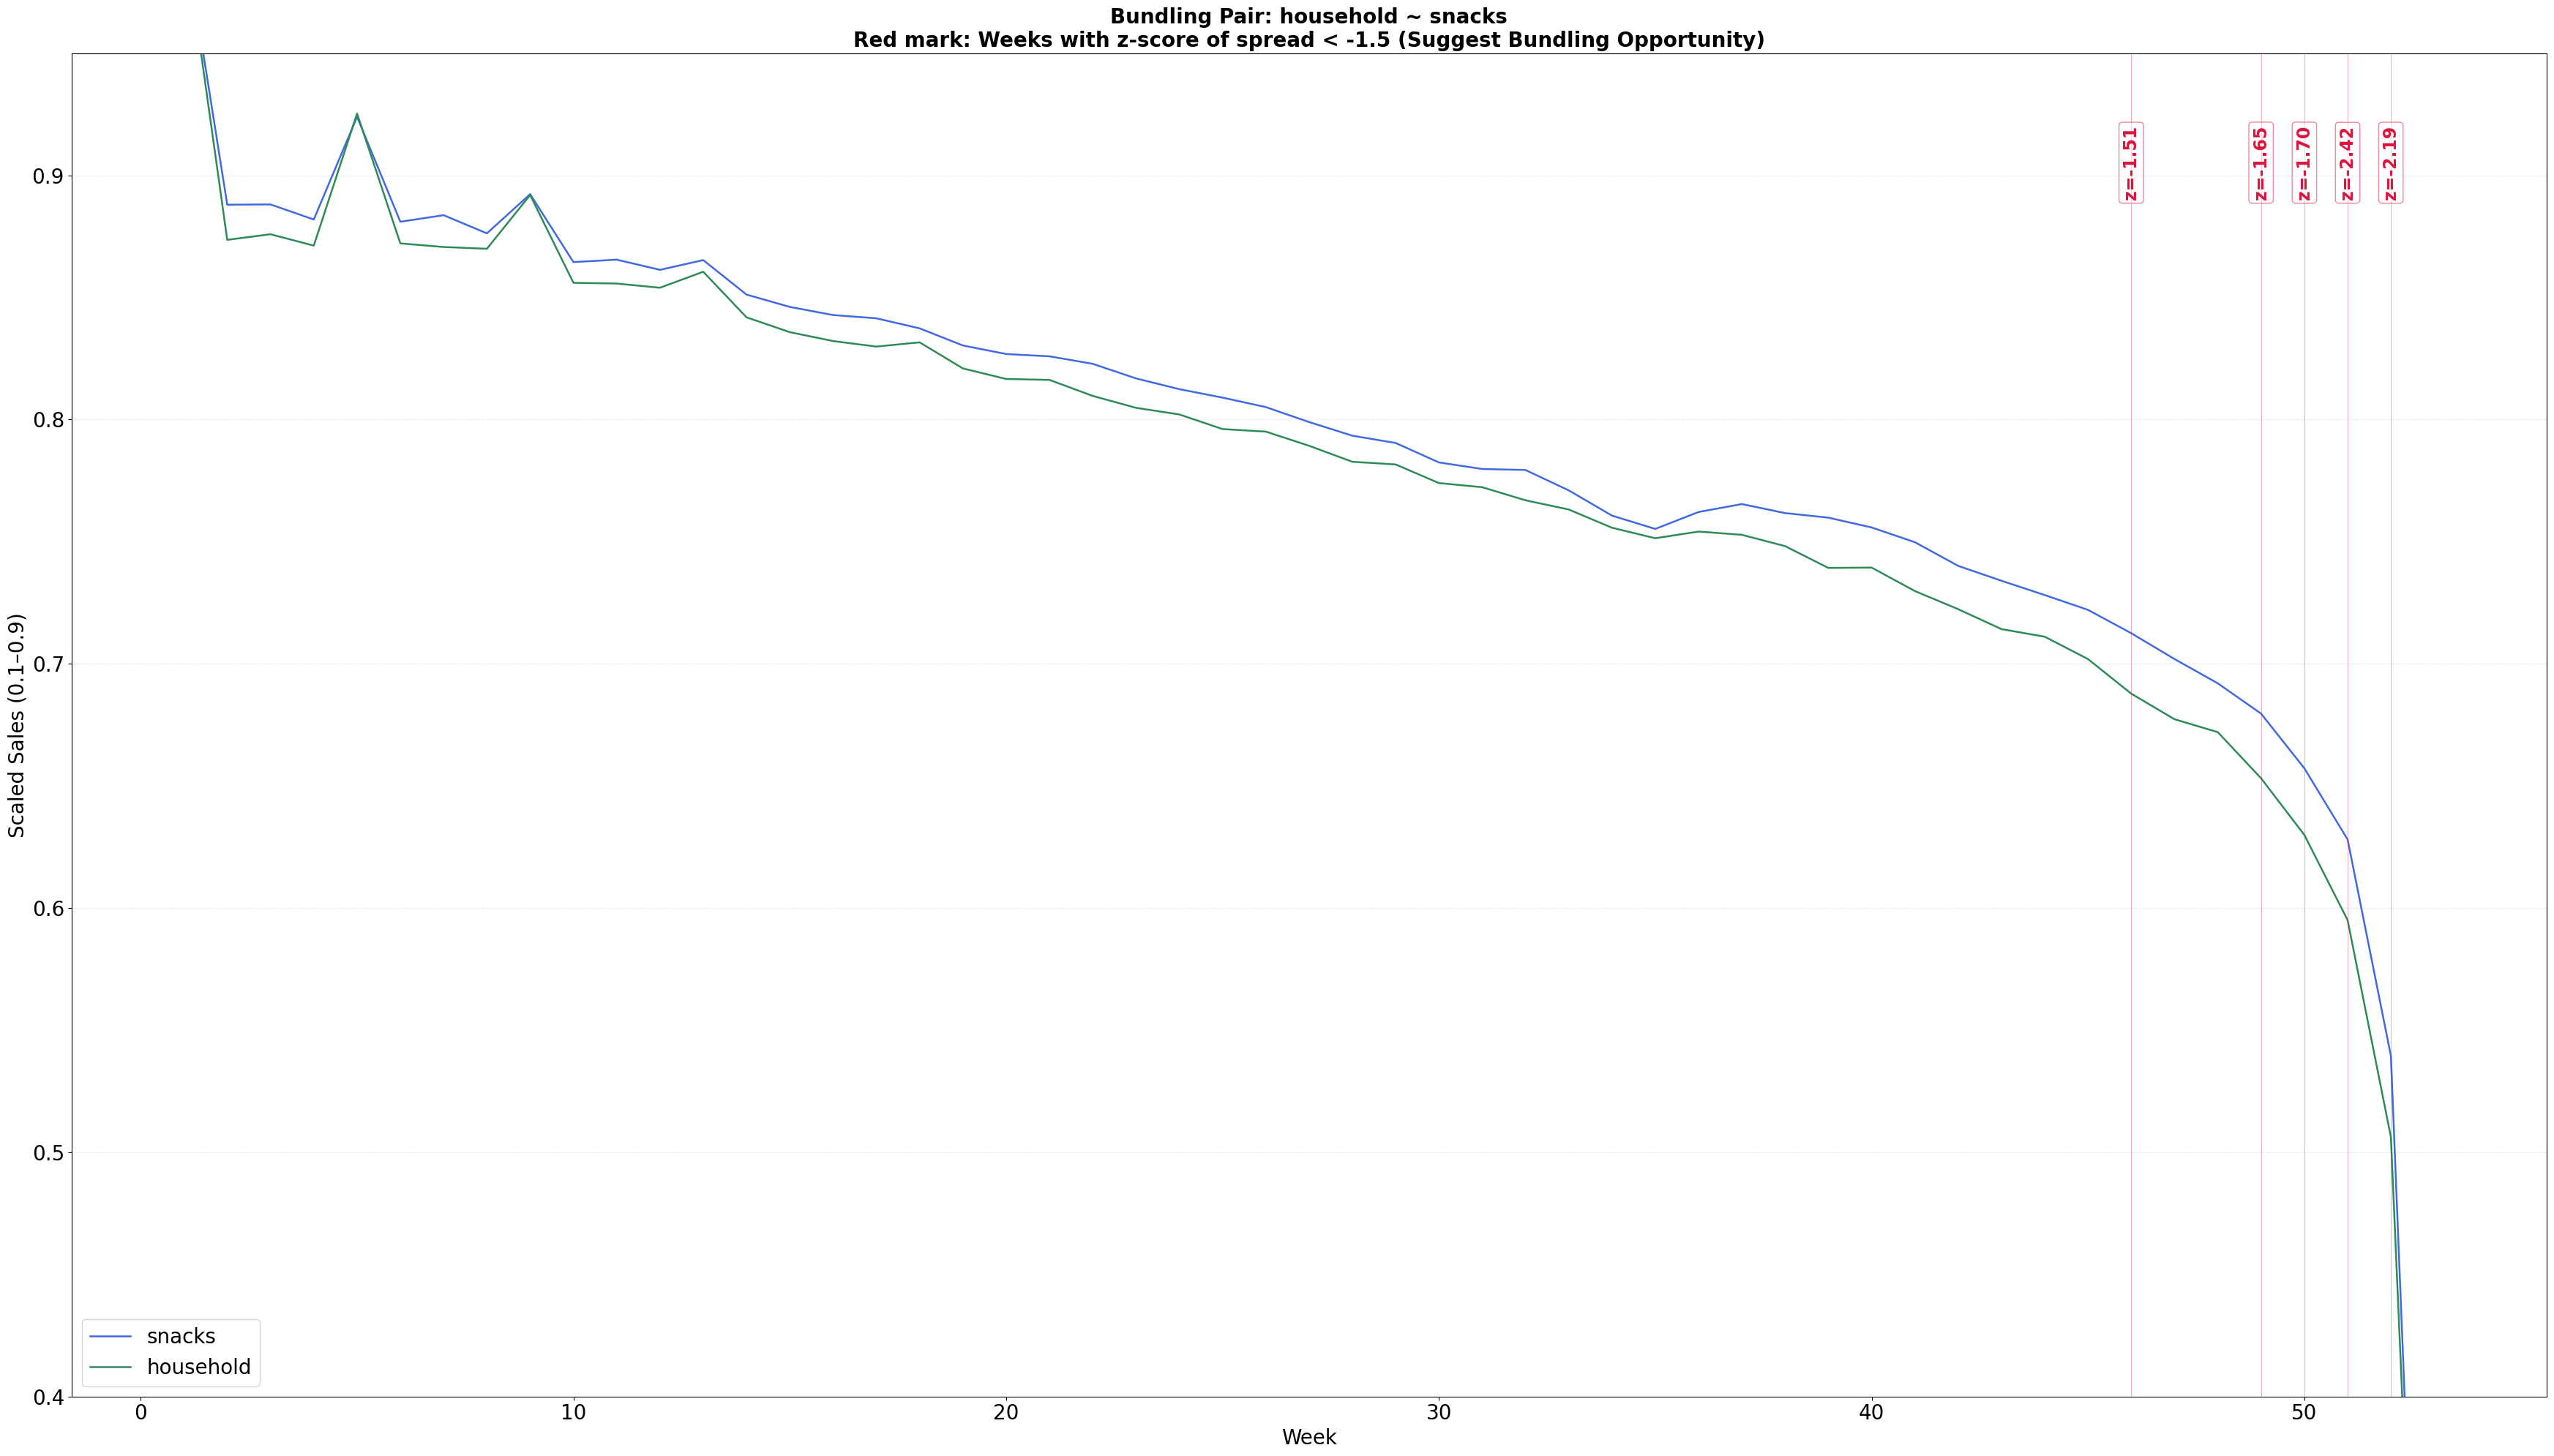

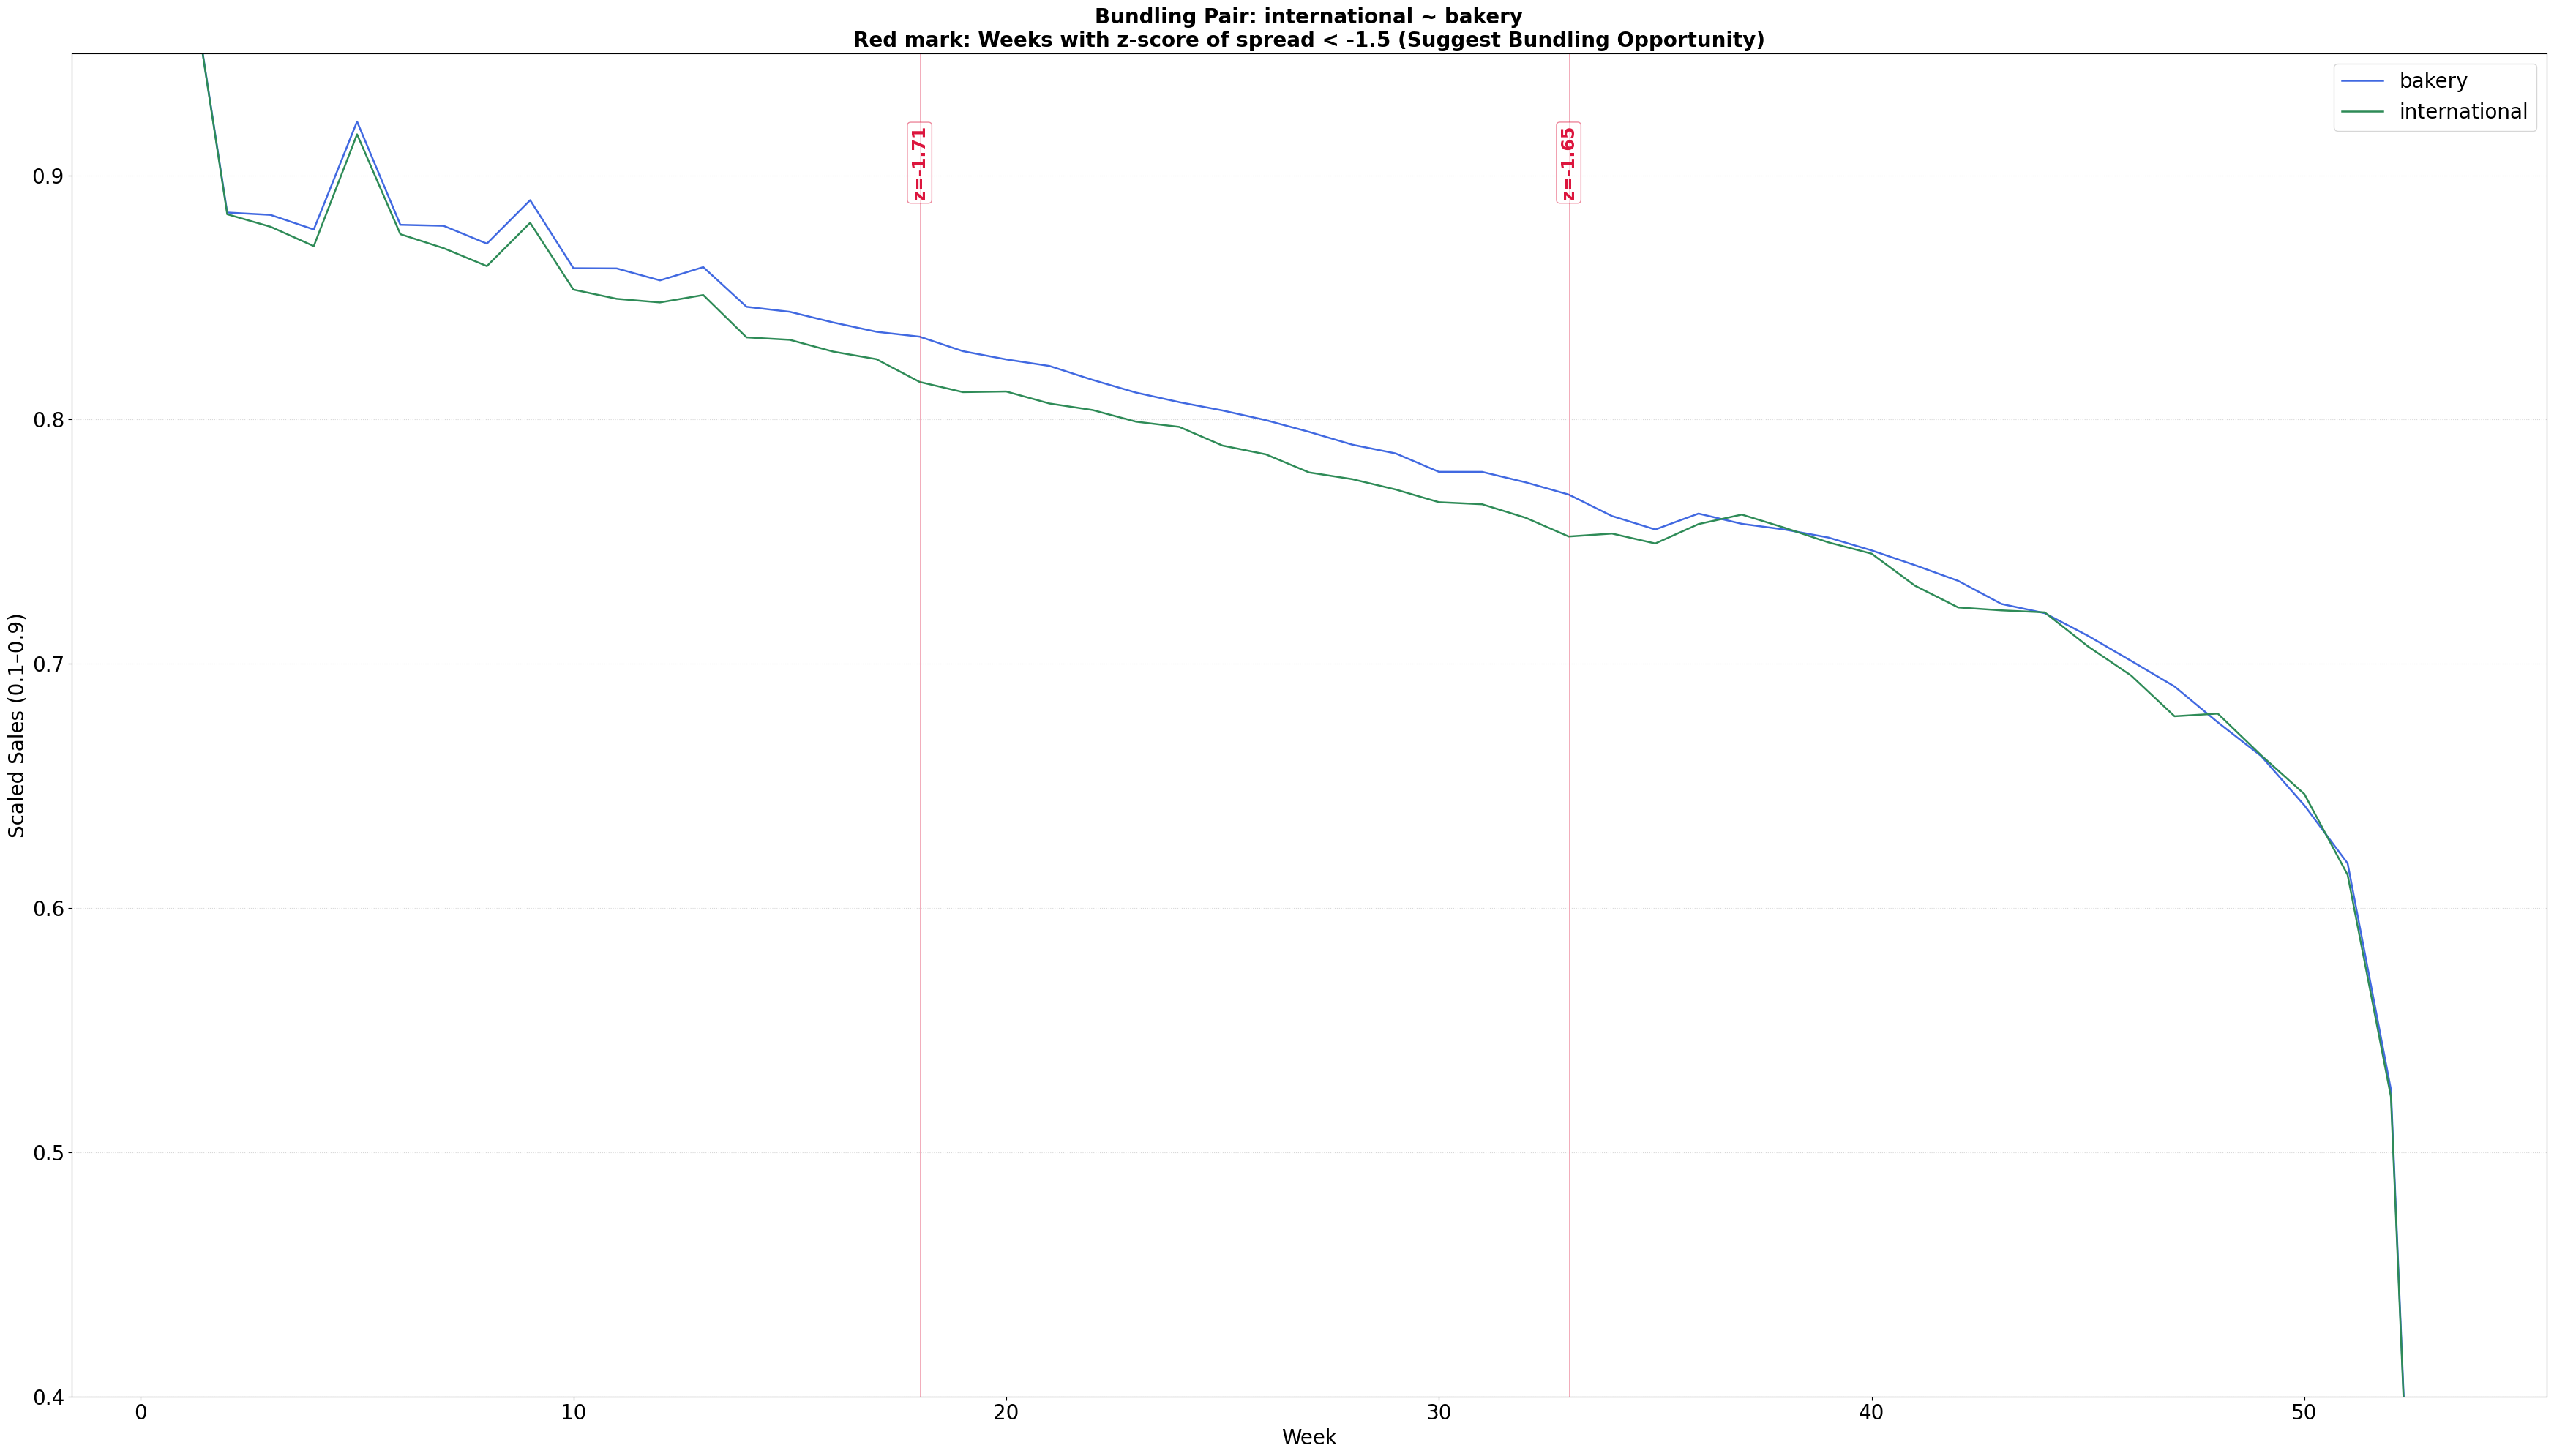

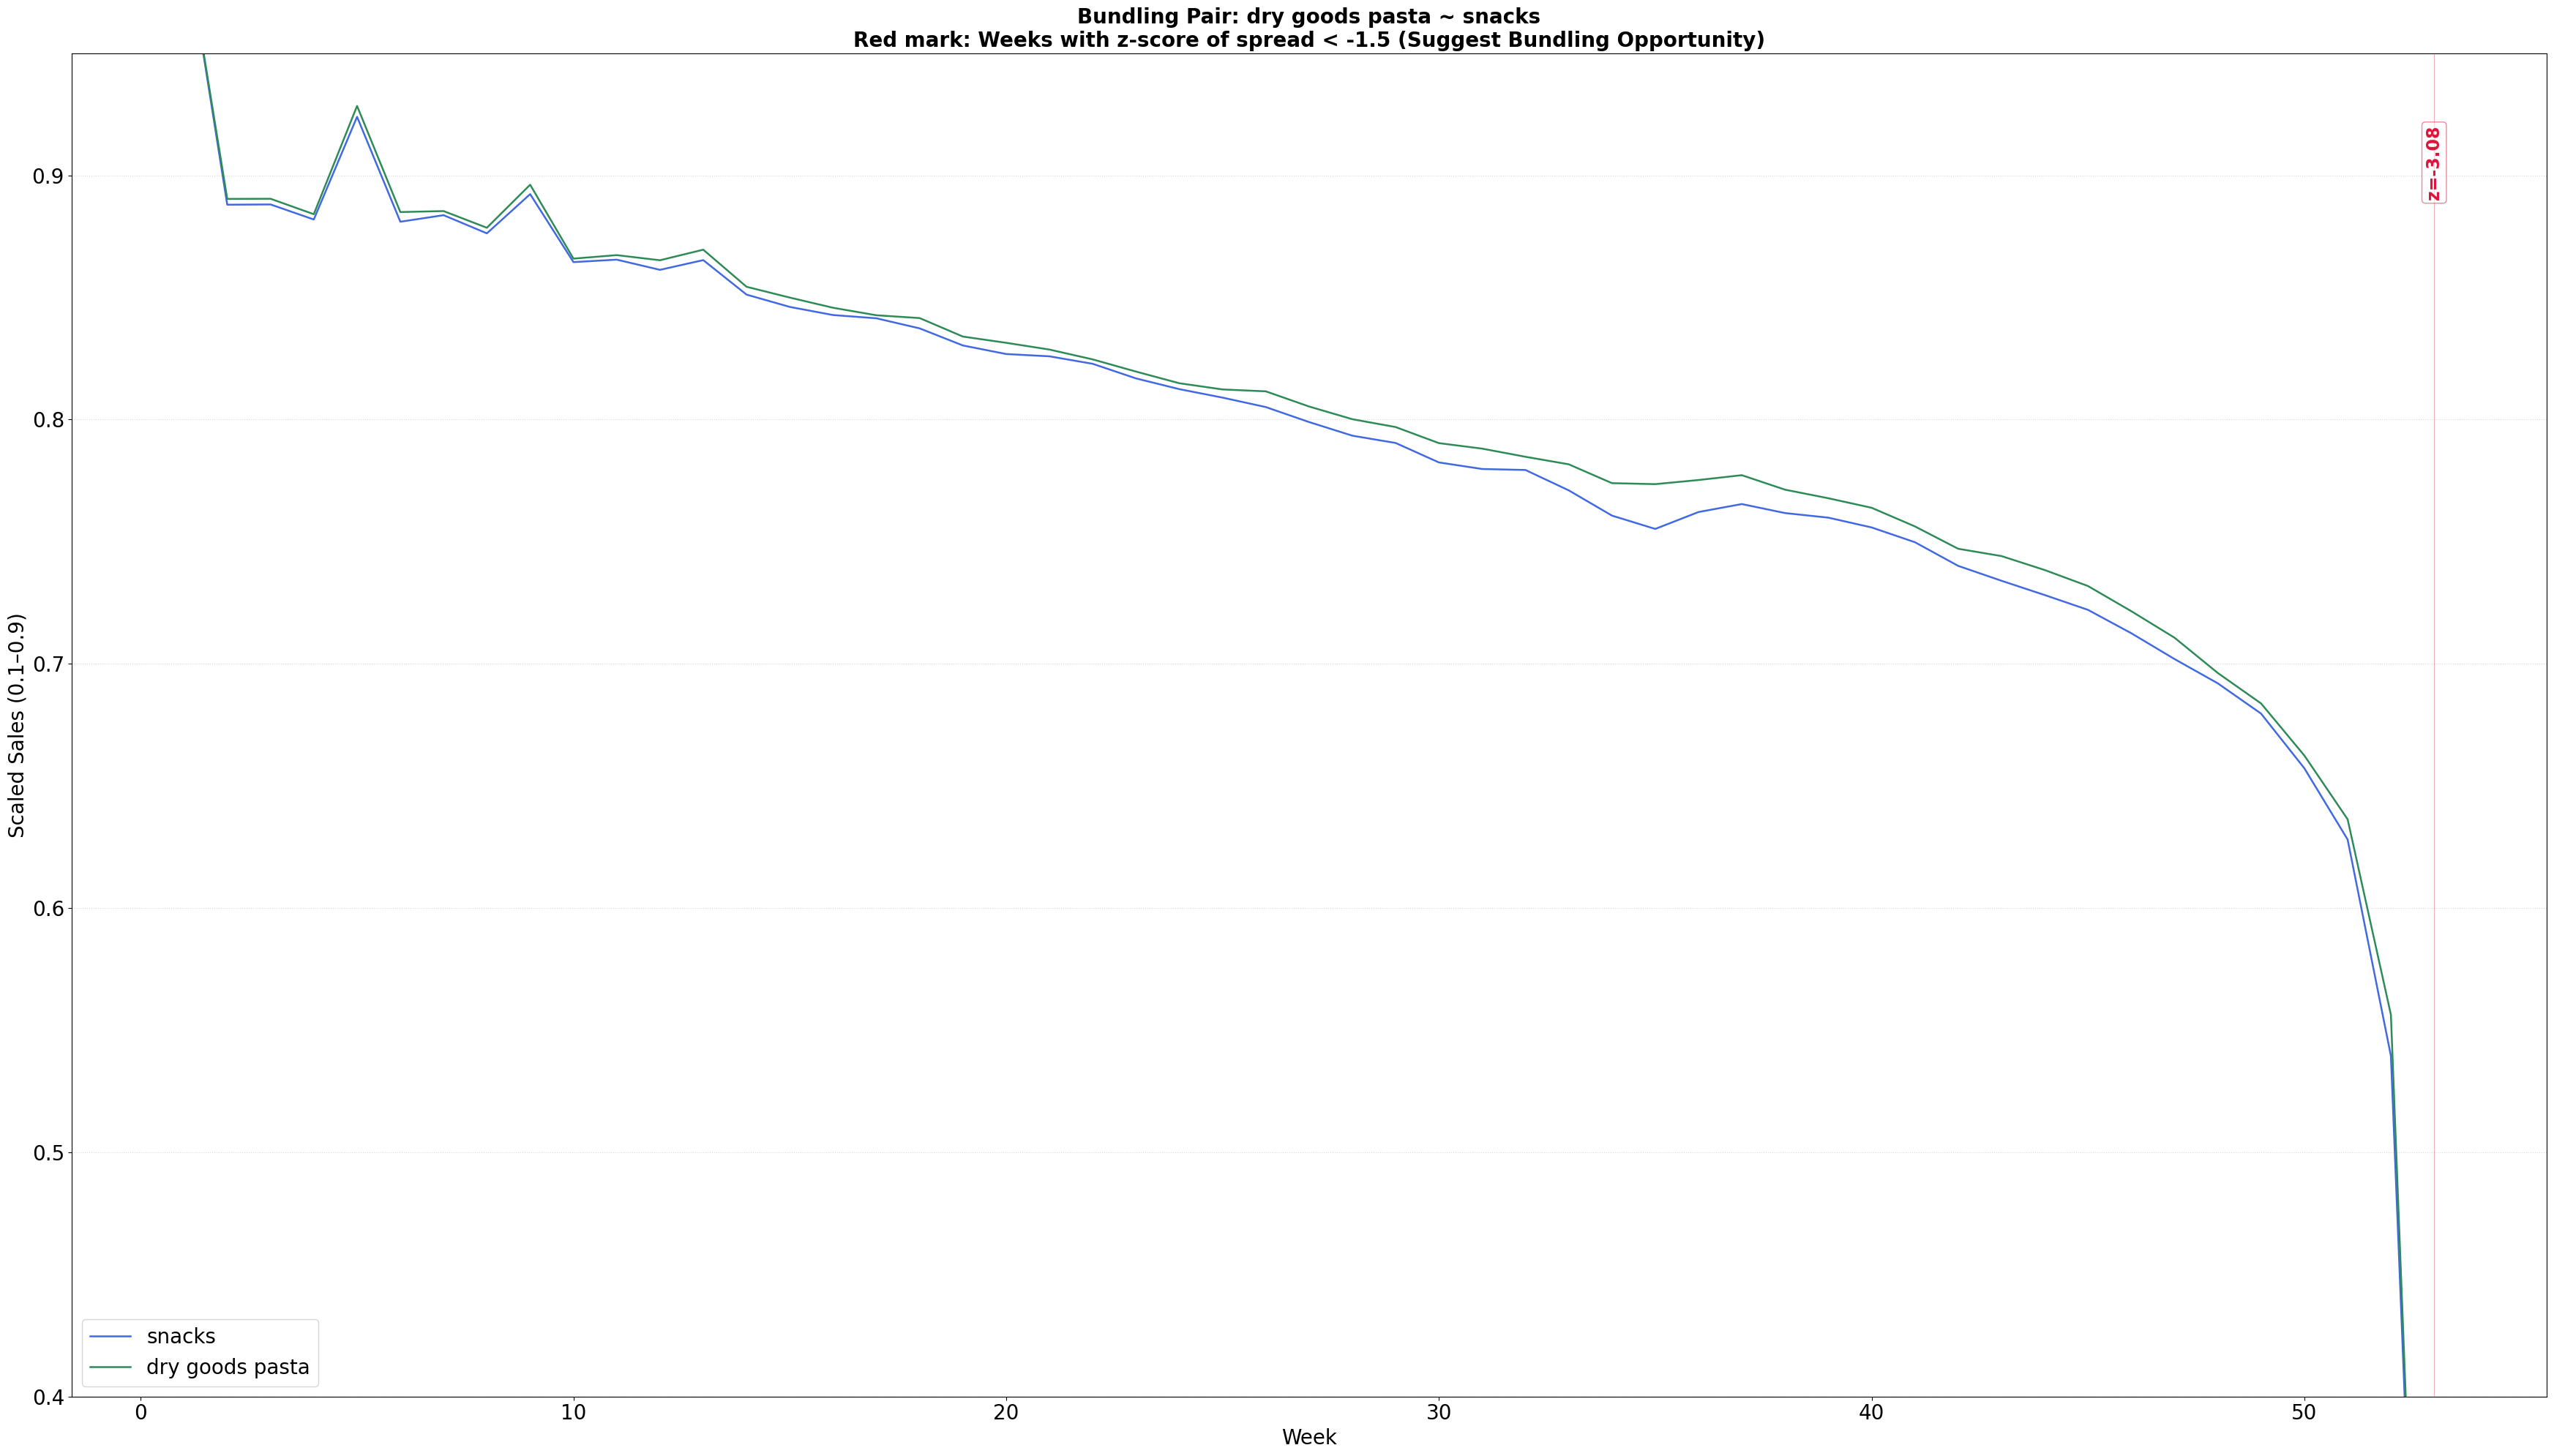

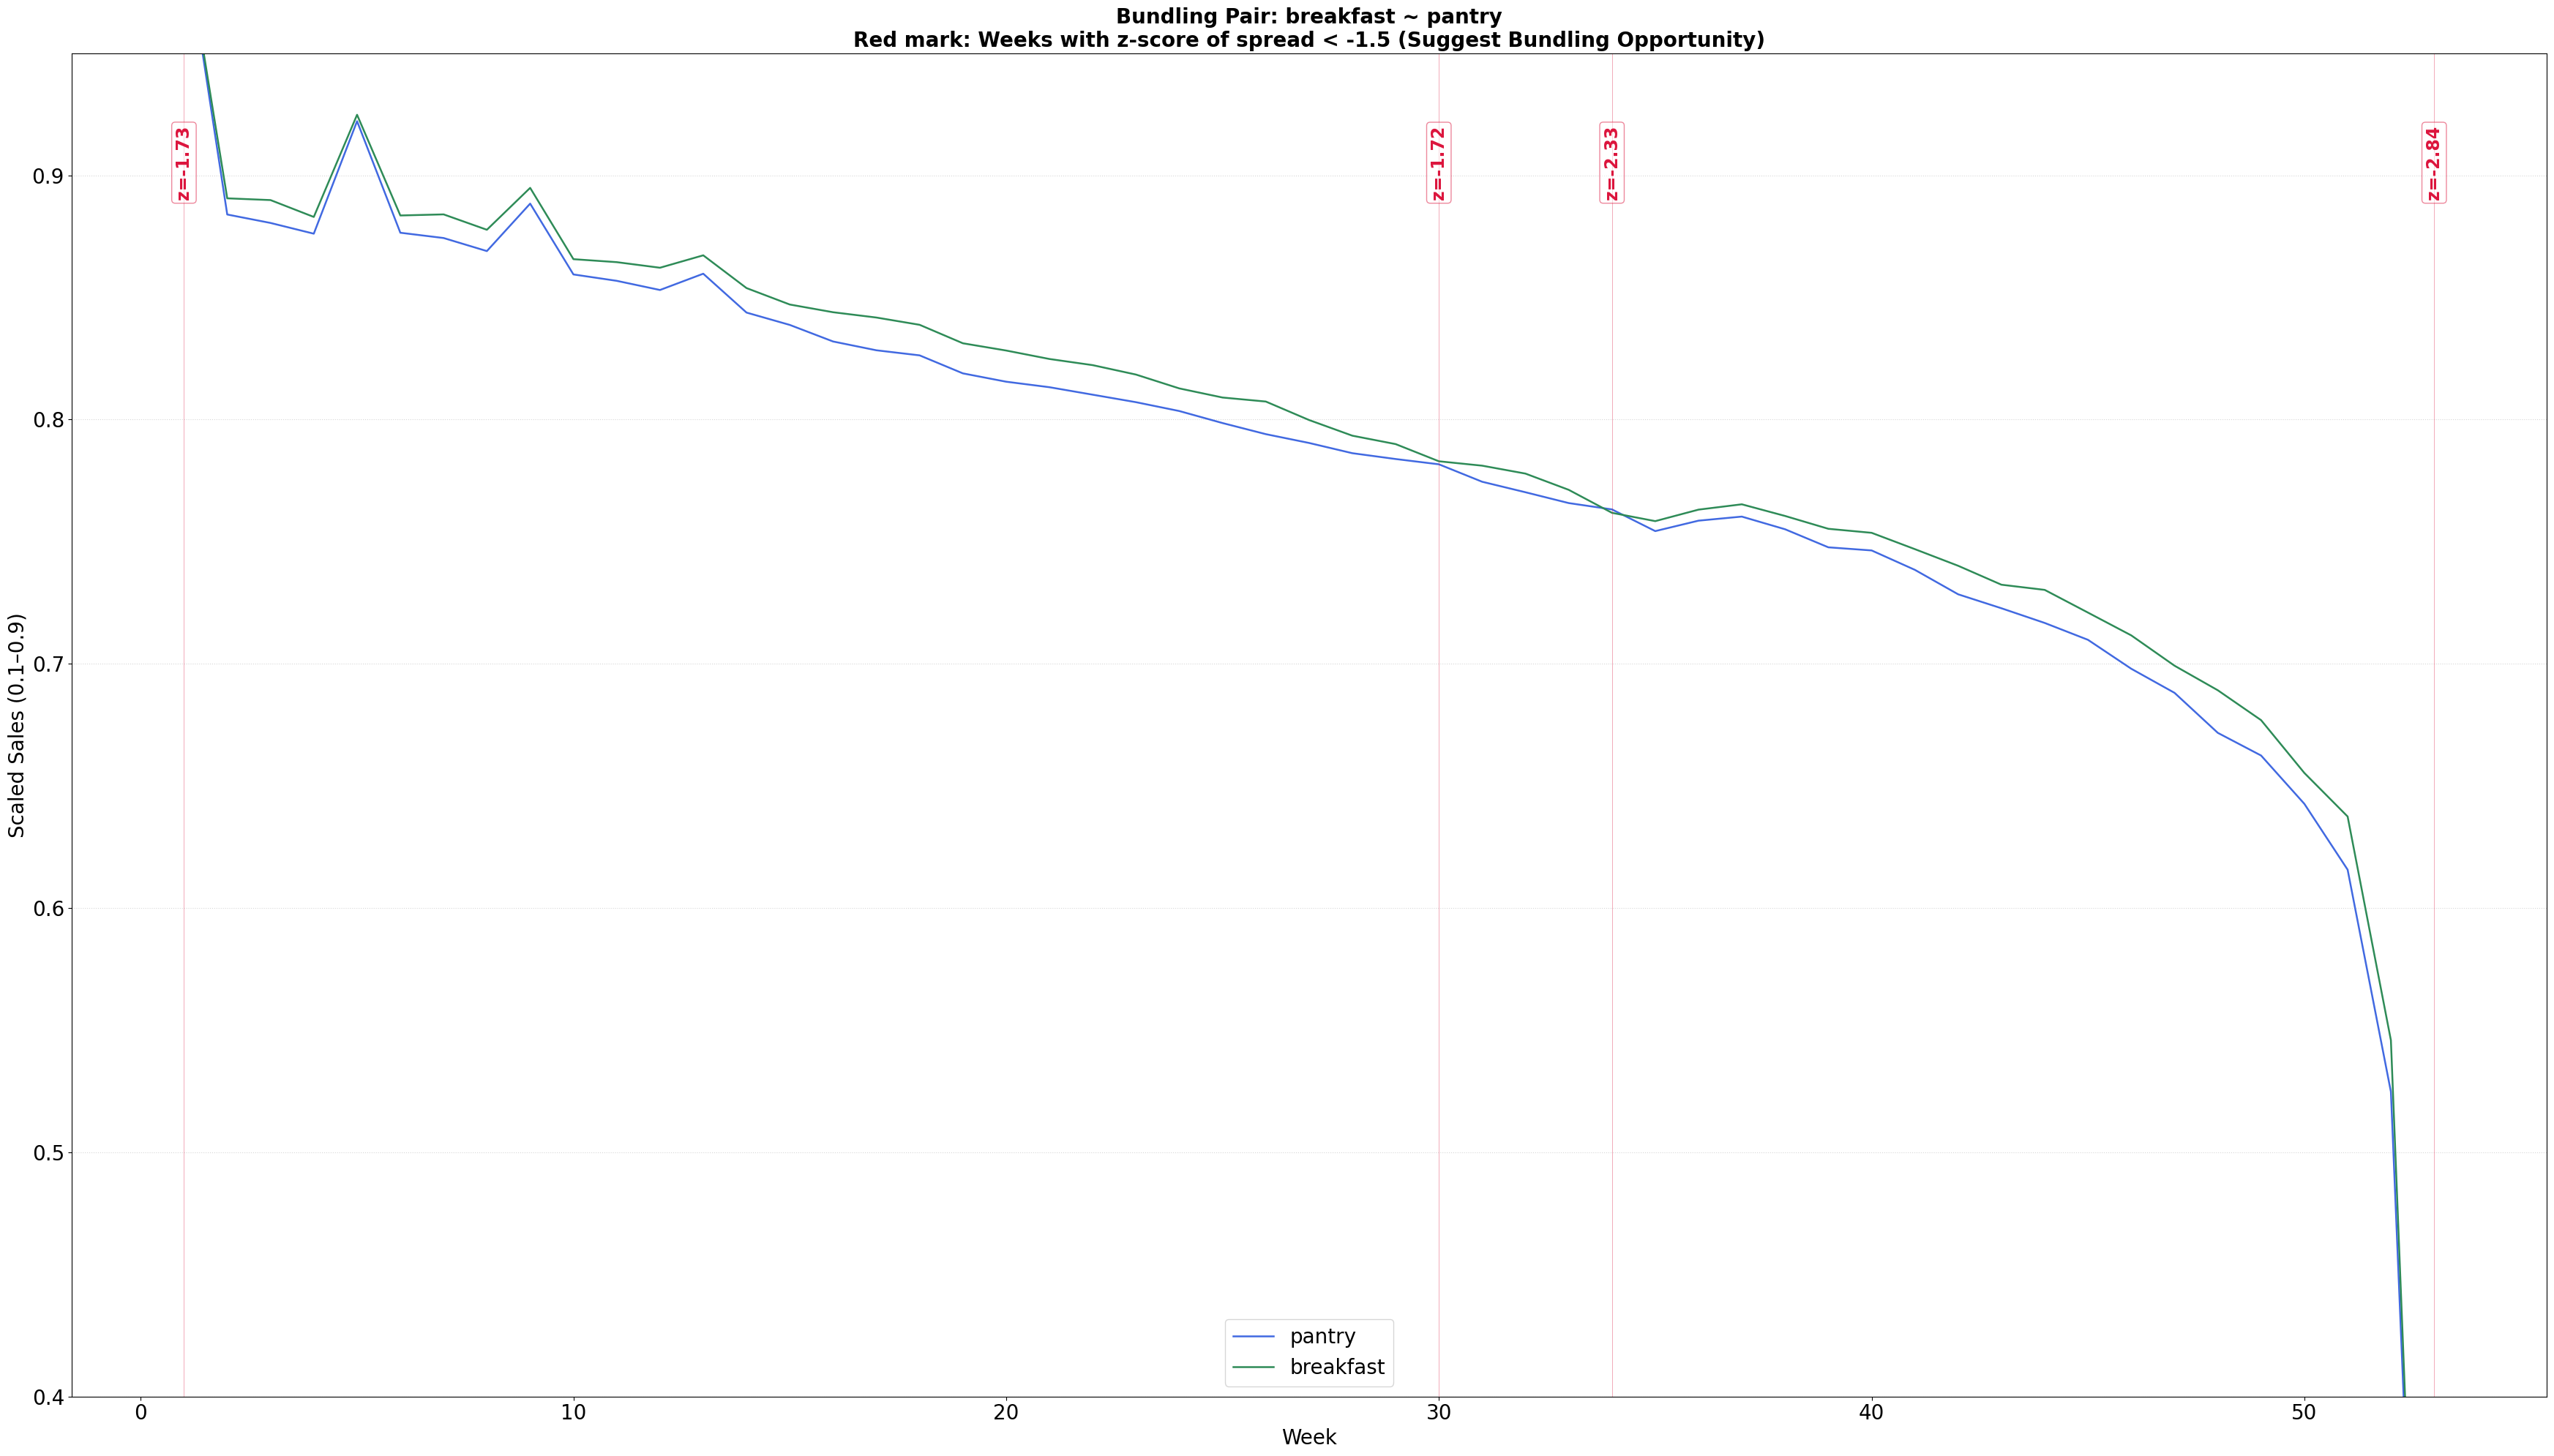

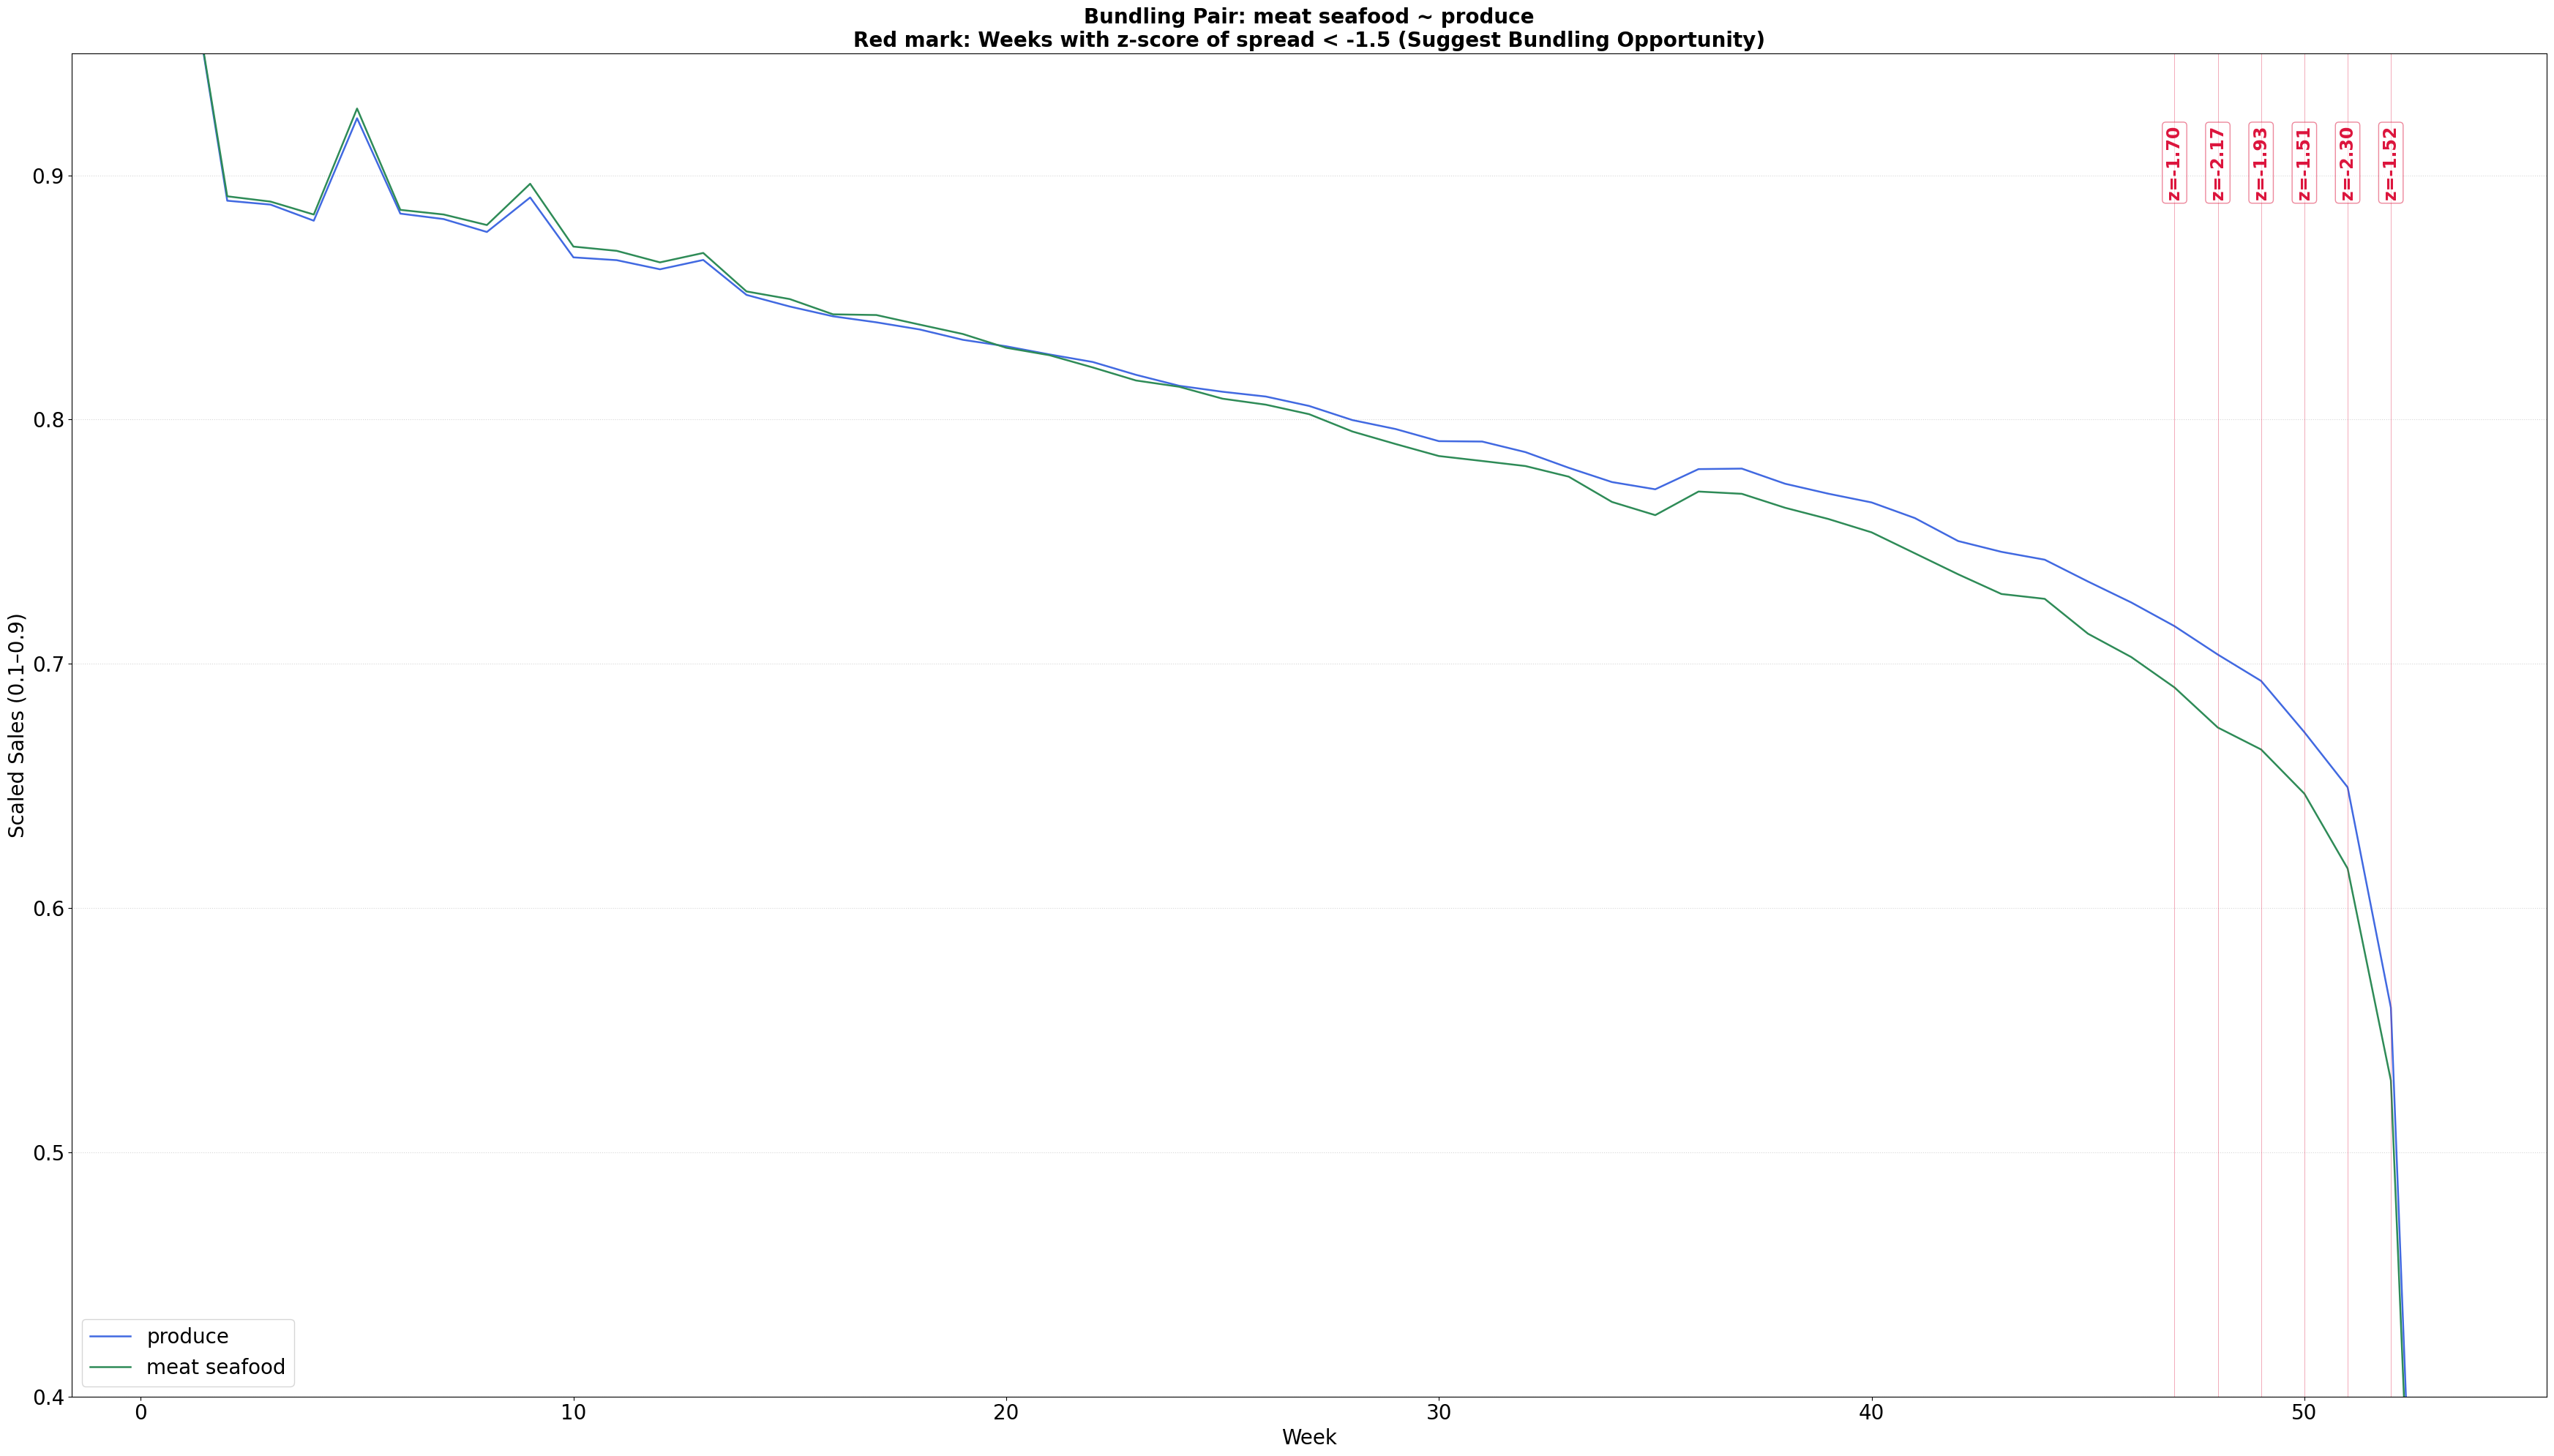

In [29]:
try:
    _ = weekly_sales_log.head()
    _ = sig_pairs.head()
except NameError:
    print("weekly_sales_log or sig_pairs not found. Please ensure the full notebook has been run.")
    print("Creating dummy data for demonstration purposes.")
    # Dummy data for demonstration if weekly_sales_log and sig_pairs are not defined
    np.random.seed(42)
    weeks = pd.RangeIndex(start=0, stop=100, name='Week')
    weekly_sales_log = pd.DataFrame(
        {
            'dept_A': np.log(np.random.rand(100) * 100 + 50 + np.arange(100) * 0.5),
            'dept_B': np.log(np.random.rand(100) * 100 + 60 + np.arange(100) * 0.6),
            'dept_C': np.log(np.random.rand(100) * 100 + 40 + np.arange(100) * 0.4),
            'dept_D': np.log(np.random.rand(100) * 100 + 70 + np.arange(100) * 0.7)
        },
        index=weeks
    )
    sig_pairs = pd.DataFrame({
        'dept_x': ['dept_A'],
        'dept_y': ['dept_B']
    })


for idx, row in sig_pairs.iterrows():
    indep = row['dept_x']
    dep = row['dept_y']

    # Regression and spread (same as your logic)
    X = sm.add_constant(weekly_sales_log[indep])
    y = weekly_sales_log[dep]
    model = sm.OLS(y, X).fit()
    spread = model.resid
    z_scores = zscore(spread)

    flagged_weeks = weekly_sales_log.index[z_scores < -1.5]
    flagged_zs = z_scores[z_scores < -1.5]

    # Improved MinMax scaling for distinct, close lines
    scaler = MinMaxScaler(feature_range=(0.1, 0.9999))
    data_scaled = pd.DataFrame(
        scaler.fit_transform(weekly_sales_log[[indep, dep]]),
        columns=[indep, dep], index=weekly_sales.index
    )

    # Adjusted figsize for a more balanced (taller and slightly less wide) look
    plt.figure(figsize=(35, 20)) # Current size from previous iteration
    plt.plot(data_scaled.index, data_scaled[indep], label=indep, linewidth=1.8, color='royalblue')
    plt.plot(data_scaled.index, data_scaled[dep], label=dep, linewidth=1.8, color='seagreen')

    # Enlarge marker size and visually space annotation
    for i, (week, z) in enumerate(zip(flagged_weeks, flagged_zs)):
        plt.axvline(week, color='crimson', linestyle='-', alpha=0.5, linewidth=0.5)
        # Removed the plt.scatter line to remove the red circular dots
        plt.text(week, 0.89, f'z={z:.2f}', color='crimson', fontsize=17, rotation=90,
                         ha='center', va='bottom', fontweight='bold', bbox=dict(facecolor='white', edgecolor='crimson', boxstyle='round,pad=0.2', alpha=0.5))

    # Expanded Y-axis for breathing room
    plt.ylim(0.4, 0.95)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel("Week", fontsize=20)
    plt.ylabel("Scaled Sales (0.1–0.9)", fontsize=20)
    plt.title(f"Bundling Pair: {dep} ~ {indep}\nRed mark: Weeks with z-score of spread < -1.5 (Suggest Bundling Opportunity)",
              fontsize=20, fontweight='semibold')
    plt.legend(fontsize=20)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

Objective 4: Simulate Revenue Uplift from Bundling Strategy
--
Simulate a 5% uplift in total basket value during recommended weeks.

Null Hypothesis (H₀):\
There is no significant difference in average weekly sales before and after applying the bundling strategy.

Alternative Hypothesis (H₁):\
The average weekly sales after bundling is significantly higher than before bundling.


For each significant pair:\
Estimate OLS\
Simulate bundling using analyze_bundling_impact 

Print:\
Which weeks bundling is recommended\
Whether simulated uplift is statistically significant

Interpretation Notes:\
Bundling signals are based on price-volume dynamics (via cointegration and z-score spread).\
Simulated 5% uplift checks if bundling leads to meaningful gain.\
Statistical tests (t-test) ensure any uplift isn’t by chance.



In [30]:
# Ensure datetime index
if not isinstance(weekly_sales_log.index, pd.DatetimeIndex):
    weekly_sales_log.index = pd.to_datetime(weekly_sales_log.index)
    print("Converted ts_df index to DatetimeIndex.")

ts_df = weekly_sales_log.copy()

def estimate_ols(ts, x_col, y_col):
    X = sm.add_constant(ts[[x_col]])
    y = ts[y_col]
    return sm.OLS(y, X).fit()

def analyze_bundling_impact(ts, independent_var, dependent_var, ols_results,
                            lookback_window=30, z_score_threshold=-1, assumed_uplift_pct=0.05):

    df = ts[[independent_var, dependent_var]].copy()
    df = df[(df[independent_var] > 0) & (df[dependent_var] > 0)].dropna()

    alpha = ols_results.params['const']
    beta = ols_results.params[independent_var]

    df['spread'] = df[dependent_var] - (alpha + beta * df[independent_var])
    df['spread_mean'] = df['spread'].rolling(window=lookback_window, min_periods=lookback_window).mean()
    df['spread_std'] = df['spread'].rolling(window=lookback_window, min_periods=lookback_window).std()
    df['z_score'] = (df['spread'] - df['spread_mean']) / df['spread_std']
    df['recommend_bundle'] = (df['z_score'] < z_score_threshold).fillna(False)

    alert_timestamps = df[df['recommend_bundle']].index
    timestamp_to_position = {ts_val: i for i, ts_val in enumerate(ts.index)}
    bundle_weeks = [timestamp_to_position[ts_val] for ts_val in alert_timestamps if ts_val in timestamp_to_position]

    original_sales_independent = np.expm1(df[independent_var])
    original_sales_dependent = np.expm1(df[dependent_var])

    df['base_basket_original_units'] = original_sales_independent + original_sales_dependent
    df['bundle_basket_original_simulated_units'] = df['base_basket_original_units'].copy()
    df.loc[df['recommend_bundle'], 'bundle_basket_original_simulated_units'] *= (1 + assumed_uplift_pct)

    df['base_basket'] = np.log1p(df['base_basket_original_units'])
    df['bundle_basket'] = np.log1p(df['bundle_basket_original_simulated_units'])

    base = df['base_basket'].dropna()
    bundle = df['bundle_basket'].dropna()
    common_index = base.index.intersection(bundle.index)
    base_aligned = base.loc[common_index]
    bundle_aligned = bundle.loc[common_index]

    t_stat, p_value = np.nan, np.nan
    if len(base_aligned) > 1:
        t_stat, p_value = ttest_rel(bundle_aligned, base_aligned)

    return {
        'pair': f"{independent_var} ~ {dependent_var}",
        'bundle_weeks': bundle_weeks,
        'simulated_t_stat': t_stat,
        'simulated_p_value': p_value,
        'analysis_df': df
    }

print("--- Analyzing Bundling Opportunities and Simulated Impact for Cointegrated Pairs ---")
print("-" * 70)

all_impact_results = []
lookback_window_for_analysis = 30
z_score_threshold_for_analysis = -1.5
assumed_uplift_percentage = 0.05

for index, row in sig_pairs.iterrows():
    dept_x = row['dept_x']
    dept_y = row['dept_y']
    independent_var = dept_x
    dependent_var = dept_y

    print(f"\n===== Analyzing Pair: Independent='{independent_var}' vs. Dependent='{dependent_var}' =====")
    print("-" * 58)

    if independent_var not in ts_df.columns or dependent_var not in ts_df.columns:
        print(f"  Warning: Missing columns ('{independent_var}', '{dependent_var}'). Skipping.")
        continue

    pair_data = ts_df[[independent_var, dependent_var]].dropna()
    if pair_data.empty:
        print(f"  Warning: No valid data for pair ('{independent_var}', '{dependent_var}'). Skipping.")
        continue

    ols_results = estimate_ols(pair_data, independent_var, dependent_var)
    impact = analyze_bundling_impact(pair_data, independent_var, dependent_var, ols_results,
                                     lookback_window=lookback_window_for_analysis,
                                     z_score_threshold=z_score_threshold_for_analysis,
                                     assumed_uplift_pct=assumed_uplift_percentage)

    if impact['bundle_weeks']:
        print(f"  Bundling opportunities (indices): {impact['bundle_weeks']}")
    else:
        print(f"  No significant bundling opportunities (z-score < {abs(z_score_threshold_for_analysis)}) found.")

    if not np.isnan(impact['simulated_t_stat']):
        print(f"  Simulated t-test: t = {impact['simulated_t_stat']:.3f}, p = {impact['simulated_p_value']:.4f}")
        if impact['simulated_p_value'] < 0.05:
            print("  Conclusion: Simulated uplift is statistically significant.")
        else:
            print("  Conclusion: Simulated uplift is not statistically significant.")
    else:
        print("  Simulated Paired t-test could not be performed or returned NaN.")

    all_impact_results.append(impact)
    print("=" * 70)

print("\n--- Summary of Simulated Bundling Impact Across All Significant Pairs ---")
print("-" * 70)

summary_data = []
for result in all_impact_results:
    summary_data.append({
        'Pair': result['pair'],
        'Bundle_Alert_Weeks_Count': len(result['bundle_weeks']),
        'Simulated_T_Stat': f"{result['simulated_t_stat']:.3f}" if not np.isnan(result['simulated_t_stat']) else "N/A",
        'Simulated_P_Value': f"{result['simulated_p_value']:.4f}" if not np.isnan(result['simulated_p_value']) else "N/A",
        'Is_Sim_Significant': "Yes" if (not np.isnan(result['simulated_p_value']) and result['simulated_p_value'] < 0.05) else "No/N/A"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df)

print(f"\n**Note:** The simulated results assume a {int(assumed_uplift_percentage*100)}% uplift. Real-world validation (A/B test) is essential.")


Converted ts_df index to DatetimeIndex.
--- Analyzing Bundling Opportunities and Simulated Impact for Cointegrated Pairs ---
----------------------------------------------------------------------

===== Analyzing Pair: Independent='dry goods pasta' vs. Dependent='personal care' =====
----------------------------------------------------------
  Bundling opportunities (indices): [30, 34, 38, 43, 50, 51]
  Simulated t-test: t = 2.576, p = 0.0129
  Conclusion: Simulated uplift is statistically significant.

===== Analyzing Pair: Independent='frozen' vs. Dependent='deli' =====
----------------------------------------------------------
  Bundling opportunities (indices): [41, 43, 45, 52]
  Simulated t-test: t = 2.060, p = 0.0444
  Conclusion: Simulated uplift is statistically significant.

===== Analyzing Pair: Independent='bakery' vs. Dependent='meat seafood' =====
----------------------------------------------------------
  Bundling opportunities (indices): [44, 45, 46, 47, 50]
  Simulated